# K_01 – Räumliche Analyse

**Grid-Arbitrage** · Batteriespeicher-Arbitrage im Schweizer Strommarkt (Kür)

**Gruppe:** SC26_Gruppe_2 | **Verantwortlich:** Patrik Neunteufel | **Datum:** März 2026

---

*Batteriestandort-Optimierung via Battery Value Index (BVI) und Netzentlastungspotenzial.*


| [← K_00 – Business Strategy](K_00_Business_Strategy.ipynb) | [↑ Übersicht ↑](../organisation/O_01_Project_Overview.ipynb) | [K_02 – Cross-Border-Analyse →](K_02_Cross_Border.ipynb) |
|:---|:---:|---:|

## Inhaltsverzeichnis<a id='toc_K_01'></a>

[Einleitung](#einleitung_K_01)  
[Initialisierung](#initialisierung_K_01)  
1 [Daten laden](#daten-laden_K_01)  
2 [Netz-Zonen definieren](#netz-zonen-definieren_K_01)  
3 [Produktions-Verbrauchs-Bilanz pro Zone (Imbalance Score)](#produktions-verbrauchs-bilanz-pro-zone-imbalance-score_K_01)  
4 [Räumliche Rollout-Szenarien & BVI](#raeumliche-rollout-szenarien_K_01)  
5 [Räumliche Karten](#visualisierungen-raeumliche-analyse_K_01)  
6 [Tages- und Lastprofile](#tages-und-lastprofile_K_01)  
7 [Saisonale Zonenimbalance: Wann und wo lohnen sich Batterien?](#saisonale-zonenimbalance-wann-und-wo-lohnen-sich-batterien_K_01)  
[Fazit: Was die räumliche Analyse zeigt](#fazit-was-die-raeumliche-analyse-zeigt_K_01)  
[Abschluss](#abschluss_K_01)  


---
## Einleitung <a id='einleitung_K_01'></a>

[↑ Inhaltsverzeichnis](#toc_K_01)

Räumliche Analyse der Schweizer Erzeugungs- und Verbrauchslandschaft:
Wo sind Engpässe, wo hohe Zonenimbalance, wo lohnen sich Batterien am ehesten?

- **Battery Value Index (BVI)** pro Netz-Zone aus Produktions-/Verbrauchsbilanz
- Saisonale Verschiebung der Imbalance (Winter vs. Sommer)
- Räumliche Rollout-Szenarien (gleichmässig vs. BVI-gewichtet)
- Heatmaps Tages-/Saisonprofil pro Zone, Generator-Mix

Daten: BFE Elektrizitätsproduktionsanlagen (GeoPackage), BFS STATPOP
(kantonale Bevölkerung), swissBOUNDARIES3D (Kantonsgrenzen). Diese Datensätze
werden **in diesem Notebook zum ersten Mal geladen** — Download erfolgt in §1.


## Initialisierung<a id='initialisierung_K_01'></a>

[↑ Inhaltsverzeichnis](#toc_K_01)

Bibliotheken laden, `../sync/config.json` lesen, Verzeichnispfade setzen.

**Imports und Versionen:**

In [1]:
# ── lib/ aus Projekt-Root erreichbar machen + lib-Imports ───────────────────
import sys, os
_PROJECT_ROOT = os.path.abspath('..')
if _PROJECT_ROOT not in sys.path:
    sys.path.insert(0, _PROJECT_ROOT)
try:
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
except Exception:
    pass

from lib.plotting   import show_source, make_gif_chart, make_spline_h24
from lib.widgets    import show_animation
from lib.io_ops     import load_transfer, log_dataindex, needs_download, final_check
from lib.columns    import find_col
from lib.grid_topo  import load_kantone

print(f'lib-Pfad aktiv: {_PROJECT_ROOT}/lib')


lib-Pfad aktiv: C:\Users\patri\Documents\docker\python\OWN\Grid-Arbitrage/lib


In [2]:
# ── Bibliotheken ─────────────────────────────────────────────────────────────
import subprocess, sys
from datetime import datetime
for imp, pkg in [('geopandas','geopandas'),('pandas','pandas'),
                 ('numpy','numpy'),('matplotlib','matplotlib'),
                 ('requests','requests'),('scipy','scipy')]:
    try: __import__(imp)
    except ImportError:
        subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])

import os, warnings, io, zipfile, json
import requests, numpy as np, pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib import cm
from shapely.geometry import Point, Polygon
import scipy
from scipy.spatial import cKDTree
warnings.filterwarnings('ignore')
# asyncio slow-callback-Warnung unterdrücken (Jupyter/Windows + GeoPandas 322k Anlagen)
import asyncio as _asyncio
try:
    _asyncio.get_event_loop().slow_callback_duration = 5.0  # Schwellenwert: 5s statt 0.1s
except RuntimeError:
    pass  # kein Event-Loop aktiv (z.B. beim Run-All)

# Versionen anzeigen für Reproduzierbarkeit
print(f"📅 Zuletzt ausgeführt am: {datetime.now().strftime('%d.%m.%Y um %H:%M:%S')}")


📅 Zuletzt ausgeführt am: 26.04.2026 um 12:52:15


**Setup – Konfiguration & Verzeichnisstruktur:** Lädt `../sync/config.json` (SSOT), setzt Pfade.

In [3]:
# ── ../sync/config.json laden ───────────────────────────────────────────────────────
# Schalter NIE direkt hier setzen — immer in ../sync/config.json anpassen.
with open('../sync/config.json') as _cfg_f: CFG = json.load(_cfg_f)

# Aliases (nur lesend)
MODE         = CFG['mode']
FORCE_RELOAD = CFG['force_reload']
BASE_PEAK_GW = CFG['szenarien']['ch_spitzenlast_gw']
GZ_MODE      = CFG['szenarien']['gleichzeitigkeit_aktiv']
GZ_RATE      = CFG['szenarien']['optionen'][GZ_MODE]['rate']

DATA_DIR   = os.path.join('../data', 'raw')
INTER_DIR  = os.path.join('../data', 'intermediate')
SZ_AKTIV   = GZ_MODE
CHARTS_DIR = os.path.join('../output', 'charts', SZ_AKTIV)
os.makedirs(DATA_DIR,   exist_ok=True)
os.makedirs(CHARTS_DIR, exist_ok=True)
DPI = CFG['visualisierung']['output_dpi']  # SSOT: ../sync/config.json
# ── Farben & Stil aus ../sync/config.json (SSOT) ─────────────────────────────────────
# Bestehende Variablen (Rückwärtskompatibilität)
_viz        = CFG.get('visualisierung', {}).get('farben', {})
BG_DARK     = _viz.get('bg_dark',    '#0d1117')
BG_PANEL    = _viz.get('bg_panel',   '#141414')
C_PRICE     = _viz.get('c_price',    '#FFA726')
C_LOAD      = _viz.get('c_load',     '#66BB6A')
C_CHARGE    = _viz.get('c_charge',   '#1565C0')
C_FEED      = _viz.get('c_feed',     '#B71C1C')
SEG_COLORS  = _viz.get('seg_colors', ['#42A5F5', '#66BB6A', '#FFA726', '#EF5350'])
C_PRIV, C_GEW, C_IND, C_UTIL = SEG_COLORS

# UI-Strukturfarben
C_ACHSE      = _viz.get('c_achse',      '#aaaaaa')  # Achsenbeschriftungen
C_TICK       = _viz.get('c_tick',       '#bbbbbb')  # Tick-Labels
C_SPINE      = _viz.get('c_spine',      '#333333')  # Achsenrahmen
C_LEGENDE_BG = _viz.get('c_legende_bg', '#111111')  # Legenden-Hintergrund
C_GITTER     = _viz.get('c_gitter',     '#cccccc')  # Gitterlinien

# Funktionale Extrafarben (nur laden was das NB braucht)
C_DISPATCH   = _viz.get('c_dispatch',   '#AB47BC')  # Dispatch-optimal
C_STACKING   = _viz.get('c_stacking',   '#5DCAA5')  # Revenue Stacking
C_SOLAR      = _viz.get('c_solar',      '#FDD835')  # Solar-Ertrag
C_GRENZWERT  = _viz.get('c_amber_dark', '#FF6F00')  # Grenzwert / Warnung
C_CYAN       = _viz.get('c_cyan',       '#26C6DA')  # Flusswasser / Alt. Speicher
C_GRUEN_DARK = _viz.get('c_gruen_dark', '#388E3C')  # Erneuerbare

# ET_COLORS: config-Werte überschreiben Defaults — funktioniert auch ohne et_colors in config
_et_def = {
    'Solar':      C_SOLAR,     'Wasserkraft': C_CHARGE,   'Kernkraft': '#7B1FA2',
    'Wind':       '#80DEEA',   'Biomasse':    C_GRUEN_DARK,'Erdgas':   C_GRENZWERT,
    'Erdoel':     '#546E7A',   'Abfall':      '#795548',   'Andere':   '#9E9E9E',
}
ET_COLORS = {**_et_def, **_viz.get('et_colors', {})}  # SSOT: config.json → visualisierung.farben.et_colors
_sc_def2 = {'Winter': C_PRIV, 'Frühling': C_GEW, 'Sommer': C_SOLAR, 'Herbst': C_GRENZWERT}
SAISON_COLORS = {**_sc_def2, **_viz.get('saison_colors', {})}  # SSOT: config.json → visualisierung.farben.saison_colors

# Stilkonstanten
_stil               = CFG.get('visualisierung', {}).get('stil', {})
LW                  = _stil.get('linienbreite_standard', 1.5)   # Standard-Linienbreite
LW_DUENN            = _stil.get('linienbreite_duenn',    0.8)   # dünne Linien
LW_DICK             = _stil.get('linienbreite_dick',     2.5)   # dicke Linien
ALPHA_FLAECHE       = _stil.get('alpha_flaeche',         0.12)  # dezente Füllung
ALPHA_FLAECHE_STARK = _stil.get('alpha_flaeche_stark',   0.35)  # Balken / Füllung
ALPHA_LEGENDE       = _stil.get('alpha_legende',         0.30)  # Legenden-BG
ALPHA_GEDAEMPFT     = _stil.get('alpha_linie_gedaempft', 0.55)  # Nebenlinien
FS_TITEL            = _stil.get('schriftgroesse_titel',   13)   # Chart-Titel
FS_ACHSE            = _stil.get('schriftgroesse_achse',   10)   # Achsenbeschr.
FS_TICK             = _stil.get('schriftgroesse_tick',     9)   # Ticks
FS_LEGENDE          = _stil.get('schriftgroesse_legende',  8)   # Legende
FS_KLEIN            = _stil.get('schriftgroesse_klein',    7)   # Annotationen

# matplotlib rcParams — nur stabile, versionsunabhängige Keys (matplotlib >= 3.5)
# axes.titlecolor (3.8+) und axes.grid (stört Karten) bewusst NICHT gesetzt

mpl.rcParams.update({
    'figure.facecolor':  BG_DARK,
    'axes.facecolor':    BG_PANEL,
    'axes.edgecolor':    C_SPINE,
    'axes.labelcolor':   C_ACHSE,
    'axes.labelsize':    FS_ACHSE,
    'axes.titlesize':    FS_TITEL,
    'xtick.color':       C_TICK,
    'ytick.color':       C_TICK,
    'xtick.labelsize':   FS_TICK,
    'ytick.labelsize':   FS_TICK,
    'text.color':        'white',
    'lines.linewidth':   LW,
    'legend.facecolor':  C_LEGENDE_BG,
    'legend.framealpha': ALPHA_LEGENDE,
    'legend.fontsize':   FS_LEGENDE,
    'legend.edgecolor':  C_SPINE,
})
print('Farben & Stil geladen.')


print(f'../sync/config.json | MODE={MODE} | GZ={GZ_MODE} ({GZ_RATE*100:.0f}%) | BASE_PEAK={BASE_PEAK_GW}GW')

print(f'GeoPandas: {gpd.__version__}')
print(f'Datenordner: {os.path.abspath(DATA_DIR)}')

DATAINDEX = '../sync/dataindex.csv'  # genutzt von lib.io_ops.log_dataindex via caller-globals

# ══════════════════════════════════════════════════════════════════════════════
# FORCE_RELOAD
# ══════════════════════════════════════════════════════════════════════════════
# FORCE_RELOAD alias → aus ../sync/config.json (Setup-Zelle)
# ── Animations-Parameter aus config.json (einzige Stelle) ───────────────────
_anim           = CFG.get('animation', {})
ANIM_DPI        = _anim.get('dpi', 110)
FRAMES_PER_HOUR = _anim.get('frames_per_hour', 4)  # Frames je Stunde (Interpolation)
N_FRAMES_HOUR   = 24 * FRAMES_PER_HOUR              # Total Frames Tagesanimation
ANIM_FPS        = _anim.get('fps_karte', 10)         # fps → Loop = N_FRAMES_HOUR/fps
ANIM_EINZEL     = _anim.get('einzelbilder', True)
print(f'Animation: dpi={ANIM_DPI} | {FRAMES_PER_HOUR}f/h × 24 = {N_FRAMES_HOUR}f ')
print(f'           @{ANIM_FPS}fps = {N_FRAMES_HOUR/ANIM_FPS:.1f}s Loop | einzelbilder={ANIM_EINZEL}')


Farben & Stil geladen.
../sync/config.json | MODE=data | GZ=realistisch (40%) | BASE_PEAK=10.5GW
GeoPandas: 1.1.3
Datenordner: C:\Users\patri\Documents\docker\python\OWN\Grid-Arbitrage\data\raw
Animation: dpi=110 | 4f/h × 24 = 96f 
           @10fps = 9.6s Loop | einzelbilder=True


In [4]:
# ── Zeitachse für K_01 Tagesanimation ───────────────────────────────────────
# HOUR_TIMES: N_FRAMES_HOUR Punkte gleichmässig über 0–24h.
# make_gif_chart und make_spline_h24 kommen aus lib.plotting (Standard-Init-Block).
import numpy as _np_k1
HOUR_TIMES = _np_k1.linspace(0, 24, N_FRAMES_HOUR, endpoint=False)
print(f'✅ K_01 Zeitachse | HOUR_TIMES: 0.0→{HOUR_TIMES[-1]:.1f}h ({len(HOUR_TIMES)} Punkte)')


✅ K_01 Zeitachse | HOUR_TIMES: 0.0→23.8h (96 Punkte)


**⚙ Markdown-Prüfwerte (config-abhängig) und 📊 Markdown-Prüfwerte (transfer-abhängig)**:  
Werte mit ⚙ kommen aus `../sync/config.json`, Werte mit 📊 aus `../sync/transfer.json` (NB03-Output). 
Bei jeder Änderung dieser Quellen → Output mit ⚙/📊-Stellen im Markdown abgleichen.


In [5]:
# ── ⚙ Markdown-Prüfwerte (config-abhängig) ─────────────────────────────────
# Diese Werte erscheinen als ⚙ im Markdown-Text.
# Nach jeder config-Änderung: Ausgabe mit ⚙-Stellen im Text vergleichen!
_sz_aktiv = CFG['szenarien']['gleichzeitigkeit_aktiv']
_sz_opt   = CFG['szenarien']['optionen'][_sz_aktiv]
_bvi_w    = CFG['kuer']['raeumlich']['bvi_gewichte']
print('=== ⚙ MARKDOWN-PRÜFWERTE (config-abhängig) ===')
print(f'  Szenario        = {_sz_aktiv} ({_sz_opt["rate"]*100:.0f}% Gleichzeitigkeit)')
print(f'  Privat 2027     = {_sz_opt["n_privat_2027"]:>7,} Einheiten (Moderat)')
print(f'  Privat 2030     = {_sz_opt["n_privat_2030"]:>7,} Einheiten (Ambitioniert)')
print(f'  Privat 2035     = {_sz_opt["n_privat_2035"]:>7,} Einheiten (Transformativ)')
print(f'  CH-Spitzenlast  = {CFG["szenarien"]["ch_spitzenlast_gw"]} GW')
print(f'  BVI-Gewichte    = Imbalance×{_bvi_w["netzimbalance"]} + Engpass×{_bvi_w["engpassnaehe"]} + Saisonal×{_bvi_w["saisonal"]}')
print(f'  Animation       = {ANIM_DPI} dpi, {FRAMES_PER_HOUR}f/h × 24h = {N_FRAMES_HOUR}f @ {ANIM_FPS}fps')


=== ⚙ MARKDOWN-PRÜFWERTE (config-abhängig) ===
  Szenario        = realistisch (40% Gleichzeitigkeit)
  Privat 2027     =  50,000 Einheiten (Moderat)
  Privat 2030     = 200,000 Einheiten (Ambitioniert)
  Privat 2035     = 800,000 Einheiten (Transformativ)
  CH-Spitzenlast  = 10.5 GW
  BVI-Gewichte    = Imbalance×0.5 + Engpass×0.3 + Saisonal×0.2
  Animation       = 110 dpi, 4f/h × 24h = 96f @ 10fps


In [6]:
# ── 📊 Markdown-Prüfwerte (transfer-abhängig) ──────────────────────────────
# Diese Werte erscheinen als 📊 im Markdown-Text.
# Nach jedem NB03-Lauf: Ausgabe mit 📊-Stellen im Text vergleichen!
TF      = load_transfer()
_tf_sai = TF.get('simulation', {}).get('saisonal', {})
print('=== 📊 MARKDOWN-PRÜFWERTE (transfer-abhängig) ===')
if _tf_sai:
    print('  Saisonale Tages-Spread-Spannen (max−min, EUR/MWh):')
    for _s in ['Frühling', 'Sommer', 'Herbst', 'Winter']:
        if _s in _tf_sai:
            print(f'    {_s:<10}: {_tf_sai[_s]["spread_max_min_eur_mwh"]:>5.1f}')
else:
    print('  ⚠️  transfer.json hat noch keine simulation.saisonal — NB03 zuerst laufen lassen')


=== 📊 MARKDOWN-PRÜFWERTE (transfer-abhängig) ===


  Saisonale Tages-Spread-Spannen (max−min, EUR/MWh):
    Frühling  :  84.4
    Sommer    :  75.1
    Herbst    :  69.9
    Winter    :  49.0


**Setup K_01.** Liest aus `data/raw/` (GPKG, Kantongrenzen) und `data/intermediate/` (Zonenbilanzen). `geopandas` für Geodaten, `scipy` für räumliche Distanzberechnungen.

---
## 1. Daten laden <a id='daten-laden_K_01'></a>

[↑ Inhaltsverzeichnis](#toc_K_01)

### 1.1 BFE Elektrizitätsproduktionsanlagen *(Download hier — erstes NB das diesen Datensatz benötigt)*

**Quelle:** [BFE](../organisation/O_02_Glossar.ipynb#g-bfe) / Pronovo AG | **Format:** GeoPackage [EPSG:2056](../organisation/O_02_Glossar.ipynb#g-epsg2056) | **Update:** monatlich

#### Kategorie-System (offiziell)

| Spalte | Verwendung | Codes |
|--------|-----------|-------|
| `MainCategory` | Zu grob (4 Werte) – maincat_2 = Solar+Wind+Biomasse+Geothermie zusammen | maincat_1–4 |
| **`SubCategory`** | **Verwenden** – direkte 1:1-Zuordnung | subcat_1–10 |
| `PlantCategory` | Technischer Anlagentyp | plantcat_1–13 |

#### SubCategory-Codes (Quelle: SubCategoryCatalogue.csv aus BFE CSV-Export)

| Code | Energieträger | Code | Energieträger |
|------|--------------|------|--------------|
| subcat_1 | Wasserkraft | subcat_6 | Kernenergie |
| subcat_2 | Photovoltaik | subcat_7 | Erdöl |
| subcat_3 | Windenergie | subcat_8 | Erdgas |
| subcat_4 | Biomasse | subcat_9 | Kohle |
| subcat_5 | Geothermie | subcat_10 | Abfälle |


In [7]:
# ── BFE Produktionsanlagen laden ─────────────────────────────────────────────
BFE_FILE = os.path.join(DATA_DIR, 'bfe_produktionsanlagen.gpkg')
BFE_URL  = ('https://data.geo.admin.ch/ch.bfe.elektrizitaetsproduktionsanlagen'
             '/gpkg/2056/ch.bfe.elektrizitaetsproduktionsanlagen.gpkg')

if not os.path.exists(BFE_FILE) or os.path.getsize(BFE_FILE) < 100_000:
    print('⬇️  Lade BFE GPKG...')
    r = requests.get(BFE_URL, stream=True, timeout=300)
    total = int(r.headers.get('Content-Length', 0))
    done = 0
    with open(BFE_FILE, 'wb') as f:
        for chunk in r.iter_content(1024*512):
            f.write(chunk); done += len(chunk)
            if total: print(f'\r  {done/1024**2:.1f} MB', end='')
    print()
else:
    print(f'ℹ️  BFE-Datei vorhanden ({os.path.getsize(BFE_FILE)/1024**2:.0f} MB)')

layer   = gpd.list_layers(BFE_FILE)['name'].iloc[0]
gdf_raw = gpd.read_file(BFE_FILE, layer=layer)

# Koordinaten → WGS84 konvertieren
gdf_plants = gdf_raw.to_crs(epsg=4326).copy()

print(f'\nGeladen: {len(gdf_plants):,} Anlagen')
print(f'Spalten: {list(gdf_plants.columns)}')



⬇️  Lade BFE GPKG...

  8.0 MB

  21.0 MB

  33.5 MB

  46.0 MB

  58.5 MB

  72.0 MB

  73.5 MB



Geladen: 329,402 Anlagen
Spalten: ['xtf_id', 'Address', 'PostCode', 'Municipality', 'Canton', 'BeginningOfOperation', 'InitialPower', 'TotalPower', 'MainCategory', 'SubCategory', 'PlantCategory', 'geometry']


**Verifikation [BFE](../organisation/O_02_Glossar.ipynb#g-bfe):** Shape, Koordinatensystem und Spaltenstruktur des GeoDataFrame prüfen.


In [8]:
# ── Verifikation: BFE GeoDataFrame ──────────────────────────────────────────
print(f'Shape  : {gdf_plants.shape}')
print(f'CRS    : {gdf_plants.crs}')
print(f'Nulls  : {gdf_plants.isnull().sum().sum()}')
print(f'Typen  : {gdf_plants.geometry.geom_type.value_counts().to_dict()}')
gdf_plants[['SubCategory','TotalPower','BeginningOfOperation','Canton']].head(3)



Shape  : (329402, 12)
CRS    : EPSG:4326
Nulls  : 372117


Typen  : {'Point': 286687}


,SubCategory,TotalPower,BeginningOfOperation,Canton
0,subcat_2,6.3,2009-12-07,SO
1,subcat_2,3.2,2008-11-07,SO
2,subcat_2,13.2,2013-12-10,VS


**BFE GeoPackage laden.** ~329k Anlagen📊, ~73 MB. Layer-Name wird automatisch erkannt. Koordinaten werden von [EPSG:2056](../organisation/O_02_Glossar.ipynb#g-epsg2056) (Schweizer Projektionskoordinaten) nach WGS84 (Lat/Lon) konvertiert.

**🔎 Quellcode der importierten lib-Funktion**

`find_col` aus `lib.columns` — aufklappbar ist der Quellcode einsehbar.


In [9]:
show_source(find_col)


<details>
<summary>🔎 Quellcode: <code>find_col</code> (aus <code>lib/columns.py</code>)</summary>

```python
def find_col(df, *kws):
    """Sucht die erste Spalte in ``df``, deren Name ein Keyword enthält.

    Keyword-Match ist case-insensitiv und sucht Substring. Reihenfolge in
    ``kws`` bestimmt Priorität: das erste Keyword, das einen Match liefert,
    gewinnt.

    Parameter
    ---------
    df : pd.DataFrame
        DataFrame mit zu durchsuchenden Spalten.
    *kws : str
        Keywords (z.B. ``'canton'``, ``'kanton'``, ``'kt'``).

    Return
    ------
    str oder None
        Name der ersten matching Spalte, oder None wenn kein Match.

    Beispiel
    --------
    >>> col = find_col(gdf_bfe, 'SubCategory', 'Kategorie', 'Tech')
    >>> col
    'SubCategory'
    """
    for kw in kws:
        for c in df.columns:
            if kw.lower() in c.lower():
                return c
    return None
```

</details>


In [10]:
# ── Spalten-Mapping ──────────────────────────────────────────────────────────
COL = {
    'subcat'  : find_col(gdf_plants,'subcat','subcategor'),
    'maincat' : find_col(gdf_plants,'maincat','maincategor'),
    'leistung': find_col(gdf_plants,'totalpower','power','leistung'),
    'datum'   : find_col(gdf_plants,'beginningof','datum','inbetrieb'),
    'kanton'  : find_col(gdf_plants,'canton','kanton'),
}
print('Mapping:', COL)

# ── Offizielle SubCategory-Codes (BFE SubCategoryCatalogue.csv) ───────────────
SUBCAT_MAP = {
    'subcat_1' :'Wasserkraft', 'subcat_2' :'Solar',
    'subcat_3' :'Wind',        'subcat_4' :'Biomasse',
    'subcat_5' :'Geothermie',  'subcat_6' :'Kernkraft',
    'subcat_7' :'Erdoel',      'subcat_8' :'Erdgas',
    'subcat_9' :'Kohle',       'subcat_10':'Abfall',
}
MAINCAT_MAP = {
    'maincat_1':'Wasserkraft', 'maincat_2':'Solar',
    'maincat_3':'Kernkraft',   'maincat_4':'Erdgas',
}

def map_et(row):
    if COL['subcat'] and not pd.isna(row.get(COL['subcat'])):
        c = str(row[COL['subcat']]).strip().lower()
        if c in SUBCAT_MAP: return SUBCAT_MAP[c]
    if COL['maincat'] and not pd.isna(row.get(COL['maincat'])):
        c = str(row[COL['maincat']]).strip().lower()
        if c in MAINCAT_MAP: return MAINCAT_MAP[c]
    return 'Andere'

ET_VALID = {'Solar','Wasserkraft','Kernkraft','Wind','Biomasse',
            'Erdgas','Erdoel','Abfall','Geothermie','Kohle','Andere'}

# Vektorisiert: subcat → maincat → 'Andere' (kein apply() über 300k+ Zeilen)
_et = pd.Series('Andere', index=gdf_plants.index)
if COL['subcat']:
    _subcat_mapped = (gdf_plants[COL['subcat']]
                      .astype(str).str.strip().str.lower()
                      .map(SUBCAT_MAP))
    _et = _subcat_mapped.fillna(_et)
if COL['maincat']:
    _mask_offen    = _et == 'Andere'
    if _mask_offen.any():
        _maincat_mapped = (gdf_plants.loc[_mask_offen, COL['maincat']]
                           .astype(str).str.strip().str.lower()
                           .map(MAINCAT_MAP))
        _et[_mask_offen] = _maincat_mapped.fillna('Andere')
gdf_plants['ET']       = _et
gdf_plants['ET_group'] = gdf_plants['ET'].apply(lambda x: x if x in ET_VALID else 'Andere')
gdf_plants['kw']       = pd.to_numeric(gdf_plants[COL['leistung']], errors='coerce').fillna(0)

print('\nEnergietraeger-Verteilung (SubCategory):')
print(gdf_plants['ET_group'].value_counts())
print(f'\nLeistung gesamt: {gdf_plants["kw"].sum()/1e6:.1f} GW')
n_a = (gdf_plants['ET_group']=='Andere').sum()
if n_a > 0:
    print(f'Nicht zugeordnet: {n_a} ({n_a/len(gdf_plants)*100:.1f}%)')



Mapping: {'subcat': 'SubCategory', 'maincat': 'MainCategory', 'leistung': 'TotalPower', 'datum': 'BeginningOfOperation', 'kanton': 'Canton'}



Energietraeger-Verteilung (SubCategory):


ET_group
Solar          327167
Wasserkraft      1505
Biomasse          436
Erdgas            197
Wind               63
Abfall             29
Kernkraft           4
Erdoel              1
Name: count, dtype: int64

Leistung gesamt: 29.7 GW


**SubCategory Mapping.** `subcat_2 → Solar`, `subcat_1 → Wasserkraft` usw. aus der offiziellen [BFE](../organisation/O_02_Glossar.ipynb#g-bfe) Katalog-Tabelle. Priorität SubCategory vor MainCategory (MainCategory zu grob: maincat_2 würde Solar+Wind+Biomasse zusammenwerfen).

---
### 1.2 Kantonale Bevölkerungsdaten

**Primärquelle:** [BFS](../organisation/O_02_Glossar.ipynb#g-bfs) STAT-TAB PXWeb [API](../organisation/O_02_Glossar.ipynb#g-api)  
**URL:** `https://www.pxweb.bfs.admin.ch/api/v1/de/px-x-0102010000_101/px-x-0102010000_101.px`  
**Portal:** [data.bfs.admin.ch → Bevölkerung → px-x-0102010000](https://www.data.bfs.admin.ch/?dataType=px&dataNumber=900010)  

Der Code versucht zuerst die PXWeb API (GET Metadaten → POST Daten als CSV).
Falls nicht erreichbar: BFS [STATPOP](../organisation/O_02_Glossar.ipynb#g-statpop) 2023 direkt eingebettet als Fallback.
In beiden Fällen wird die verwendete Quelle in `../sync/dataindex.csv` geloggt.


In [11]:
# ── BFS PXWeb API: Verbindungstest ──────────────────────────────────────────
# Vorab testen ob die PXWeb API erreichbar ist
BFS_API_OK = False
try:
    test = requests.head('https://www.pxweb.bfs.admin.ch', timeout=6)
    BFS_API_OK = test.status_code < 500
    print(f'BFS PXWeb API: erreichbar (HTTP {test.status_code})')
except Exception as e:
    print(f'BFS PXWeb API: nicht erreichbar ({e})')
    print('  -> Fallback auf eingebettete BFS STATPOP 2023 Daten')



BFS PXWeb API: erreichbar (HTTP 302)


**BFS [STATPOP](../organisation/O_02_Glossar.ipynb#g-statpop) — Bevölkerung nach Kanton.** Primärquelle: [BFS](../organisation/O_02_Glossar.ipynb#g-bfs) PXWeb [API](../organisation/O_02_Glossar.ipynb#g-api) (`www.pxweb.bfs.admin.ch/api/v1/de/`), Tabelle `px-x-0102010000_101` (Ständige Wohnbevölkerung nach Kanton). Erreichbar auch über `data.bfs.admin.ch?dataType=px&dataNumber=900010`. Falls die API nicht antwortet: BFS STATPOP 2023 als Fallback direkt eingebettet.

**Verbindungstest** prüft ob die PXWeb [API](../organisation/O_02_Glossar.ipynb#g-api) antwortet. Die nächste Zelle verwendet `BFS_API_OK` um zu entscheiden ob der API-Download versucht wird oder direkt der eingebettete Fallback greift.


**🔎 Quellcode der importierten lib-Funktion**

In [12]:
show_source(log_dataindex)


<details>
<summary>🔎 Quellcode: <code>log_dataindex</code> (aus <code>lib/io_ops.py</code>)</summary>

```python
def log_dataindex(filename, source_url, local_path, data_type,
                  rows=None, size_kb=None, status='active', note='',
                  dataindex_path=None):
    """Schreibt einen Eintrag ins Daten-Provenienz-Protokoll.

    Existiert bereits ein aktiver Eintrag mit demselben ``filename``, wird
    dieser als ``superseded`` markiert (mit Zeitstempel in ``superseded_at``).

    Parameter
    ---------
    filename : str
        Dateiname (ohne Pfad).
    source_url : str
        Quelle (URL, Bibliotheksname, o.Ä.).
    local_path : str
        Relativer lokaler Pfad der Datei.
    data_type : {'raw','intermediate','processed','output'}
        Art der Datei in der Pipeline.
    rows : int, optional
        Anzahl Zeilen (für tabellarische Daten).
    size_kb : float, optional
        Grösse in Kilobyte (wird auf 1 Nachkommastelle gerundet).
    status : {'active','superseded','deleted'}, default 'active'
        Status des Eintrags.
    note : str, default ''
        Freitext-Kommentar.
    dataindex_path : str, optional
        Pfad zur ``dataindex.csv``. Wenn ``None``, wird im NB-Scope die
        globale Variable ``DATAINDEX`` gesucht (Rückwärtskompatibilität);
        Fallback ``"../sync/dataindex.csv"``.

    Return
    ------
    None. Schreibt nach ``dataindex.csv``.
    """
    import pandas as pd

    # dataindex_path auflösen
    if dataindex_path is None:
        # Versuche globale Variable DATAINDEX aus dem aufrufenden Scope
        import inspect
        caller_globals = inspect.stack()[1].frame.f_globals
        dataindex_path = caller_globals.get('DATAINDEX', '../sync/dataindex.csv')

    ts = datetime.utcnow().isoformat(timespec='seconds') + 'Z'

    if os.path.exists(dataindex_path):
        df_idx = pd.read_csv(dataindex_path)
        mask = (df_idx['filename'] == filename) & (df_idx['status'] == 'active')
        if mask.any():
            df_idx.loc[mask, 'status']         = 'superseded'
            df_idx.loc[mask, 'superseded_at']  = ts
    else:
        df_idx = pd.DataFrame(columns=DATAINDEX_COLUMNS)

    row = {
        'timestamp':      ts,
        'filename':       filename,
        'source_url':     source_url,
        'local_path':     local_path,
        'data_type':      data_type,
        'rows':           rows,
        'size_kb':        round(size_kb, 1) if size_kb else None,
        'status':         status,
        'superseded_at':  '',
        'note':           note,
    }
    pd.concat(
        [df_idx, pd.DataFrame([row])],
        ignore_index=True,
    ).to_csv(dataindex_path, index=False)

    print(f'  dataindex: {filename} [{status}]')
```

</details>


**🔎 Quellcode der importierten lib-Funktion**

In [13]:
show_source(needs_download)


<details>
<summary>🔎 Quellcode: <code>needs_download</code> (aus <code>lib/io_ops.py</code>)</summary>

```python
def needs_download(path, min_kb, key, force_reload=None):
    """True wenn Datei fehlt, zu klein ist, oder force_reload[key] gesetzt.

    Typische Nutzung: vor externem Download entscheiden, ob Cache valide ist.

    Parameter
    ---------
    path : str
        Pfad zur Cache-Datei.
    min_kb : float
        Minimale erwartete Dateigrösse in KB.
    key : str
        Key für den force_reload-Dict (z.B. 'prices', 'netzlast').
    force_reload : dict, optional
        Dict mit ``{key: bool}``. Wenn ``None``, wird im Caller-Scope die
        globale Variable ``FORCE_RELOAD`` gesucht (aus config.json).

    Return
    ------
    bool
        True → Download nötig; False → Cache-Datei ist gut genug.
    """
    if force_reload is None:
        import inspect
        caller_globals = inspect.stack()[1].frame.f_globals
        force_reload = caller_globals.get('FORCE_RELOAD', {})

    if force_reload.get(key, False):
        print(f'  FORCE_RELOAD={key} → neu laden')
        return True
    if not os.path.exists(path):
        return True
    if os.path.getsize(path) < min_kb * 1024:
        return True
    return False
```

</details>


In [14]:
# ── Kantonsdaten: BFS STATPOP via PXWeb API ─────────────────────────────────
# Die Tabelle px-x-0102010000_101 enthält Schweiz + Kantone + Bezirke + Gemeinden.
# Kanton-Codes sind direkt die 2-Buchstaben-Kürzel: 'ZH', 'BE', ...
BFS_FILE   = os.path.join(INTER_DIR, 'bfs_kantone.csv')
BFS_PORTAL = 'https://www.data.bfs.admin.ch/?dataType=px&dataNumber=900010'
BFS_API    = ('https://www.pxweb.bfs.admin.ch/api/v1/de/'
              'px-x-0102010000_101/px-x-0102010000_101.px')

CH_KANTONE = {'ZH','BE','LU','UR','SZ','OW','NW','GL','ZG','FR',
              'SO','BS','BL','SH','AR','AI','SG','GR','AG','TG',
              'TI','VD','VS','NE','GE','JU'}

def fetch_bfs_pxweb():
    # GET Metadaten
    meta      = requests.get(BFS_API, timeout=15).json()
    vars_map  = {v['code']: v for v in meta.get('variables', [])}

    # Kanton-Variable
    kant_code = next(c for c in vars_map if 'kanton' in c.lower())
    all_vals  = vars_map[kant_code]['values']

    # Nur die 26 Kürzel — sie stehen direkt als Code ('ZH', 'BE', ...)
    kant_vals = [v for v in all_vals if v in CH_KANTONE]
    print(f'  Kantone gefunden: {len(kant_vals)} → {sorted(kant_vals)}')
    if len(kant_vals) < 26:
        missing = CH_KANTONE - set(kant_vals)
        print(f'  Fehlend: {missing}')

    # Jahr: letzten Wert
    jahr_code   = next(c for c in vars_map if 'jahr' in c.lower())
    latest_jahr = vars_map[jahr_code]['values'][-1]
    print(f'  Jahr: {latest_jahr}')

    # Query: Jahr + 26 Kantone + alle anderen Dimensionen auf ersten Wert (Total)
    query_items = [
        {'code': jahr_code,  'selection': {'filter': 'item', 'values': [latest_jahr]}},
        {'code': kant_code,  'selection': {'filter': 'item', 'values': kant_vals}},
    ]
    for code, var in vars_map.items():
        if code in (jahr_code, kant_code): continue
        query_items.append({'code': code,
                            'selection': {'filter': 'item',
                                          'values': [var['values'][0]]}})

    print(f'  POST {len(kant_vals)} Zeilen...')
    resp = requests.post(BFS_API, timeout=90,
                         json={'query': query_items, 'response': {'format': 'csv'}})
    resp.raise_for_status()

    df = pd.read_csv(io.StringIO(resp.text))
    print(f'  CSV Spalten: {list(df.columns)}')
    print(f'  Erste Zeile roh: {df.iloc[0].tolist()}')

    # Bevölkerungsspalte = letzte Spalte
    # BFS verwendet Leerzeichen als Tausendertrennzeichen: '1 579 967'
    pop_col = df.columns[-1]
    raw_vals = df[pop_col].astype(str)
    print(f'  Pop-Werte roh: {raw_vals.tolist()[:3]}')
    df['Bevoelkerung'] = (raw_vals
                          .str.replace('\xa0', '', regex=False)  # non-breaking space
                          .str.replace('\u2009', '', regex=False)  # thin space
                          .str.replace(' ', '', regex=False)       # normales Leerzeichen
                          .str.replace("'", '', regex=False)      # Apostroph als Trenner
                          .pipe(pd.to_numeric, errors='coerce'))
    print(f'  Pop nach Bereinigung: {df["Bevoelkerung"].tolist()[:3]}')

    # Kanton direkt zuweisen (Reihenfolge == Query-Reihenfolge)
    df['Kanton'] = kant_vals

    df_out = (df[['Kanton','Bevoelkerung']].dropna()
              .query('Bevoelkerung > 10000').reset_index(drop=True))
    print(f'  Ergebnis: {len(df_out)} Kantone')
    if not df_out.empty:
        print(f'  Beispiel: {df_out.head(3).to_dict("records")}')
    return df_out, latest_jahr

# ── Laden ─────────────────────────────────────────────────────────────────────
df_bfs_raw = None
BFS_SOURCE = None
BFS_YEAR   = '2023'

if not needs_download(BFS_FILE, 0.5, 'bfs'):
    df_bfs_raw = pd.read_csv(BFS_FILE)
    if os.path.exists(DATAINDEX):
        di  = pd.read_csv(DATAINDEX)
        row = di[(di['filename']=='bfs_kantone.csv') & (di['status']=='active')]
        BFS_SOURCE = ('api' if not row.empty and
                      'pxweb' in str(row.iloc[0].get('source_url','')) else 'hardcoded')
    else:
        BFS_SOURCE = 'unbekannt'
    print(f'Vorhanden: {BFS_FILE}  [Quelle: {BFS_SOURCE}]')

elif BFS_API_OK:
    print('Lade BFS STATPOP via PXWeb API...')
    try:
        df_bfs_raw, BFS_YEAR = fetch_bfs_pxweb()
        BFS_SOURCE = 'api'
        print(f'  OK: {len(df_bfs_raw)} Kantone, Jahr {BFS_YEAR}')
    except Exception as e:
        print(f'  {type(e).__name__}: {e}')

if df_bfs_raw is None:
    BFS_SOURCE = 'hardcoded'
    print('Fallback: BFS STATPOP 2023 eingebettet')
    df_bfs_raw = pd.DataFrame({
        'Kanton': ['ZH','BE','LU','UR','SZ','OW','NW','GL','ZG','FR',
                   'SO','BS','BL','SH','AR','AI','SG','GR','AG','TG',
                   'TI','VD','VS','NE','GE','JU'],
        'Bevoelkerung': [1_579_967,1_063_812,435_937,37_317,166_445,
                         39_087,44_936,41_612,131_813,345_530,282_657,
                         182_977,297_818,83_990,56_443,16_614,526_175,
                         201_839,729_388,290_005,356_520,851_444,354_606,
                         177_682,514_114,74_160],
        'Flaeche_km2': [1_729,5_959,1_493,1_077,908,491,276,685,239,1_671,
                        791,37,518,298,243,173,2_031,7_105,1_404,991,
                        2_812,3_212,5_224,803,282,839],
    })
    df_bfs_raw['Dichte'] = (
        df_bfs_raw['Bevoelkerung'] / df_bfs_raw['Flaeche_km2']).round(1)

if BFS_SOURCE not in (None, 'unbekannt'):
    os.makedirs(INTER_DIR, exist_ok=True)
    df_bfs_raw.to_csv(BFS_FILE, index=False)
    kb  = os.path.getsize(BFS_FILE) / 1024
    url = BFS_API if BFS_SOURCE == 'api' else BFS_PORTAL
    log_dataindex('bfs_kantone.csv', url, BFS_FILE, 'intermediate',
                  rows=len(df_bfs_raw), size_kb=kb,
                  note=f'BFS STATPOP {BFS_YEAR}, '
                       f'{"PXWeb API" if BFS_SOURCE=="api" else "eingebettet"}')

kanton_col = next((c for c in df_bfs_raw.columns
                   if df_bfs_raw[c].astype(str).str.match(r'^[A-Z]{2}$').sum() >= 20), None)
pop_col    = next((c for c in df_bfs_raw.columns
                   if pd.to_numeric(df_bfs_raw[c], errors='coerce')
                      .between(10_000, 2_000_000).sum() >= 20), None)
KANTON_POP = (df_bfs_raw.set_index(kanton_col)[pop_col].to_dict()
              if kanton_col and pop_col else
              df_bfs_raw.set_index('Kanton')['Bevoelkerung'].to_dict())

print(f'CH gesamt : {sum(KANTON_POP.values()):,} | {len(KANTON_POP)} Kantone')
print(f'Quelle    : '
      f'{"PXWeb API (" + BFS_YEAR + ")" if BFS_SOURCE=="api" else "BFS STATPOP 2023 (Fallback)"}')


Lade BFS STATPOP via PXWeb API...


  Kantone gefunden: 26 → ['AG', 'AI', 'AR', 'BE', 'BL', 'BS', 'FR', 'GE', 'GL', 'GR', 'JU', 'LU', 'NE', 'NW', 'OW', 'SG', 'SH', 'SO', 'SZ', 'TG', 'TI', 'UR', 'VD', 'VS', 'ZG', 'ZH']
  Jahr: 2024
  POST 26 Zeilen...


  CSV Spalten: ['Jahr', 'Kanton (-) / Bezirk (>>) / Gemeinde (......)', 'Bevölkerungstyp', 'Staatsangehörigkeit (Kategorie)', 'Geschlecht', 'Alter - Total']
  Erste Zeile roh: [np.int64(2024), '- Zürich', 'Ständige Wohnbevölkerung', 'Staatsangehörigkeit (Kategorie) - Total', 'Geschlecht - Total', np.int64(1620020)]
  Pop-Werte roh: ['1620020', '1071216', '437944']
  Pop nach Bereinigung: [1620020, 1071216, 437944]
  Ergebnis: 26 Kantone
  Beispiel: [{'Kanton': 'ZH', 'Bevoelkerung': 1620020}, {'Kanton': 'BE', 'Bevoelkerung': 1071216}, {'Kanton': 'LU', 'Bevoelkerung': 437944}]
  OK: 26 Kantone, Jahr 2024
  dataindex: bfs_kantone.csv [active]
CH gesamt : 9,051,029 | 26 Kantone
Quelle    : PXWeb API (2024)


**Verifikation [STATPOP](../organisation/O_02_Glossar.ipynb#g-statpop):** 26 Kantone auf Vollständigkeit und Plausibilität der Bevölkerungszahlen prüfen.


In [15]:
# ── Verifikation: BFS STATPOP ────────────────────────────────────────────────
print(f'Kantone : {len(KANTON_POP)}')
print(f'CH Total: {sum(KANTON_POP.values()):,} Einwohner')
df_bfs_raw.head(5)



Kantone : 26
CH Total: 9,051,029 Einwohner


,Kanton,Bevoelkerung
0,ZH,1620020
1,BE,1071216
2,LU,437944
3,UR,38275
4,SZ,168931


**STATPOP 2023.** 26 Kantone mit Bevölkerung und Fläche. `KANTON_POP` dict wird in Zonenbilanzen und saisonaler Analyse verwendet.

---
## 2. Netz-Zonen definieren <a id='netz-zonen-definieren_K_01'></a>

[↑ Inhaltsverzeichnis](#toc_K_01)

### 2.1 Zoneneinteilung — projektspezifisches Modell

> ⚠️ **Methodischer Hinweis:** Die folgende 5-Zonen-Einteilung ist eine **projektspezifische Modellvereinfachung** — keine offizielle Swissgrid-Taxonomie. Die Schweiz ist und bleibt eine **einzige Marktzone** (`10YCH-SWISSGRIDZ`). Swissgrid veröffentlicht keine Kantonsgruppen-Karte mit diesen Namen; das Strategische Netz 2040 arbeitet auf Netzknoten-Ebene mit konkreten Leitungsprojekten.
>
> **Die Zonierung folgt primär physikalischen Netzcharakteristika (Last-/Erzeugungsschwerpunkte und Engpasskorridore) und nicht administrativen oder sprachregionalen Grenzen.** Genau so bauen auch interne Trader-Zonenmodelle, Redispatch-Analysen und Netzplaner-Internalmodelle auf.

#### Zonenzuordnung (Modell K_01)

| Zone | Kantone | Charakteristik (netztechnisch) | Orientierungs-Engpass |
|------|---------|-------------------------------|----------------------|
| **Nord** | ZH, TG, SH, AR, AI, SG | Lastzentrum Ost-Mittelland; grösster Netto-Importeur; semantisch näher an «Nordost» als am geografischen Norden | AG–ZH Mittelland |
| **Mitte** | BE, SO, AG, LU, ZG, BL, BS, NW, OW | Funktional heterogene Zone: AKW-Erzeugung (AG, SO) + Transit (BE) + Urban/Industrial (BS, BL, ZG); höchste Bevölkerung | — (Transit-Drehscheibe) |
| **West** | VD, GE, NE, JU, FR | Romandiekorridor; starke Import-/Export-Kopplung zu Frankreich; hohe Cross-Border-Flow-Relevanz (ENTSO-E) | FR–CH Westgrenze |
| **Süd** | VS, TI | Grosse Wasserkraft; Netto-Exporteur; Göschenen–Airolo als kritischster CH-Engpass | Göschenen–Airolo |
| **Ost** | GR, GL, UR, SZ | Alpenwasserkraft; Netto-Exporteur; **UR als Übergangszone mit dominanter Nord–Süd-Transitfunktion** — netztechnisch eher dem Süd-Korridor zugehörig, hier aus Modellkonsistenz bei Ost | Ostalpenkorridor |

#### Bekannte Modell-Limitationen

- **«Nord»** ist semantisch unscharf — netztechnisch wäre «Nordost/Lastzentrum Ost» präziser. ZH ist Lastzentrum, kein Nordknotenpunkt im europäischen Sinne.
- **«Mitte»** ist funktional heterogen: AKW-Erzeugung (AG, SO) und Transitfunktion (BE) und urbane Lastdichte (BS, BL, ZG) werden zusammengefasst. Für ein Vollmodell wäre eine Aufspaltung in Mitte-Erzeugung / Mitte-Transit sinnvoll.
- **UR** (Gotthard-Achse) ist der physikalische Nord-Süd-Flaschenhals und hängt netztechnisch am Süd-Korridor — die Zuordnung zu «Ost» ist eine Modellvereinfachung.
- **5 Zonen** ist ein bewusster Trade-off: weniger wäre zu grob, mehr würde Scheingenauigkeit ohne öffentliche Datenbasis erzeugen.

**Inspiration:** Swissgrid, «Strategisches Netz 2040» — Engpasskorridore
(https://www.swissgrid.ch/de/home/projects/future-grid/grid-development.html)


In [16]:
# ── Zonenzuweisung ────────────────────────────────────────────────────────────

# Kanton → Zone Mapping (basierend auf Swissgrid-Engpassanalyse)
KANTON_TO_ZONE = {
    # Nord: Verbrauchszentrum Zürich-Ostschweiz
    'ZH':'Nord', 'TG':'Nord', 'SH':'Nord', 'AR':'Nord', 'AI':'Nord', 'SG':'Nord',
    # Mitte: AKW-Gürtel, Mittelland
    'BE':'Mitte', 'SO':'Mitte', 'AG':'Mitte', 'LU':'Mitte',
    'ZG':'Mitte', 'BL':'Mitte', 'BS':'Mitte', 'NW':'Mitte', 'OW':'Mitte',
    # West: Frankreich-Engpass
    'VD':'West', 'GE':'West', 'NE':'West', 'JU':'West', 'FR':'West',
    # Süd: Wasserkraft-Exportzone (Engpass Göschenen-Airolo)
    'VS':'Süd', 'TI':'Süd',
    # Ost: Alpenwasserkraft Graubünden
    'GR':'Ost', 'GL':'Ost', 'UR':'Ost', 'SZ':'Ost',
}

ZONE_COLORS = {
    'Nord':  C_CHARGE,   # Blau  – Verbraucher
    'Mitte': C_GRUEN_DARK,   # Grün  – Ausgewogen
    'West':  C_GRENZWERT,   # Amber – Grenzengpass
    'Süd':   C_FEED,   # Rot   – Produktionsüberschuss
    'Ost':   '#00838F',   # Teal  – Alpenwasserkraft Graubünden
}

# Beschreibungen der Engpässe
ZONE_BOTTLENECK = {
    'Nord':  'Verbrauchsmaximum, Import-abhängig',
    'Mitte': 'AKW-Standorte, Transit-Drehscheibe',
    'West':  'Engpass Westgrenze (Frankreich), PST-Massnahmen',
    'Süd':   'Grosse Wasserkraft-Produktion, ENGPASS Göschenen-Airolo',
    'Ost':   'Alpenwasserkraft-Export, Nord-Süd-Achse',
}

# Anlagen mit Zone verknüpfen
if COL['kanton']:
    gdf_plants['Zone'] = gdf_plants[COL['kanton']].map(KANTON_TO_ZONE).fillna('Mitte')
else:
    # Fallback: geografisch zuweisen (Längengrad × Breitengrad)
    _lon = gdf_plants.geometry.x.to_numpy()
    _lat = gdf_plants.geometry.y.to_numpy()
    gdf_plants['Zone'] = np.select(
        condlist=[
            _lat < 46.3,
            (_lon > 9.5) & (_lat < 47.0),
            _lon < 7.2,
            _lon > 8.8,
        ],
        choicelist=['Süd', 'Ost', 'West', 'Nord'],
        default='Mitte'
    )

print('Anlagen pro Zone:')
print(gdf_plants['Zone'].value_counts())
print('\nLeistung [MW] pro Zone:')
print((gdf_plants.groupby('Zone')['kw'].sum() / 1000).round(0).sort_values(ascending=False))



Anlagen pro Zone:


Zone
Mitte    112796
Nord      83609
West      80689
Süd       35565
Ost       16743
Name: count, dtype: int64

Leistung [MW] pro Zone:
Zone
Mitte    9606.0
Süd      8224.0
Ost      5846.0
Nord     3179.0
West     2867.0
Name: kw, dtype: float32


**Zonenzuweisung.** 5 Netzregionen nach Swissgrid Engpassanalyse. `KANTON_TO_ZONE` dict weist jeden der 26 Kantone einer Zone zu.

---
## 3. Produktions-Verbrauchs-Bilanz pro Zone (Imbalance Score) <a id='produktions-verbrauchs-bilanz-pro-zone-imbalance-score_K_01'></a>

[↑ Inhaltsverzeichnis](#toc_K_01)

**Konzept:** Wir vergleichen die installierte Produktionsleistung in einer Zone  
mit der geschätzten Verbrauchsdichte (Bevölkerung × spezifischer Verbrauch).

Ein hoher **Überschuss** (Süd, Ost) bedeutet: Strom muss exportiert/transportiert werden  
→ Batterie hier puffert, entlastet die Leitung Richtung Nord/Mitte

Ein hohes **Defizit** (Nord) bedeutet: Strom muss importiert werden  
→ Batterie hier lädt zu Niedrigpreisen (Import günstig), entlädt bei Spitze


### 3.1 Berechnung: Zonenbilanzen

Kapazitätsfaktor-korrigierte Produktionsleistung pro Zone im Vergleich zur geschätzten Verbrauchsdichte (Bevölkerung × spezifischer Verbrauch).

In [17]:
# ── Zonenbilanzen mit Kapazitätsfaktoren ──────────────────────────────────────
#
# WICHTIG: Installierte Kapazität ≠ mittlere Einspeisung.
# Kapazitätsfaktor CF = tatsächliche Jahresproduktion / theoretisches Maximum
# Quelle: BFE Schweizerische Elektrizitätsstatistik 2023
#
CF = {
    'Wasserkraft':0.38,  # Lauf+Speicher+Pumpspeicher CH-Durchschnitt
    'Solar'      :0.12,  # PV CH (flach + schräg gemischt)
    'Wind'       :0.22,  # Schweizer Windverhältnisse
    'Kernkraft'  :0.80,  # CH Kernkraftwerke historisch hoch
    'Biomasse'   :0.55,  # Biogas + Holz + Klärgas
    'Erdgas'     :0.30,  # Spitzen- und Notfallkraftwerke
    'Abfall'     :0.65,  # Kehrichtverwertungsanlagen
    'Geothermie' :0.80,
    'Erdoel'     :0.15,
    'Kohle'      :0.50,
    'Andere'     :0.40,
}

# ── Mittlere Einspeisung pro Zone (inst. Kapazität × CF nach ET) ──────────────
if 'ET_group' in gdf_plants.columns:
    zone_et = (gdf_plants.groupby(['Zone','ET_group'])['kw']
               .sum().reset_index())
    zone_et['CF']       = zone_et['ET_group'].map(CF).fillna(0.40)
    zone_et['mittl_MW'] = zone_et['kw'] / 1000 * zone_et['CF']
    zone_prod_mittl     = zone_et.groupby('Zone')['mittl_MW'].sum()
    zone_prod_inst      = gdf_plants.groupby('Zone')['kw'].sum() / 1000
else:
    print('WARNUNG: ET_group fehlt → globaler CF=0.35')
    zone_prod_inst  = gdf_plants.groupby('Zone')['kw'].sum() / 1000
    zone_prod_mittl = zone_prod_inst * 0.35

# ── Bevölkerung pro Zone ──────────────────────────────────────────────────────
zone_pop = {}
for kanton, zone in KANTON_TO_ZONE.items():
    zone_pop[zone] = zone_pop.get(zone, 0) + KANTON_POP.get(kanton, 0)

df_zones = pd.DataFrame({
    'Zone'         : list(ZONE_COLORS.keys()),
    'Inst_MW'      : [float(zone_prod_inst.get(z, 0))   for z in ZONE_COLORS],
    'Produktion_MW': [float(zone_prod_mittl.get(z, 0))  for z in ZONE_COLORS],
    'Bevoelkerung' : [zone_pop.get(z, 0)                for z in ZONE_COLORS],
    'Engpass'      : [ZONE_BOTTLENECK[z]                for z in ZONE_COLORS],
})

# ── Verbrauch [MW] ────────────────────────────────────────────────────────────
# CH 2023: ~58 TWh / 8.7M Einw = ~6'670 kWh/Einw/Jahr = 0.76 kW Mittellast
# Quelle: Swissgrid Jahresbericht 2023
SPEZ_KW_PERSON           = 0.76
df_zones['Verbrauch_MW'] = df_zones['Bevoelkerung'] * SPEZ_KW_PERSON / 1000

# ── Imbalance ─────────────────────────────────────────────────────────────────
df_zones['Imbalance_MW']  = df_zones['Produktion_MW'] - df_zones['Verbrauch_MW']
df_zones['Imbalance_pct'] = df_zones['Imbalance_MW']  / df_zones['Verbrauch_MW'] * 100

# ── Battery Value Index ───────────────────────────────────────────────────────
ENGPASS_MULT = {'Nord':1.5,'Mitte':1.0,'West':1.8,'Süd':2.0,'Ost':1.6}
df_zones['BVI'] = (df_zones['Imbalance_MW'].abs() /
                   df_zones['Imbalance_MW'].abs().sum() * 100 *
                   df_zones['Zone'].map(ENGPASS_MULT))
df_zones['BVI_norm'] = df_zones['BVI'] / df_zones['BVI'].sum() * 100

print('Zonenbilanzen (mittlere Einspeisung nach Kapazitätsfaktor):')
print(df_zones[['Zone','Inst_MW','Produktion_MW','Verbrauch_MW',
                'Imbalance_MW','Imbalance_pct','BVI_norm']].round(1).to_string(index=False))

print('\nInterpretation:')
for _, row in df_zones.iterrows():
    typ = 'Überschuss → exportiert' if row['Imbalance_MW'] > 0 else 'Defizit  → importiert'
    print(f'  {row["Zone"]:6} {typ:25} Imbalance: {row["Imbalance_MW"]:+.0f} MW  BVI: {row["BVI_norm"]:.1f}%')

print('\nPlausibilitätsprüfung CH:')
print(f'  Installierte Kapazität : {df_zones["Inst_MW"].sum():>7.0f} MW')
print(f'  Mittl. Einspeisung (CF): {df_zones["Produktion_MW"].sum():>7.0f} MW')
print(f'  Mittl. Verbrauch       : {df_zones["Verbrauch_MW"].sum():>7.0f} MW')
print(f'  CH Nettobilanz         : {df_zones["Imbalance_MW"].sum():>+7.0f} MW')
print(f'  (Referenz Swissgrid 2023: CH Nettoexporteur +3–4 GW)')

os.makedirs(INTER_DIR, exist_ok=True)
_zb_path = os.path.join(INTER_DIR, 'zonenbilanzen.csv')
df_zones.to_csv(_zb_path, index=False)
_kb = os.path.getsize(_zb_path) / 1024
log_dataindex('zonenbilanzen.csv',
              'K_01: Zonenbilanzen (BFE Anlagen + BFS Bevoelkerung + CF)',
              _zb_path, 'intermediate',
              rows=len(df_zones), size_kb=_kb,
              note='5 Zonen x Inst_MW/Produktion/Verbrauch/Imbalance/BVI')
print(f'\nGespeichert: {_zb_path}')



Zonenbilanzen (mittlere Einspeisung nach Kapazitätsfaktor):
 Zone  Inst_MW  Produktion_MW  Verbrauch_MW  Imbalance_MW  Imbalance_pct  BVI_norm
 Nord   3178.5          642.9        1992.5       -1349.6          -67.7      15.9
Mitte   9606.3         4093.0        2474.7        1618.2           65.4      12.7
 West   2867.2          655.8        1510.3        -854.5          -56.6      12.0
  Süd   8224.4         2932.0         554.9        2377.0          428.3      37.2
  Ost   5846.5         2116.1         346.3        1769.7          511.0      22.2

Interpretation:
  Nord   Defizit  → importiert     Imbalance: -1350 MW  BVI: 15.9%
  Mitte  Überschuss → exportiert   Imbalance: +1618 MW  BVI: 12.7%
  West   Defizit  → importiert     Imbalance: -855 MW  BVI: 12.0%
  Süd    Überschuss → exportiert   Imbalance: +2377 MW  BVI: 37.2%
  Ost    Überschuss → exportiert   Imbalance: +1770 MW  BVI: 22.2%

Plausibilitätsprüfung CH:
  Installierte Kapazität :   29723 MW
  Mittl. Einspeisung (CF):

  dataindex: zonenbilanzen.csv [active]

Gespeichert: ../data\intermediate\zonenbilanzen.csv


**Verifikation Zonenbilanzen:** Netto-Imbalance pro Zone auf Plausibilität prüfen.


In [18]:
# ── Verifikation: Zonenbilanzen ─────────────────────────────────────────────
df_zones[['Zone','Verbrauch_MW','Produktion_MW','BVI_norm','Engpass']]



,Zone,Verbrauch_MW,Produktion_MW,BVI_norm,Engpass
0,Nord,1992.46920,642.867486,15.857312,"Verbrauchsmaximum, Import-abhängig"
1,Mitte,2474.72188,4092.957416,12.675773,"AKW-Standorte, Transit-Drehscheibe"
2,West,1510.30240,655.791373,12.048220,"Engpass Westgrenze (Frankreich), PST-Massnahmen"
3,Süd,554.94516,2931.958267,37.238680,"Grosse Wasserkraft-Produktion, ENGPASS Göschen..."
4,Ost,346.34340,2116.082154,22.180016,"Alpenwasserkraft-Export, Nord-Süd-Achse"


**Kapazitätsfaktoren.** CF konvertiert installierte Kapazität in mittlere Einspeisung. Ohne CF wäre der Vergleich 29 GW installiert vs. 7 GW Verbrauch — ein Äpfel/Birnen-Fehler.

### 3.2 Erkenntnisse: Zonenimbalance

| Zone        | Bilanz                | Ursache                                          |
|-------------|-----------------------|--------------------------------------------------|
| Süd / Ost   | Überschuss ↑ (+2.4/+1.8 GW📊) | Wasserkraft dominiert (CF 0.38), grosse installierte MW |
| Mitte       | Überschuss ↑ (+1.6 GW📊) | AKW-Gürtel (Beznau/Gösgen/Leibstadt) + Mittelland-Solar → höchste mittl. Einspeisung |
| Nord        | Defizit ↓ (-1.4 GW📊)  | Hohe Bevölkerung (ZH-Raum, ~2.6 M), kaum lokale Produktion |
| West        | Defizit ↓ (-0.9 GW📊)  | Bevölkerungsstark (VD/GE), Wasserkraft-Anteil moderat |

**Methodischer Schlüssel:** Die CF-Korrektur ist entscheidend — ohne sie stünden 29 GW installierter Kapazität 7 GW Verbrauch gegenüber, was Wasserkraft und Solar massiv überschätzen würde. Erst die Kapazitätsfaktoren machen Produktion und Verbrauch vergleichbar.

→ Die Imbalance-Werte sind die Grundlage des [BVI](../organisation/O_02_Glossar.ipynb#g-bvi) (Abschnitt 4): grösseres Defizit + kritischerer Engpass = höherer Batteriewert.

---
## 4. Räumliche Rollout-Szenarien & BVI <a id='raeumliche-rollout-szenarien_K_01'></a>

[↑ Inhaltsverzeichnis](#toc_K_01)
### 4.1 BVI-gewichtete Rollout-Szenarien

Statt alle Batterien gleichmässig zu verteilen, werden sie **proportional zum Battery Value Index (BVI)**  
auf die Zonen aufgeteilt. Eine Batterie in einer [Engpasszone](../organisation/O_02_Glossar.ipynb#g-engpasszone) hat einen bis zu 2× höheren Netzwert.


In [19]:
# ── BVI-gewichtete Rollout-Szenarien ─────────────────────────────────────────
# Szenarien: (Name, total Privat-Einheiten, Gewerbe, Industrie)
SCENARIOS = [
    ('Status Quo (2024)',          0,      0,   0),
    ('Moderat (2027)',        50_000,  2_000, 200),
    ('Ambitioniert (2030)',  200_000,  8_000, 800),
    ('Transformativ (2035)', 800_000, 30_000, 2_000),
]
KW_SEGMENT = {'Privat': 5, 'Gewerbe': 30, 'Industrie': 200}
BASE_PEAK_GW = 10.5

# BVI-Gewichte normiert
bvi_weights = df_zones.set_index('Zone')['BVI_norm'] / 100

results_spatial = []
for sc_name, n_p, n_g, n_i in SCENARIOS:
    for zone in ZONE_COLORS:
        w = bvi_weights.get(zone, 0.2)  # Anteil dieser Zone
        # BVI-gewichtete Einheitenverteilung
        z_priv = int(n_p * w)
        z_gew  = int(n_g * w)
        z_ind  = int(n_i * w)
        # Entlastung [MW]
        entl_mw = (z_priv * KW_SEGMENT['Privat'] +
                   z_gew  * KW_SEGMENT['Gewerbe'] +
                   z_ind  * KW_SEGMENT['Industrie']) / 1000 * 0.70
        # Engpass-Multiplikator: Batterie in Engpasszone wirkt stärker
        mult = ENGPASS_MULT.get(zone, 1.0)
        effective_mw = entl_mw * mult
        results_spatial.append({
            'Szenario': sc_name, 'Zone': zone,
            'n_privat': z_priv, 'n_gewerbe': z_gew, 'n_industrie': z_ind,
            'Entlastung_raw_MW': entl_mw,
            'Entlastung_eff_MW': effective_mw,
            'Engpass_Mult': mult,
            'BVI_Gewicht': w,
        })

df_spatial = pd.DataFrame(results_spatial)

# Aggregierte Entlastung mit und ohne BVI-Gewichtung
print('\n── Vergleich: Naive vs. BVI-gewichtete Verteilung ──────────────────────')
print('{:<25} {:>12} {:>20} {:>12}'.format(
    'Szenario', 'Naiv [MW]', 'BVI-gewichtet [MW]', 'Mehrwert %'))
print('-' * 72)

for sc_name, n_p, n_g, n_i in SCENARIOS:
    # Naiv: gleichmässige Verteilung
    naiv_mw = (n_p*5 + n_g*30 + n_i*200) / 1000 * 0.70
    # BVI: gewichtete Summe der effektiven Entlastungen
    bvi_mw  = df_spatial[df_spatial['Szenario']==sc_name]['Entlastung_eff_MW'].sum()
    mehr = (bvi_mw / naiv_mw - 1)*100 if naiv_mw > 0 else 0
    print(f'{sc_name:<25} {naiv_mw:>11.0f} {bvi_mw:>19.0f} {mehr:>11.0f}%')

os.makedirs(INTER_DIR, exist_ok=True)
_rs_path = os.path.join(INTER_DIR, 'rollout_spatial.csv')
df_spatial.to_csv(_rs_path, index=False)
_kb = os.path.getsize(_rs_path) / 1024
log_dataindex('rollout_spatial.csv',
              'K_01: BVI-gewichtete Rollout-Szenarien (Zone x Segment x Szenario)',
              _rs_path, 'intermediate',
              rows=len(df_spatial), size_kb=_kb,
              note='4 Szenarien x 5 Zonen x 3 Segmente, Entlastung raw/eff')
print(f'\n✅ Räumliche Szenariodaten gespeichert: {_rs_path}')




── Vergleich: Naive vs. BVI-gewichtete Verteilung ──────────────────────
Szenario                     Naiv [MW]   BVI-gewichtet [MW]   Mehrwert %
------------------------------------------------------------------------
Status Quo (2024)                   0                   0           0%
Moderat (2027)                    245                 411          68%
Ambitioniert (2030)               980                1647          68%
Transformativ (2035)             3710                6236          68%


  dataindex: rollout_spatial.csv [active]

✅ Räumliche Szenariodaten gespeichert: ../data\intermediate\rollout_spatial.csv


**Verifikation:** Ergebnis der vorherigen Berechnung auf Vollständigkeit prüfen.


In [20]:
# ── Verifikation: Zonenbilanzen ─────────────────────────────────────────────
df_zones[['Zone','Verbrauch_MW','Produktion_MW','BVI_norm','Engpass']]



,Zone,Verbrauch_MW,Produktion_MW,BVI_norm,Engpass
0,Nord,1992.46920,642.867486,15.857312,"Verbrauchsmaximum, Import-abhängig"
1,Mitte,2474.72188,4092.957416,12.675773,"AKW-Standorte, Transit-Drehscheibe"
2,West,1510.30240,655.791373,12.048220,"Engpass Westgrenze (Frankreich), PST-Massnahmen"
3,Süd,554.94516,2931.958267,37.238680,"Grosse Wasserkraft-Produktion, ENGPASS Göschen..."
4,Ost,346.34340,2116.082154,22.180016,"Alpenwasserkraft-Export, Nord-Süd-Achse"


**BVI.** Battery Value Index = Imbalance × [Engpassmultiplikator](../organisation/O_02_Glossar.ipynb#g-engpassmultiplikator). Zeigt wo Batterien den grössten kombinierten wirtschaftlichen und systemischen Wert haben.

### 4.2 Chart C: BVI-Szenarien

Enthält Karten-Setup, Farbpaletten und [swisstopo](../organisation/O_02_Glossar.ipynb#g-swisstopo)-Kantongrenzen.


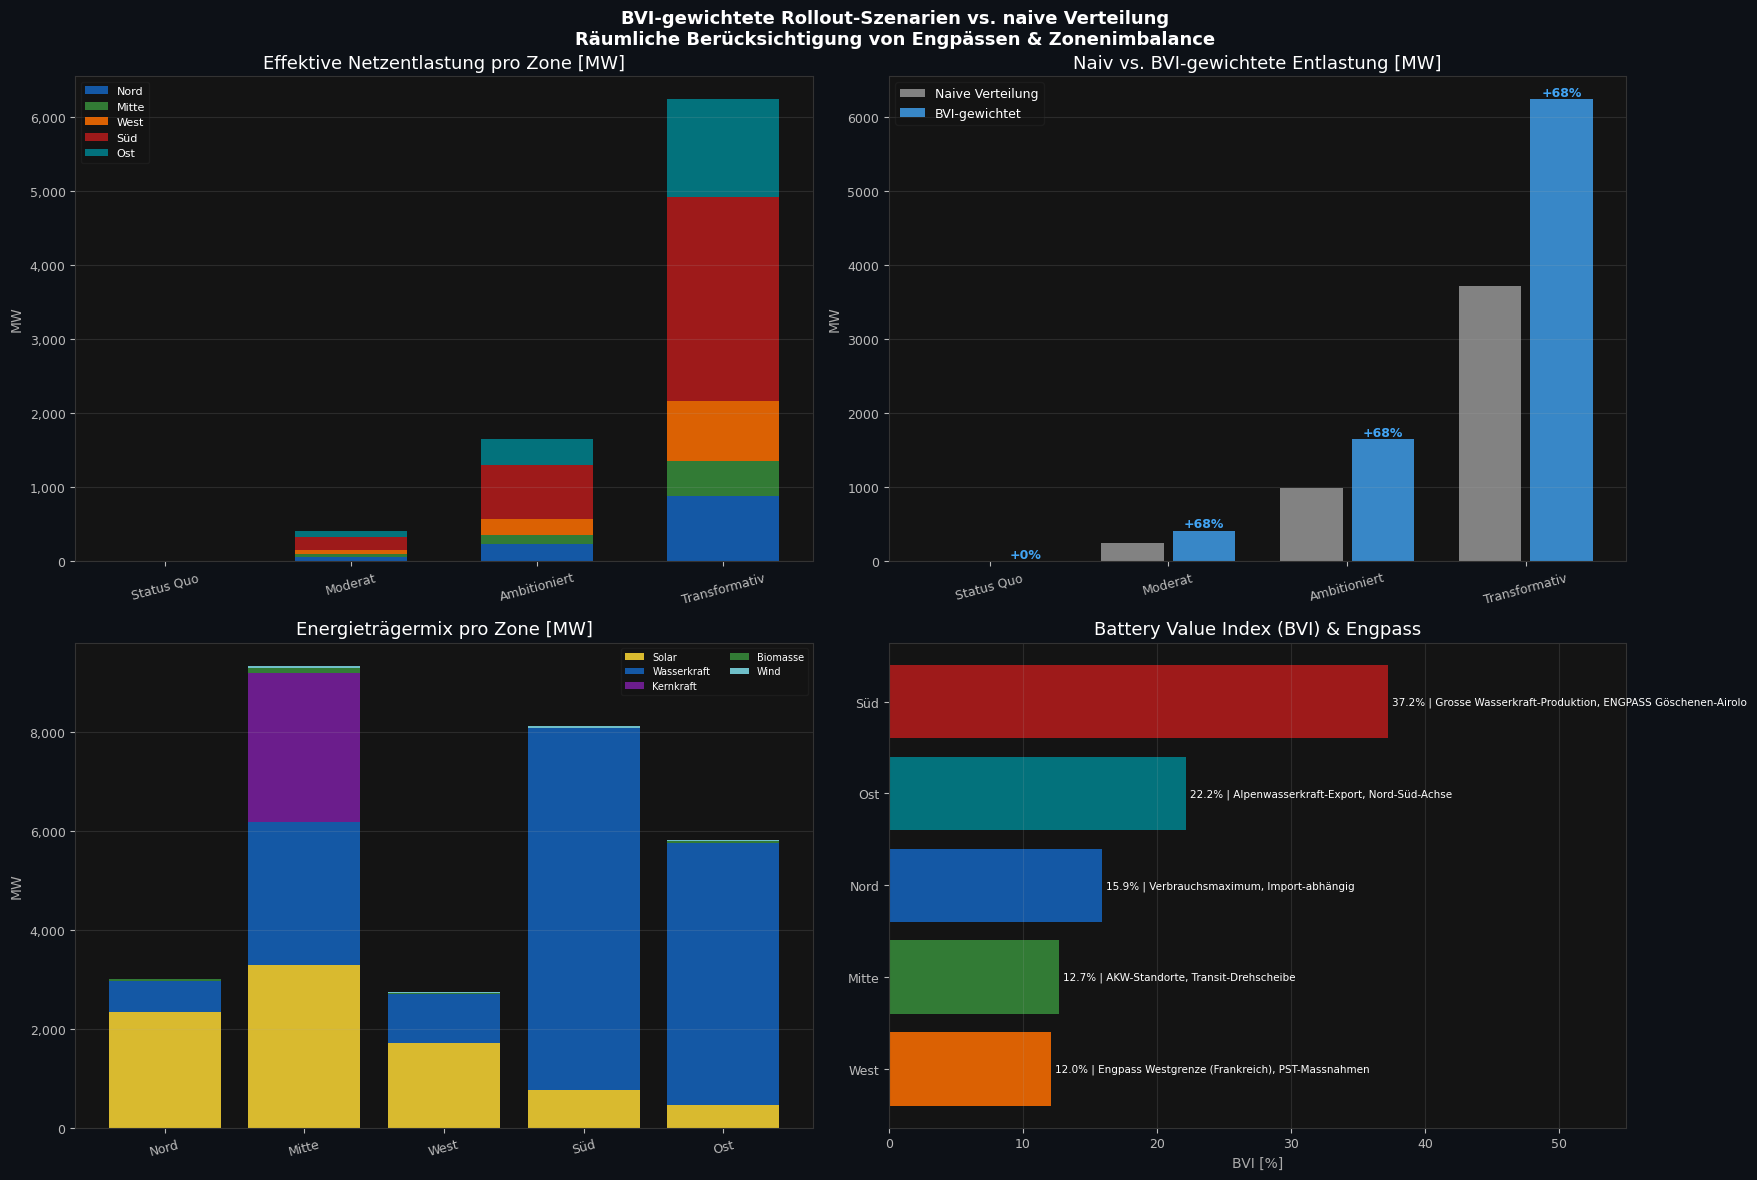

✅ Chart C gespeichert: ../output\charts\realistisch\kuer_k01_rollout_spatial.png


In [21]:
# ── 5.7 Chart C: BVI-gewichtete vs. naive Rollout-Szenarien ──────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.patch.set_facecolor(BG_DARK)
for ax in axes.flat:
    ax.set_facecolor(BG_PANEL); ax.tick_params(colors=C_TICK)
    for sp in ax.spines.values(): sp.set_edgecolor(C_SPINE)
fig.suptitle('BVI-gewichtete Rollout-Szenarien vs. naive Verteilung\n'
             'Räumliche Berücksichtigung von Engpässen & Zonenimbalance',
             color='white', fontsize=FS_TITEL, fontweight='bold')

sc_names_short = [s.split('(')[0].strip() for s in df_spatial['Szenario'].unique()]
sc_list = df_spatial['Szenario'].unique()
sc_colors_4 = ['#9E9E9E',C_PRIV,C_LOAD,C_PRICE]

# Panel 1: Effektive Entlastung pro Zone gestapelt
ax = axes[0, 0]
x   = np.arange(len(sc_list))
bot = np.zeros(len(sc_list))
for zone, col in ZONE_COLORS.items():
    vals = [df_spatial[(df_spatial['Szenario']==s) &
                       (df_spatial['Zone']==zone)]['Entlastung_eff_MW'].sum()
            for s in sc_list]
    ax.bar(x, vals, bottom=bot, label=zone, color=col, alpha=0.85, width=0.6)
    bot += np.array(vals)
ax.set_xticks(x); ax.set_xticklabels(sc_names_short, rotation=15)
ax.set_title('Effektive Netzentlastung pro Zone [MW]', color='white')
ax.set_ylabel('MW', color=C_ACHSE)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))
ax.legend(fontsize=FS_LEGENDE, framealpha=ALPHA_LEGENDE, facecolor=C_LEGENDE_BG, labelcolor='white')
ax.grid(True, axis='y', alpha=0.15)

# Panel 2: Naiv vs. BVI
ax = axes[0, 1]
naiv_mw_list, bvi_mw_list = [], []
for sc_name, n_p, n_g, n_i in SCENARIOS:
    naiv_mw_list.append((n_p*5 + n_g*30 + n_i*200) / 1000 * 0.70)
    bvi_mw_list.append(df_spatial[df_spatial['Szenario']==sc_name]['Entlastung_eff_MW'].sum())
xp = np.arange(len(SCENARIOS))
ax.bar(xp - 0.2, naiv_mw_list, 0.35, label='Naive Verteilung', color='#9E9E9E', alpha=0.8)
ax.bar(xp + 0.2, bvi_mw_list,  0.35, label='BVI-gewichtet',    color=C_PRIV, alpha=0.8)
for i, (n, b) in enumerate(zip(naiv_mw_list, bvi_mw_list)):
    mehr = (b/n-1)*100 if n > 0 else 0
    ax.text(i+0.2, b+2, f'+{mehr:.0f}%', ha='center', va='bottom',
            color=C_PRIV, fontsize=FS_TICK, fontweight='bold')
ax.set_xticks(xp); ax.set_xticklabels(sc_names_short, rotation=15)
ax.set_title('Naiv vs. BVI-gewichtete Entlastung [MW]', color='white')
ax.set_ylabel('MW', color=C_ACHSE)
ax.legend(fontsize=FS_TICK, framealpha=ALPHA_LEGENDE, facecolor=C_LEGENDE_BG, labelcolor='white')
ax.grid(True, axis='y', alpha=0.15)

# Panel 3: Kraftwerksmix pro Zone
ax = axes[1, 0]
if 'ET_group' in gdf_plants.columns and 'kw' in gdf_plants.columns:
    zone_et2 = gdf_plants.groupby(['Zone','ET_group'])['kw'].sum().unstack(fill_value=0) / 1000
    et2_plot = [e for e in ['Solar','Wasserkraft','Kernkraft','Biomasse','Wind','Andere']
                if e in zone_et2.columns]
    bot2 = np.zeros(len(ZONE_COLORS))
    for et in et2_plot:
        vals = [zone_et2.loc[z, et] if z in zone_et2.index else 0 for z in ZONE_COLORS]
        ax.bar(list(ZONE_COLORS.keys()), vals, bottom=bot2, label=et,
               color=ET_COLORS.get(et,'#9E9E9E'), alpha=0.85)
        bot2 += np.array(vals)
    ax.set_title('Energieträgermix pro Zone [MW]', color='white')
    ax.set_ylabel('MW', color=C_ACHSE)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))
    ax.legend(fontsize=FS_KLEIN, framealpha=ALPHA_LEGENDE, facecolor=C_LEGENDE_BG, labelcolor='white', ncol=2)
    ax.grid(True, axis='y', alpha=0.15)
    ax.tick_params(axis='x', rotation=15)

# Panel 4: BVI-Rangliste
ax = axes[1, 1]
bvi_sorted = df_zones.sort_values('BVI_norm', ascending=True)
colors_bvi = [ZONE_COLORS[z] for z in bvi_sorted['Zone']]
bars4 = ax.barh(bvi_sorted['Zone'], bvi_sorted['BVI_norm'], color=colors_bvi, alpha=0.85)
for bar, (_, row) in zip(bars4, bvi_sorted.iterrows()):
    txt = ZONE_BOTTLENECK[row['Zone']]
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{row["BVI_norm"]:.1f}% | {txt}',
            va='center', color='white', fontsize=7.5)
ax.set_title('Battery Value Index (BVI) & Engpass', color='white')
ax.set_xlabel('BVI [%]', color=C_ACHSE)
ax.set_xlim(0, 55)
ax.grid(True, axis='x', alpha=0.15)

plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'kuer_k01_rollout_spatial.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
plt.close()
print(f'✅ Chart C gespeichert: {p}')


**Einzelplot** (BVI-Balken für Bericht):

In [22]:
# ── BVI: Einzelplot Balken (für Strategie-Bericht) ───────────────────────────
bvi_s = df_zones[['Zone','BVI_norm','Engpass']].sort_values('BVI_norm', ascending=True)
colors_bvi_s = [ZONE_COLORS[z] for z in bvi_s['Zone']]

fig_bvi, ax_bvi = plt.subplots(figsize=(10, 5))
fig_bvi.patch.set_facecolor(BG_DARK)
ax_bvi.set_facecolor(BG_PANEL); ax_bvi.tick_params(colors=C_TICK)
for sp in ax_bvi.spines.values(): sp.set_edgecolor(C_SPINE)

bars_bvi = ax_bvi.barh(bvi_s['Zone'], bvi_s['BVI_norm'],
                        color=colors_bvi_s, alpha=0.85)
for bar, (_, row) in zip(bars_bvi, bvi_s.iterrows()):
    ax_bvi.text(bar.get_width() + 0.3, bar.get_y()+bar.get_height()/2,
                f'{row["BVI_norm"]:.1f}%  |  {row["Engpass"]}',
                va='center', color='white', fontsize=FS_TICK)

ax_bvi.set_xlabel('BVI [%]', color=C_ACHSE)
ax_bvi.set_title('Battery Value Index (BVI) pro Zone\n'
                 'Kombination aus Imbalance-Grösse und Engpassnähe',
                 color='white', fontsize=12, fontweight='bold')
ax_bvi.set_xlim(0, bvi_s['BVI_norm'].max() * 1.6)
ax_bvi.grid(True, axis='x', alpha=ALPHA_FLAECHE)
plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'kuer_k01_bvi_jahresdurchschnitt.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.close()
print(f'  Einzelplot: kuer_k01_bvi_jahresdurchschnitt.png')


  Einzelplot: kuer_k01_bvi_jahresdurchschnitt.png


**Chart C — [BVI](../organisation/O_02_Glossar.ipynb#g-bvi)-Szenarien.** BVI-gewichtete Verteilung erbringt gegenüber naiver Gleichverteilung **+68 % Mehrwert📊** — und zwar **skalenunabhängig** (in allen 3 Rollout-Szenarien identisch, weil das Verhältnis BVI-gewichteter zu naiver Verteilung allein von den Engpass-Multiplikatoren und der Zonenimbalance abhängt, nicht von der Anzahl Einheiten). Energieträgermix bestätigt Wasserkraft-Dominanz in Süd/Ost.

### 4.3 Erkenntnisse: BVI-Standortlogik

**BVI = Imbalance × Engpassmultiplikator**

Eine Batterie in einer [Engpasszone](../organisation/O_02_Glossar.ipynb#g-engpasszone) (z.B. Göschenen–Airolo-Achse) hat bis zu 2× den Netzwert gegenüber einer Batterie in einer ausgeglichenen Zone — bei identischen Investitionskosten.

> Privat-Einheiten ⚙ aus aktivem Szenario `realistisch` (`config.json → szenarien.optionen.realistisch.n_privat_*`); umschaltbar via `gleichzeitigkeit_aktiv`.

| Szenario             | Privat-Einheiten | Naiv→BVI-gewichtet [MW]📊 | Mehrwert📊 |
|----------------------|------------------|---------------------------|------------|
| Moderat (2027)       | 50'000⚙          | 245 → 411 MW              | +68 %      |
| Ambitioniert (2030)  | 200'000⚙         | 980 → 1647 MW             | +68 %      |
| Transformativ (2035) | 800'000⚙         | 3710 → 6236 MW            | +68 %      |

**Kernaussage:** Gleiche Anzahl Batterien, besserer Standort → kein Mehraufwand in der Förderung, deutlich mehr Netzwirkung. **Der Mehrwert-Faktor (+68 %) ist skalenunabhängig** — er wird allein durch das BVI-Gewichtungsschema und die Engpass-Multiplikatoren bestimmt; absolute MW-Werte skalieren linear mit der Anzahl Einheiten.

→ Abschnitt 5 visualisiert die Zonenverteilung als Schweizer Karten; Abschnitt 7 zeigt wie der BVI saisonal variiert.

---
## 5. Räumliche Karten <a id='visualisierungen-raeumliche-analyse_K_01'></a>

[↑ Inhaltsverzeichnis](#toc_K_01)

Alle Karten werden in **separaten Zellen** erstellt, damit einzelne Charts  
unabhängig ausgeführt und angepasst werden können.

| Zelle | Inhalt |
|-------|--------|
| 5.0 | Karten-Setup (Kantongrenzen, Hilfsfunktionen) |
| 5.1 | Karte: **Verbrauchszentren** (Bevölkerungsdichte Choropleth) |
| 5.2 | Karte: **Erzeuger** (Kraftwerke nach Typ + Leistung) |
| 5.3 | Karte: **Kombiniert + Engpässe** (Zonen + Pfeile) |
| 5.4 | Heatmap: **Tages-Lastprofil** pro Zone (Stunde × Zone) |
| 5.5 | Heatmap: **Produktions-Mix** pro Zone (Stunde × Energieträger) |
| 5.6 | Animation: **Tagesverlauf** Produktion vs. Verbrauch *(optional)* |
| 5.7 | Chart C: [BVI](../organisation/O_02_Glossar.ipynb#g-bvi)-Szenarien |


---
### 5.0 Karten-Setup

Kantonsgrenzen aus [swisstopo](../organisation/O_02_Glossar.ipynb#g-swisstopo) swissBOUNDARIES3D laden; Darstellungsparameter
(Projektion CH1903+/LV95, Farbpalette) für alle folgenden Karten setzen.


**🔎 Quellcode der importierten lib-Funktion**

`load_kantone` aus `lib/grid_topo.py` — lädt Schweizer Kantonsgrenzen
mit automatischer Kürzel-Detektion (Spalte `KAB`). Unten aufklappbar
der Quellcode.


In [23]:
show_source(load_kantone)


<details>
<summary>🔎 Quellcode: <code>load_kantone</code> (aus <code>lib/grid_topo.py</code>)</summary>

```python
def load_kantone(data_dirs, download_url=None, download_target=None,
                 min_file_size=50_000, verbose=True):
    """Lädt Schweizer Kantonsgrenzen aus GeoPackage-Cache.

    Probiert mehrere Pfad-Kandidaten nacheinander, wählt den ersten der
    existiert und gross genug ist. Normalisiert auf EPSG:4326, ergänzt
    eine ``KAB``-Spalte mit 2-Buchstaben-Kürzeln.

    Parameter
    ---------
    data_dirs : list[str] oder str
        Liste von Dateipfaden zu kantone.gpkg oder swissboundaries3d.gpkg
        die nacheinander probiert werden. Einzelner String wird automatisch
        in eine Liste gewandelt.
    download_url : str, optional
        URL zu einem swissBOUNDARIES3D ZIP. Wenn gesetzt UND alle Pfade
        fehlschlagen, wird das ZIP heruntergeladen, .gpkg extrahiert und
        unter ``download_target`` gespeichert.
    download_target : str, optional
        Zielpfad für den Download (nur genutzt wenn ``download_url`` gesetzt).
    min_file_size : int, default 50_000 (50 KB)
        Minimale Dateigrösse in Bytes für eine Cache-Datei als gültig.
    verbose : bool, default True
        Status-Meldungen auf stdout.

    Return
    ------
    geopandas.GeoDataFrame oder None
        Kantone-GeoDataFrame mit Spalten inkl. ``KAB`` (2-Buchstaben-Kürzel)
        und CRS EPSG:4326. ``None`` wenn kein Cache gefunden UND
        (Download nicht versucht ODER fehlgeschlagen).
    """
    import geopandas as gpd

    if isinstance(data_dirs, str):
        data_dirs = [data_dirs]

    # ── Schritt 1: Cache-Datei finden ─────────────────────────────────────────
    kant_file = None
    for path in data_dirs:
        if os.path.exists(path) and os.path.getsize(path) > min_file_size:
            kant_file = path
            break

    # ── Schritt 2: Download-Fallback ──────────────────────────────────────────
    if kant_file is None and download_url and download_target:
        if verbose:
            print(f'Kantone-Cache fehlt — lade swissBOUNDARIES3D...')
        try:
            import requests
            import zipfile
            zip_path = download_target + '.zip'
            r = requests.get(download_url, timeout=120, stream=True)
            r.raise_for_status()
            with open(zip_path, 'wb') as f:
                for chunk in r.iter_content(1024 * 512):
                    f.write(chunk)
            with zipfile.ZipFile(zip_path) as z:
                gpkg_in_zip = next((n for n in z.namelist()
                                    if n.lower().endswith('.gpkg')), None)
                if gpkg_in_zip:
                    with z.open(gpkg_in_zip) as src, open(download_target, 'wb') as dst:
                        dst.write(src.read())
                    kant_file = download_target
                    if verbose:
                        print(f'  Extrahiert: {kant_file}')
        except Exception as e:
            if verbose:
                print(f'  Download fehlgeschlagen: {e}')

    if kant_file is None:
        if verbose:
            print('⚠️  Kantone nicht gefunden — Karte ohne Grenzen')
        return None

    # ── Schritt 3: Laden + CRS-Normalisierung ─────────────────────────────────
    try:
        layers = gpd.list_layers(kant_file)
        lname = next((l for l in layers['name'] if 'kanton' in l.lower()),
                     layers['name'].iloc[0])
        gdf = gpd.read_file(kant_file, layer=lname)
        if gdf.crs and gdf.crs.to_epsg() != 4326:
            gdf = gdf.to_crs(epsg=4326)
    except Exception as e:
        if verbose:
            print(f'  Ladefehler: {e}')
        return None

    # ── Schritt 4: KAB-Spalte ableiten — WERTE-basiert (robust gegen Schema-Änderungen)
    # Spaltenname ist NICHT die Wahrheit (z.B. swissBOUNDARIES3D 2026-01 hat
    # eine 'icc'-Spalte mit 'CH' = Land-Code, nicht Kantonskürzel). Wir prüfen
    # daher die WERTE jeder Spalte gegen die drei möglichen Repräsentationen:
    # (1) Kürzel als String, (2) Nummer 1-26, (3) Kantonsname.
    import pandas as pd

    # Vorhandene KAB-Spalte zuerst entfernen, falls die Werte fragwürdig sind.
    # Robust: prüfe sowohl Anzahl valider Kürzel ALS AUCH Eindeutigkeit
    # (eine Spalte mit allen 'FR' hat 26 valide Kürzel aber nur 1 unique →
    # ist offensichtlich keine Kantons-ID).
    if 'KAB' in gdf.columns:
        pre = gdf['KAB'].astype(str).str.strip().str.upper()
        n_valid_pre  = pre.isin(KANT_ABK_SET).sum()
        n_unique_pre = pre[pre.isin(KANT_ABK_SET)].nunique()
        if n_valid_pre < 20 or n_unique_pre < 20:
            if verbose:
                print(f'  Vorhandene KAB-Spalte ist nicht valide '
                      f'(valid={n_valid_pre}, unique={n_unique_pre}, '
                      f'Sample: {pre.head(3).tolist()}) — Strategien anwenden')
            gdf = gdf.drop(columns=['KAB'])
        else:
            gdf['KAB'] = pre

    found = False

    # ── Strategie 1: Spalte mit Werten = 2-Buchstaben-Kürzel ─────────────────
    # Validierung: >=20 valide UND >=20 verschiedene Werte (nicht alle gleich)
    if 'KAB' not in gdf.columns:
        for col in gdf.columns:
            if col == 'geometry':
                continue
            try:
                vals = gdf[col].astype(str).str.strip().str.upper()
                valid_mask = vals.isin(KANT_ABK_SET)
                n_valid  = valid_mask.sum()
                n_unique = vals[valid_mask].nunique()
                if n_valid >= 20 and n_unique >= 20:
                    gdf['KAB'] = vals
                    if verbose:
                        print(f'  KAB via Kürzel-Werte in "{col}" '
                              f'({n_valid}/{len(gdf)} Treffer, {n_unique} unique)')
                    found = True
                    break
            except Exception:
                continue

    # ── Strategie 2: Spalte mit Zahlen 1..26 (Kantons-Nummer) ─────────────────
    # KRITISCH: erstellung_monat hat auch Werte 1-12 in [1,26] und würde sonst
    # fälschlich als Kantonsnummer interpretiert. Eindeutigkeit prüfen!
    # Echte Kantone: 26 verschiedene Nummern. erstellung_monat: max 12.
    if not found:
        for col in gdf.columns:
            if col == 'geometry':
                continue
            try:
                nums = pd.to_numeric(gdf[col], errors='coerce')
                between = nums.between(1, 26)
                n_in    = between.sum()
                n_uniq  = nums[between].nunique()
                if n_in >= 20 and n_uniq >= 20:
                    gdf['KAB'] = nums.map(KANT_NUM_TO_ABK).fillna('??')
                    if verbose:
                        print(f'  KAB via Kantonsnummer-Werte in "{col}" '
                              f'({n_in}/{len(gdf)} Treffer, {n_uniq} unique)')
                    found = True
                    break
            except Exception:
                continue

    # ── Strategie 3: Spalte mit Kantonsnamen (DE/FR/IT) ───────────────────────
    # Auch hier nunique prüfen — falls eine Spalte versehentlich denselben Namen
    # häufig wiederholt
    if not found:
        for col in gdf.columns:
            if col == 'geometry':
                continue
            try:
                mapped  = gdf[col].astype(str).str.strip().map(KANT_NAME_TO_ABK)
                n_map   = mapped.notna().sum()
                n_uniq  = mapped.dropna().nunique()
                if n_map >= 20 and n_uniq >= 20:
                    gdf['KAB'] = mapped.fillna('??')
                    if verbose:
                        print(f'  KAB via Kantonsname-Werte in "{col}" '
                              f'({n_map}/{len(gdf)} Treffer, {n_uniq} unique)')
                    found = True
                    break
            except Exception:
                continue

    # ── Diagnose bei Misserfolg ───────────────────────────────────────────────
    if not found:
        if 'KAB' not in gdf.columns:
            gdf['KAB'] = '??'
        if verbose:
            print(f'⚠️  KAB konnte nicht abgeleitet werden — keine Strategie greift.')
            print(f'   Verfügbare Spalten + Beispielwerte:')
            for c in gdf.columns:
                if c == 'geometry':
                    continue
                sample = gdf[c].iloc[0] if len(gdf) else '(leer)'
                print(f'     {c!r:25s} = {sample!r}')

    if verbose:
        n_valid = gdf['KAB'].isin(KANT_ABK_SET).sum() if 'KAB' in gdf.columns else 0
        print(f'Kantone: {len(gdf)} | {n_valid} valide Kürzel | {os.path.basename(kant_file)}')

    return gdf
```

</details>


In [24]:
# ── 5.0 Karten-Setup: Kantongrenzen ─────────────────────────────────────────
# Lädt Schweizer Kantonsgrenzen (kantone.gpkg aus K_01-Cache oder swisstopo-Download)
# via lib.grid_topo.load_kantone. Die Funktion ergänzt eine 'KAB'-Spalte mit
# 2-Buchstaben-Kürzeln und normalisiert auf EPSG:4326.

_KANT_CANDIDATES = [
    os.path.join(DATA_DIR, 'kantone.gpkg'),
    os.path.join('data', 'kantone.gpkg'),
    os.path.join('data', 'CH_storymap', 'kantone.gpkg'),
]
_ZIP_URL = ('https://data.geo.admin.ch/ch.swisstopo.swissboundaries3d'
            '/swissboundaries3d_2026-01'
            '/swissboundaries3d_2026-01_2056_5728.gpkg.zip')
_KANT_FILE_TARGET = os.path.join(DATA_DIR, 'kantone.gpkg')

gdf_kant = load_kantone(
    data_dirs=_KANT_CANDIDATES,
    download_url=_ZIP_URL,
    download_target=_KANT_FILE_TARGET,
)

# Für Rückwärtskompatibilität: KANTON_ABB_COL-Info (lib setzt direkt 'KAB')
KANTON_ABB_COL = 'KAB' if gdf_kant is not None and 'KAB' in gdf_kant.columns else None

kuerzel_set = set(KANTON_TO_ZONE.keys())
if gdf_kant is not None:
    # Defensive: falls lib.load_kantone die KAB-Spalte mit Whitespace/Casing
    # durchgereicht hat (kommt bei manchen swissBOUNDARIES3D-Versionen vor)
    gdf_kant['KAB'] = gdf_kant['KAB'].astype(str).str.strip().str.upper()

    unknown = gdf_kant[~gdf_kant['KAB'].isin(kuerzel_set)]['KAB'].unique()
    if len(unknown): print(f'Unbekannt: {unknown}')
    gdf_kant['Zone']     = gdf_kant['KAB'].map(KANTON_TO_ZONE).fillna('Mitte')
    gdf_kant['Pop']      = gdf_kant['KAB'].map(KANTON_POP).fillna(0)
    gdf_kant['ZColor']   = gdf_kant['Zone'].map(ZONE_COLORS)
    gdf_area             = gdf_kant.to_crs(epsg=2056)
    gdf_kant['Area_km2'] = gdf_area.geometry.area / 1e6
    gdf_kant['Dichte']   = (gdf_kant['Pop'] / gdf_kant['Area_km2'].replace(0,np.nan)).round(1)

    # Diagnose: wenn Pop-Mapping fehlschlägt, ist die Choropleth alle gleichfarbig
    n_pop_ok = (gdf_kant['Pop'] > 0).sum()
    if n_pop_ok < 20:
        print(f'⚠️  Pop-Mapping schlägt fehl: nur {n_pop_ok}/{len(gdf_kant)} Kantone valid')
        print(f'   gdf_kant.KAB Sample: {gdf_kant["KAB"].head(8).tolist()}')
        print(f'   KANTON_POP-Keys    : {sorted(KANTON_POP.keys())[:8]} ...')
        print(f'   → Choropleth wird unterbrochen sein. Lib-Update auf neuere grid_topo nötig.')

    print('Angereichert – Top 5 Dichte:')
    print(gdf_kant[['KAB','Zone','Pop','Dichte']].nlargest(5,'Dichte').to_string(index=False))

def draw_base_map(ax, color_col='ZColor', alpha=0.30, title='', edgecolor='#555555'):
    ax.set_xlim(5.85,10.65); ax.set_ylim(45.75,47.95)
    ax.set_facecolor('#0a0e1a'); ax.set_axis_off()
    if title: ax.set_title(title, color='white', fontsize=11, pad=8)
    if gdf_kant is not None:
        for _, row in gdf_kant.iterrows():
            col = row.get(color_col,'#1c2040') if color_col in gdf_kant.columns else '#1c2040'
            try:
                gpd.GeoDataFrame(geometry=[row.geometry],crs='EPSG:4326').plot(
                    ax=ax,color=col,alpha=alpha,linewidth=0.7,edgecolor=edgecolor)
            except: pass
    else:
        ax.text(0.5,0.5,'Kantongrenzen fehlen',ha='center',va='center',
                color='#888',transform=ax.transAxes)

KANTONSHAUPTORTE = {
    'ZH':(8.55,47.37),'BE':(7.45,46.95),'LU':(8.31,47.05),'UR':(8.73,46.88),
    'SZ':(8.65,47.02),'OW':(8.24,46.90),'NW':(8.36,46.99),'GL':(9.07,47.04),
    'ZG':(8.52,47.17),'FR':(7.16,46.80),'SO':(7.54,47.21),'BS':(7.59,47.56),
    'BL':(7.73,47.48),'SH':(8.63,47.70),'AR':(9.41,47.38),'AI':(9.41,47.33),
    'SG':(9.37,47.43),'GR':(9.53,46.85),'AG':(8.04,47.39),'TG':(8.90,47.56),
    'TI':(8.95,46.01),'VD':(6.63,46.52),'VS':(7.36,46.23),'NE':(6.93,46.99),
    'GE':(6.15,46.20),'JU':(7.34,47.36),
}
ENGPASSLINIEN = [
    (8.62,46.63,8.62,47.08,'Göschenen-\nAirolo',  0.20, 0.0),
    (7.10,46.82,6.35,46.48,'Westgrenze\nFR-CH',   -0.35,-0.12),
    (8.04,47.40,8.62,47.40,'AG-ZH\nMittelland',    0.02,-0.14),
]
print('\nKarten-Setup abgeschlossen.')


Kantone-Cache fehlt — lade swissBOUNDARIES3D...


  Extrahiert: ../data\raw\kantone.gpkg
  KAB via Kantonsnummer-Werte in "kantonsnummer" (26/26 Treffer, 26 unique)
Kantone: 26 | 26 valide Kürzel | kantone.gpkg
Angereichert – Top 5 Dichte:
KAB  Zone     Pop  Dichte
 BS Mitte  201384  5449.6
 GE  West  531102  1880.1
 ZH  Nord 1620020   937.0
 BL Mitte  301323   582.1
 ZG Mitte  133739   560.2

Karten-Setup abgeschlossen.


**Kantongrenzen.** swissBOUNDARIES3D von [swisstopo](../organisation/O_02_Glossar.ipynb#g-swisstopo). Drei werte-basierte Erkennungsstrategien für KAB-Spalte: (1) Spalte mit Werten = 2-Buchstaben-Kürzel (≥20 unique), (2) Spalte mit Zahlen 1–26 (Kantonsnummer, ≥20 unique — verhindert `erstellung_monat`-Falle), (3) Spalte mit Kantonsnamen → `KANT_NAME_TO_ABK` (DE/FR/IT). Spaltennamen-Heuristik bewusst nicht verwendet, da bei swissBOUNDARIES3D 2026-01 die Spalte `icc` den Land-Code `CH` enthält, nicht das Kantonskürzel.

---
### 5.1 Karte: Verbrauchszentren

*Bevölkerungsdichte als Choropleth — zeigt wo der Strom gebraucht wird.*


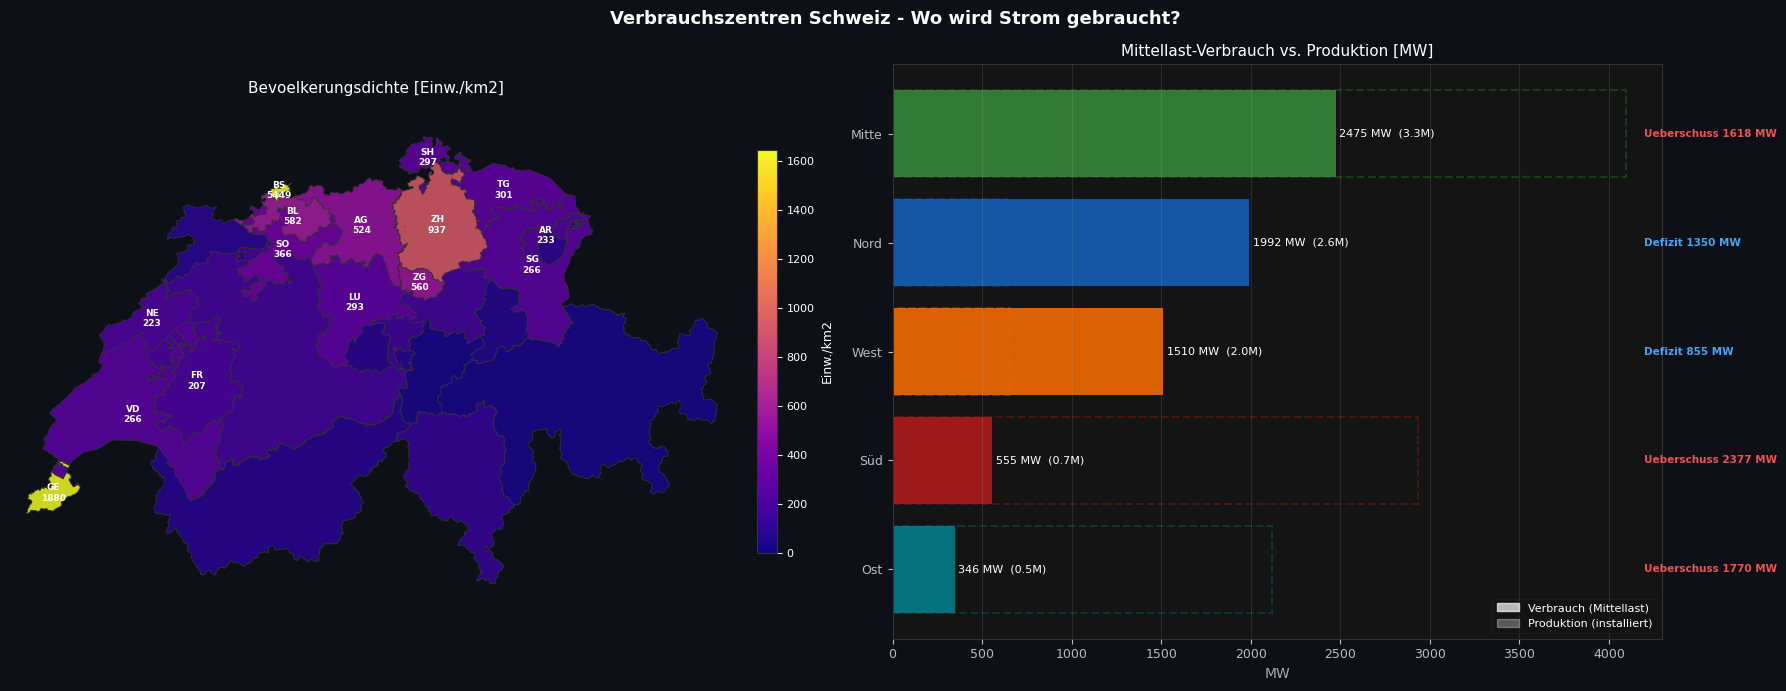

Karte 1 gespeichert: ../output\charts\realistisch\kuer_k01_karte_verbrauchszentren.png


In [25]:
# ── 5.1 Karte: Verbrauchszentren ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Verbrauchszentren Schweiz - Wo wird Strom gebraucht?',
             color='white', fontsize=FS_TITEL, fontweight='bold')

# ── Panel 1: Bevölkerungsdichte Choropleth ────────────────────────────────────
ax = axes[0]
ax.set_xlim(5.85, 10.65); ax.set_ylim(45.75, 47.95)
ax.set_facecolor('#0a0e1a'); ax.set_axis_off()
ax.set_title('Bevoelkerungsdichte [Einw./km2]', color='white', fontsize=11, pad=8)

if gdf_kant is not None and 'Dichte' in gdf_kant.columns:
    norm_d = Normalize(vmin=0, vmax=gdf_kant['Dichte'].quantile(0.95))
    cmap_d = cm.get_cmap('plasma')
    for _, row in gdf_kant.iterrows():
        col = cmap_d(norm_d(row['Dichte']))
        try:
            gpd.GeoDataFrame(geometry=[row.geometry], crs='EPSG:4326').plot(
                ax=ax, color=col, alpha=0.85, linewidth=0.6, edgecolor=C_SPINE)
        except Exception:
            pass
    sm = plt.cm.ScalarMappable(cmap=cmap_d, norm=norm_d)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02, shrink=0.7)
    cbar.set_label('Einw./km2', color='white', fontsize=FS_TICK)
    cbar.ax.tick_params(colors='white', labelsize=8)
    for _, row in gdf_kant.iterrows():
        if row['Dichte'] > 200:
            cx = row.geometry.centroid.x
            cy = row.geometry.centroid.y
            # FIX: kein \n in f-string mit einfachen Quotes → str concat
            label = row['KAB'] + '\n' + str(int(row['Dichte']))
            ax.text(cx, cy, label, ha='center', va='center',
                    color='white', fontsize=6.5, fontweight='bold', zorder=5)
else:
    ax.text(0.5, 0.5, 'Kantondaten nicht verfuegbar',
            ha='center', va='center', color='#888', transform=ax.transAxes)

# ── Panel 2: Verbrauch vs. Produktion pro Zone ────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(BG_PANEL)
for sp in ax2.spines.values(): sp.set_edgecolor(C_SPINE)
ax2.tick_params(colors=C_TICK)

zone_verbrauch = df_zones.sort_values('Verbrauch_MW', ascending=True)
bar_colors = [ZONE_COLORS[z] for z in zone_verbrauch['Zone']]

bars = ax2.barh(zone_verbrauch['Zone'], zone_verbrauch['Verbrauch_MW'],
                color=bar_colors, alpha=0.85)
ax2.barh(zone_verbrauch['Zone'], zone_verbrauch['Produktion_MW'],
         color=bar_colors, alpha=0.30, linewidth=LW,
         edgecolor=bar_colors, fill=False, linestyle='--', label='Produktion')

for bar, (_, row) in zip(bars, zone_verbrauch.iterrows()):
    # FIX: str concat statt \n in f-string
    txt = f'{row["Verbrauch_MW"]:.0f} MW' + '  (' + f'{row["Bevoelkerung"]/1e6:.1f}' + 'M)'
    ax2.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
             txt, va='center', color='white', fontsize=FS_LEGENDE)

ax2.set_title('Mittellast-Verbrauch vs. Produktion [MW]', color='white', fontsize=11)
ax2.set_xlabel('MW', color=C_ACHSE)
ax2.grid(True, axis='x', alpha=0.15)

for _, row in zone_verbrauch.iterrows():
    imb = row['Imbalance_MW']
    sym = 'UP' if imb > 0 else 'DN'
    col = C_UTIL if imb > 0 else C_PRIV
    label = ('Ueberschuss' if imb > 0 else 'Defizit') + f' {abs(imb):.0f} MW'
    ypos = list(zone_verbrauch['Zone']).index(row['Zone'])
    ax2.text(max(zone_verbrauch['Verbrauch_MW'].max(),
                 zone_verbrauch['Produktion_MW'].max()) + 100,
             ypos, label, va='center', color=col, fontsize=7.5, fontweight='bold')

p_v = mpatches.Patch(color='white', alpha=0.7, label='Verbrauch (Mittellast)')
p_p = mpatches.Patch(color='white', alpha=0.3, label='Produktion (installiert)')
ax2.legend(handles=[p_v, p_p], fontsize=FS_LEGENDE, framealpha=ALPHA_LEGENDE,
           facecolor=C_LEGENDE_BG, labelcolor='white')

plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'kuer_k01_karte_verbrauchszentren.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
plt.close()
print(f'Karte 1 gespeichert: {p}')


**Einzelplot** (Zonenimbalance-Balken für Bericht):

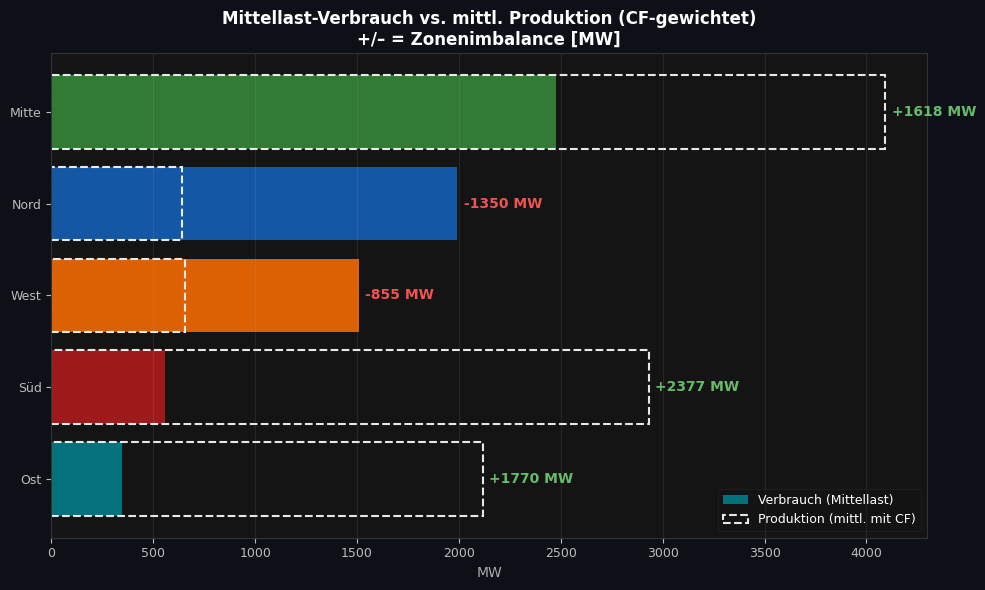

  Einzelplot: kuer_k01_karte_zonenimbalance.png


In [26]:
# ── Karte 1: Einzelplot Balkendiagramm ────────────────────────────────────────
# Rechtes Panel (Verbrauch vs. Produktion) als grösseres Einzelbild
zone_verbrauch_s = df_zones[['Zone','Verbrauch_MW','Produktion_MW','Bevoelkerung']].copy()
zone_verbrauch_s = zone_verbrauch_s.sort_values('Verbrauch_MW', ascending=True)
bar_colors_s = [ZONE_COLORS[z] for z in zone_verbrauch_s['Zone']]

fig_k1, ax_k1 = plt.subplots(figsize=(10, 6))
fig_k1.patch.set_facecolor(BG_DARK)
ax_k1.set_facecolor(BG_PANEL); ax_k1.tick_params(colors=C_TICK)
for sp in ax_k1.spines.values(): sp.set_edgecolor(C_SPINE)

ax_k1.barh(zone_verbrauch_s['Zone'], zone_verbrauch_s['Verbrauch_MW'],
           color=bar_colors_s, alpha=0.85, label='Verbrauch (Mittellast)')
ax_k1.barh(zone_verbrauch_s['Zone'], zone_verbrauch_s['Produktion_MW'],
           color='none', alpha=0.9, edgecolor='white', linewidth=LW,
           linestyle='--', label='Produktion (mittl. mit CF)')

for _, row in zone_verbrauch_s.iterrows():
    imb = row['Produktion_MW'] - row['Verbrauch_MW']
    col = C_LOAD if imb > 0 else C_UTIL
    ax_k1.text(max(row['Verbrauch_MW'], row['Produktion_MW']) + 30, row['Zone'],
               f'{imb:+.0f} MW', va='center', color=col, fontsize=FS_ACHSE, fontweight='bold')

ax_k1.set_xlabel('MW', color=C_ACHSE)
ax_k1.set_title('Mittellast-Verbrauch vs. mittl. Produktion (CF-gewichtet)\n'
                '+/– = Zonenimbalance [MW]', color='white', fontsize=12, fontweight='bold')
ax_k1.legend(fontsize=FS_TICK, framealpha=ALPHA_LEGENDE, facecolor=C_LEGENDE_BG, labelcolor='white')
ax_k1.grid(True, axis='x', alpha=ALPHA_FLAECHE)
plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'kuer_k01_karte_zonenimbalance.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
plt.close()
print(f'  Einzelplot: kuer_k01_karte_zonenimbalance.png')


**Karte 1 — Verbrauchszentren.** Links: Choropleth Bevölkerungsdichte. Rechts: Balkendiagramm mittlere Produktion (mit CF) vs. Mittellastverbrauch pro Zone.

---
### 5.2 Karte: Erzeuger nach Typ

*Kraftwerksstandorte mit Leistung — zeigt wo Strom produziert wird.*


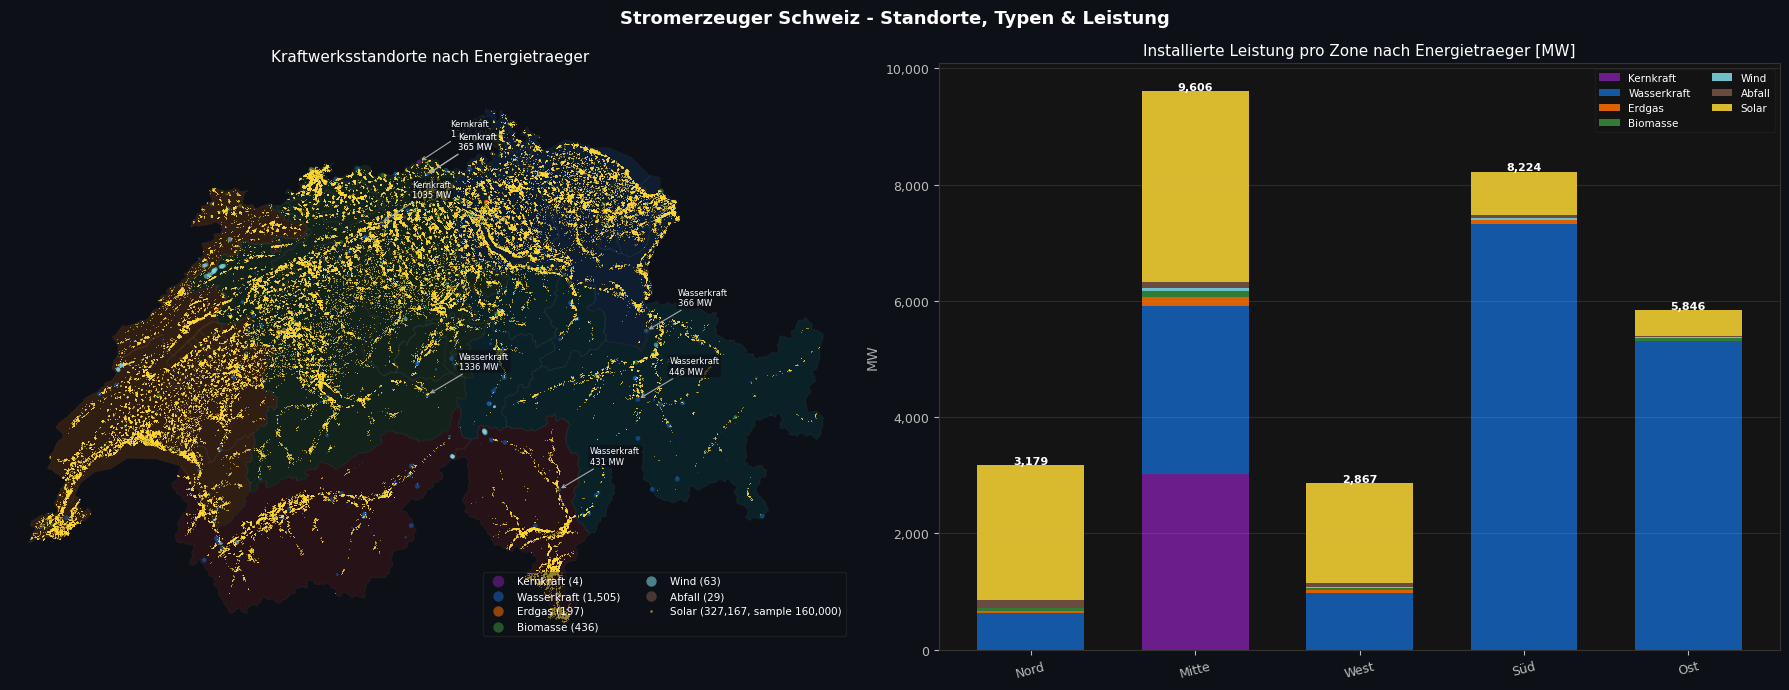

Karte 2 gespeichert: ../output\charts\realistisch\kuer_k01_karte_erzeuger.png
Solar: 327,167 Anlagen, davon 160,000 dargestellt (random sample)


In [27]:
# ── 5.2 Karte: Erzeuger nach Typ ─────────────────────────────────────────────
# ── Parameter (hier anpassen) ─────────────────────────────────────────────────
PUNKT_GROESSE_MAX   = 12      # Maximale Punktgrösse [pt²] für grosse Kraftwerke
PUNKT_GROESSE_MIN   = 0.3     # Minimale Punktgrösse [pt²]
PUNKT_GROESSE_SOLAR = 0.4     # Fixgrösse Solar (kW-Skalierung unnötig, zu viele Punkte)
SOLAR_MAX_PUNKTE    = 160_000   # Solar-Stichprobe: mehr bringt visuell nichts, verlangsamt stark
# ──────────────────────────────────────────────────────────────────────────────

ET_ORDER = ['Kernkraft','Wasserkraft','Erdgas','Biomasse',
            'Wind','Abfall','Andere','Solar']

if 'ET_group' not in gdf_plants.columns:
    gdf_plants['ET_group'] = gdf_plants.get('ET', pd.Series('Andere', index=gdf_plants.index))
    gdf_plants['ET_group'] = gdf_plants['ET_group'].apply(
        lambda x: x if x in ET_COLORS else 'Andere')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Stromerzeuger Schweiz - Standorte, Typen & Leistung',
             color='white', fontsize=FS_TITEL, fontweight='bold')

# ── Panel 1: Karte ────────────────────────────────────────────────────────────
ax = axes[0]
draw_base_map(ax, alpha=0.15, title='Kraftwerksstandorte nach Energietraeger')

for et in ET_ORDER:
    sub = gdf_plants[gdf_plants['ET_group'] == et]
    if len(sub) == 0: continue
    col = ET_COLORS.get(et, '#9E9E9E')

    # Solar: Stichprobe + fixer Punktdurchmesser (320k Punkte = Flaschenhals)
    if et == 'Solar' and len(sub) > SOLAR_MAX_PUNKTE:
        sub = sub.sample(SOLAR_MAX_PUNKTE, random_state=42)
        label = f'Solar ({len(gdf_plants[gdf_plants["ET_group"]=="Solar"]):,}, sample {SOLAR_MAX_PUNKTE:,})'
        sizes = PUNKT_GROESSE_SOLAR
    else:
        label = f'{et} ({len(sub):,})'
        if 'kw' in sub.columns and sub['kw'].max() > 0:
            # Vektorisiert mit numpy — kein pandas-overhead
            kw = sub['kw'].to_numpy(dtype=float)
            p95 = max(float(np.percentile(kw, 95)), 1.0)
            sizes = np.clip(kw / p95 * PUNKT_GROESSE_MAX,
                            PUNKT_GROESSE_MIN, PUNKT_GROESSE_MAX)
        else:
            sizes = PUNKT_GROESSE_MIN

    # xy als numpy-Arrays vorab extrahieren (schneller als geometry.x/.y in scatter)
    xy = np.column_stack([sub.geometry.x.to_numpy(), sub.geometry.y.to_numpy()])

    ax.scatter(xy[:, 0], xy[:, 1],
               s=sizes, c=col, alpha=0.55, label=label,
               linewidths=0, zorder=3, rasterized=True)

ax.legend(fontsize=7.5, framealpha=0.4, facecolor=BG_DARK,
          labelcolor='white', loc='lower right', markerscale=3, ncol=2)

if 'kw' in gdf_plants.columns:
    top = gdf_plants[gdf_plants.geometry.notna()].nlargest(8, 'kw')
    for _, row in top.iterrows():
        lbl = row['ET_group'] + '\n' + f'{row["kw"]/1000:.0f} MW'
        ax.annotate(lbl,
                    xy=(row.geometry.x, row.geometry.y),
                    xytext=(row.geometry.x + 0.18, row.geometry.y + 0.10),
                    color='white', fontsize=6, zorder=6,
                    arrowprops=dict(arrowstyle='->', color=C_ACHSE, lw=LW_DUENN),
                    bbox=dict(boxstyle='round,pad=0.2', fc=BG_DARK, alpha=0.7, lw=0))

# ── Panel 2: Leistung pro Zone nach ET ───────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(BG_PANEL)
for sp in ax2.spines.values(): sp.set_edgecolor(C_SPINE)
ax2.tick_params(colors=C_TICK)

if 'ET_group' in gdf_plants.columns and 'kw' in gdf_plants.columns:
    zone_et = gdf_plants.groupby(['Zone','ET_group'])['kw'].sum().unstack(fill_value=0) / 1000
    et_cols  = [e for e in ET_ORDER if e in zone_et.columns]
    bottom   = np.zeros(len(ZONE_COLORS))
    zones    = list(ZONE_COLORS.keys())
    for et in et_cols:
        vals = np.array([zone_et.loc[z, et] if z in zone_et.index else 0 for z in zones])
        ax2.bar(zones, vals, bottom=bottom, label=et,
                color=ET_COLORS.get(et,'#9E9E9E'), alpha=0.85, width=0.65)
        bottom += vals
    ax2.set_title('Installierte Leistung pro Zone nach Energietraeger [MW]',
                  color='white', fontsize=11)
    ax2.set_ylabel('MW', color=C_ACHSE)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))
    ax2.legend(fontsize=7.5, framealpha=ALPHA_LEGENDE, facecolor=C_LEGENDE_BG,
               labelcolor='white', ncol=2, loc='upper right')
    ax2.grid(True, axis='y', alpha=0.15)
    ax2.tick_params(axis='x', rotation=15)
    for i, zone in enumerate(zones):
        total = zone_et.loc[zone].sum() if zone in zone_et.index else 0
        ax2.text(i, total + 20, f'{total:,.0f}', ha='center',
                 color='white', fontsize=FS_LEGENDE, fontweight='bold')

plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'kuer_k01_karte_erzeuger.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
plt.close()
print(f'Karte 2 gespeichert: {p}')
print(f'Solar: {len(gdf_plants[gdf_plants["ET_group"]=="Solar"]):,} Anlagen, '
      f'davon {SOLAR_MAX_PUNKTE:,} dargestellt (random sample)')


**Karte 2 — Erzeuger.** ~329k Anlagen📊 nach Energieträger (Solar als Sample, Übrige vollständig). Zonenfarbe (Hintergrund) und Punktfarbe (ET) sind zwei unabhängige Informationsebenen.

---
### 5.3 Karte: Kombiniert + Engpässe

*Verbraucher, Erzeuger und Swissgrid-Engpässe in einer Übersicht.*


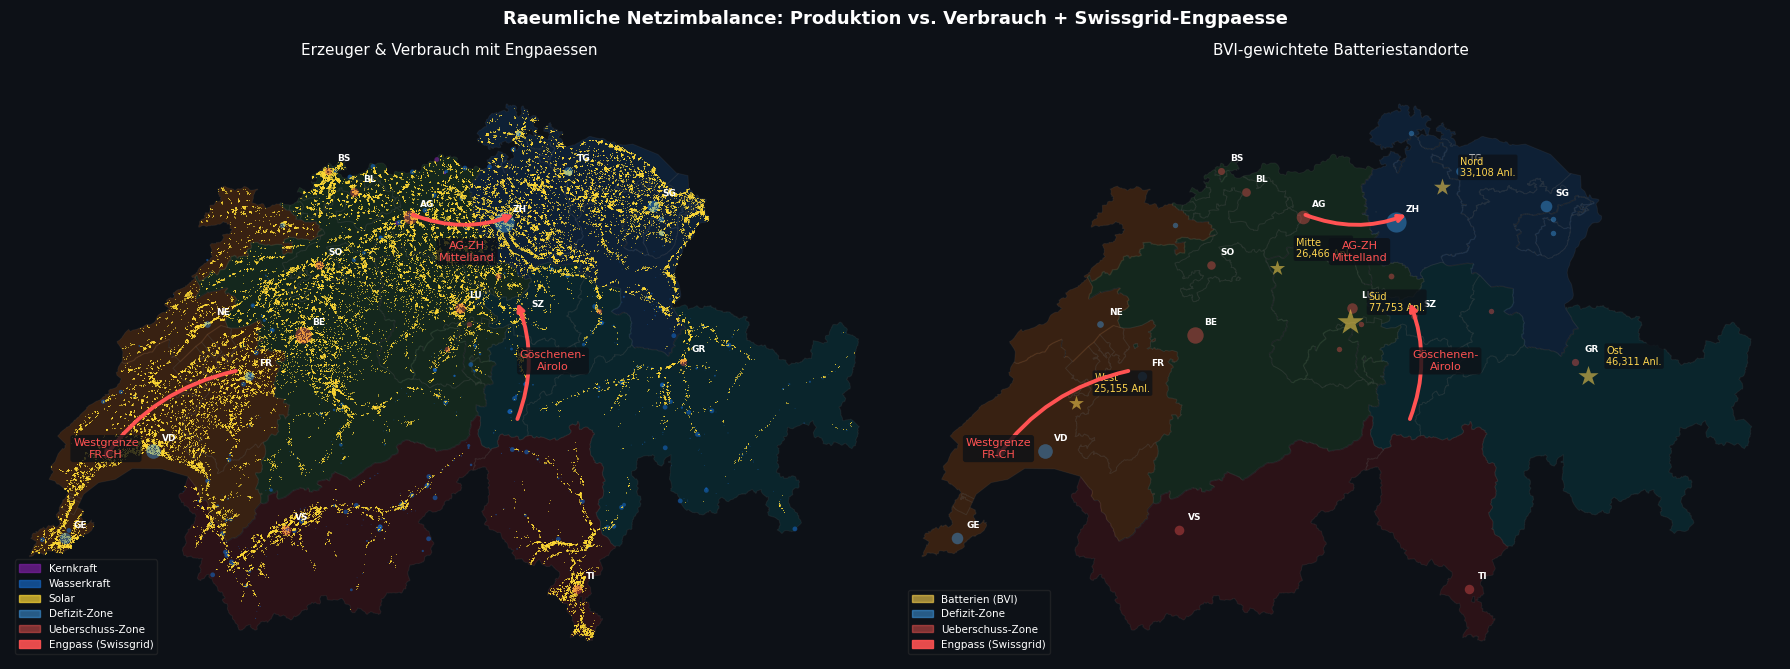

Karte 3 gespeichert: ../output\charts\realistisch\kuer_k01_karte_engpaesse.png
Solar Kombi: 80,000 Punkte (50% von 160,000)


In [28]:
# ── 5.3 Karte: Kombiniert + Engpässe ─────────────────────────────────────────
# ── Parameter (aus 5.2 übernommen, Solar reduziert damit Verbrauch dominiert) ─
SOLAR_ANTEIL_KOMBI  = 0.50   # Anteil Solar-Stichprobe relativ zu 5.2 (0.0–1.0)
_solar_n_kombi = max(500, int(SOLAR_MAX_PUNKTE * SOLAR_ANTEIL_KOMBI))
# ──────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Raeumliche Netzimbalance: Produktion vs. Verbrauch + Swissgrid-Engpaesse',
             color='white', fontsize=FS_TITEL, fontweight='bold')

for ax, show_batteries in zip(axes, [False, True]):
    title = ('Erzeuger & Verbrauch mit Engpaessen' if not show_batteries
             else 'BVI-gewichtete Batteriestandorte')
    draw_base_map(ax, alpha=0.18, title=title)

    if not show_batteries:
        for et in ['Kernkraft', 'Wasserkraft', 'Solar']:
            sub = gdf_plants[gdf_plants['ET_group'] == et]
            if len(sub) == 0: continue
            col = ET_COLORS.get(et, '#9E9E9E')

            if et == 'Solar' and len(sub) > _solar_n_kombi:
                sub   = sub.sample(_solar_n_kombi, random_state=42)
                sizes = PUNKT_GROESSE_SOLAR
                label = f'Solar (sample {_solar_n_kombi:,})'
            else:
                label = et
                if 'kw' in sub.columns and sub['kw'].max() > 0:
                    kw   = sub['kw'].to_numpy(dtype=float)
                    p95  = max(float(np.percentile(kw, 95)), 1.0)
                    sizes = np.clip(kw / p95 * PUNKT_GROESSE_MAX,
                                    PUNKT_GROESSE_MIN, PUNKT_GROESSE_MAX)
                else:
                    sizes = PUNKT_GROESSE_MIN

            xy = np.column_stack([sub.geometry.x.to_numpy(), sub.geometry.y.to_numpy()])
            ax.scatter(xy[:, 0], xy[:, 1], s=sizes, c=col,
                       alpha=0.6, label=label, linewidths=0, zorder=3, rasterized=True)

    for kanton, (lon, lat) in KANTONSHAUPTORTE.items():
        pop  = KANTON_POP.get(kanton, 0) / 1_000_000
        zone = KANTON_TO_ZONE.get(kanton, 'Mitte')
        imb  = df_zones[df_zones['Zone'] == zone]['Imbalance_MW'].values[0]
        c_pop = C_PRIV if imb < 0 else C_UTIL
        ms    = max(15, min(350, pop * 130))
        ax.scatter(lon, lat, s=ms, color=c_pop, alpha=0.40, zorder=4, linewidths=0)
        if pop > 0.15:
            ax.text(lon+0.05, lat+0.03, kanton,
                    color='white', fontsize=6.5, va='bottom', zorder=5, fontweight='bold')

    if show_batteries:
        sc_bat = df_spatial[df_spatial['Szenario'] == 'Ambitioniert (2030)']
        zone_positions = {
            'Nord':(8.80,47.50), 'Mitte':(7.90,47.20),
            'West':(6.80,46.70), 'Sued': (7.80,46.20), 'Ost':(9.60,46.80),
        }
        for _, row in sc_bat.iterrows():
            lon, lat = zone_positions.get(row['Zone'], (8.3, 47.0))
            total_units = row['n_privat'] + row['n_gewerbe'] + row['n_industrie']
            if total_units == 0: continue
            ms  = max(30, min(600, total_units / 200))
            ax.scatter(lon, lat, s=ms, color='#FFD54F', alpha=0.55,
                       marker='*', zorder=6, linewidths=0)
            lbl = row['Zone'] + '\n' + f'{total_units:,}' + ' Anl.'
            ax.text(lon+0.10, lat+0.04, lbl, color='#FFD54F', fontsize=FS_KLEIN, zorder=7,
                    bbox=dict(boxstyle='round,pad=0.2', fc=BG_DARK, alpha=0.75, lw=0))

    for lon1, lat1, lon2, lat2, label, dlon, dlat in ENGPASSLINIEN:
        ax.annotate('', xy=(lon2,lat2), xytext=(lon1,lat1),
                    arrowprops=dict(arrowstyle='->', color='#FF5252', lw=2.8,
                                    connectionstyle='arc3,rad=0.20'), zorder=8)
        ax.text((lon1+lon2)/2+dlon, (lat1+lat2)/2+dlat, label,
                color='#FF5252', fontsize=FS_LEGENDE, ha='center', va='center', zorder=9,
                bbox=dict(boxstyle='round,pad=0.25', fc=BG_DARK, alpha=0.80, lw=0))

    handles = []
    if not show_batteries:
        for et in ['Kernkraft', 'Wasserkraft', 'Solar']:
            handles.append(mpatches.Patch(color=ET_COLORS.get(et, '#9E9E9E'), alpha=0.7, label=et))
    else:
        handles.append(mpatches.Patch(color='#FFD54F', alpha=0.6, label='Batterien (BVI)'))
    handles += [
        mpatches.Patch(color=C_PRIV, alpha=0.5, label='Defizit-Zone'),
        mpatches.Patch(color=C_UTIL, alpha=0.5, label='Ueberschuss-Zone'),
        mpatches.Patch(color='#FF5252', alpha=0.9, label='Engpass (Swissgrid)'),
    ]
    ax.legend(handles=handles, fontsize=7.5, framealpha=0.45,
              facecolor=BG_DARK, labelcolor='white', loc='lower left')

plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'kuer_k01_karte_engpaesse.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
plt.close()
print(f'Karte 3 gespeichert: {p}')
print(f'Solar Kombi: {_solar_n_kombi:,} Punkte ({SOLAR_ANTEIL_KOMBI*100:.0f}% von {SOLAR_MAX_PUNKTE:,})')


### 5.4 Einzelkarten: Räumliche Gegenüberstellung

**Karte A** — Grosse Einzelkarte: Kraftwerke, Verbrauchszentren & Engpässe

**Karte B** — 3-Panel Gegenüberstellung: ① Verbrauch · ② Erzeugung · ③ Netzimbalance+Engpässe

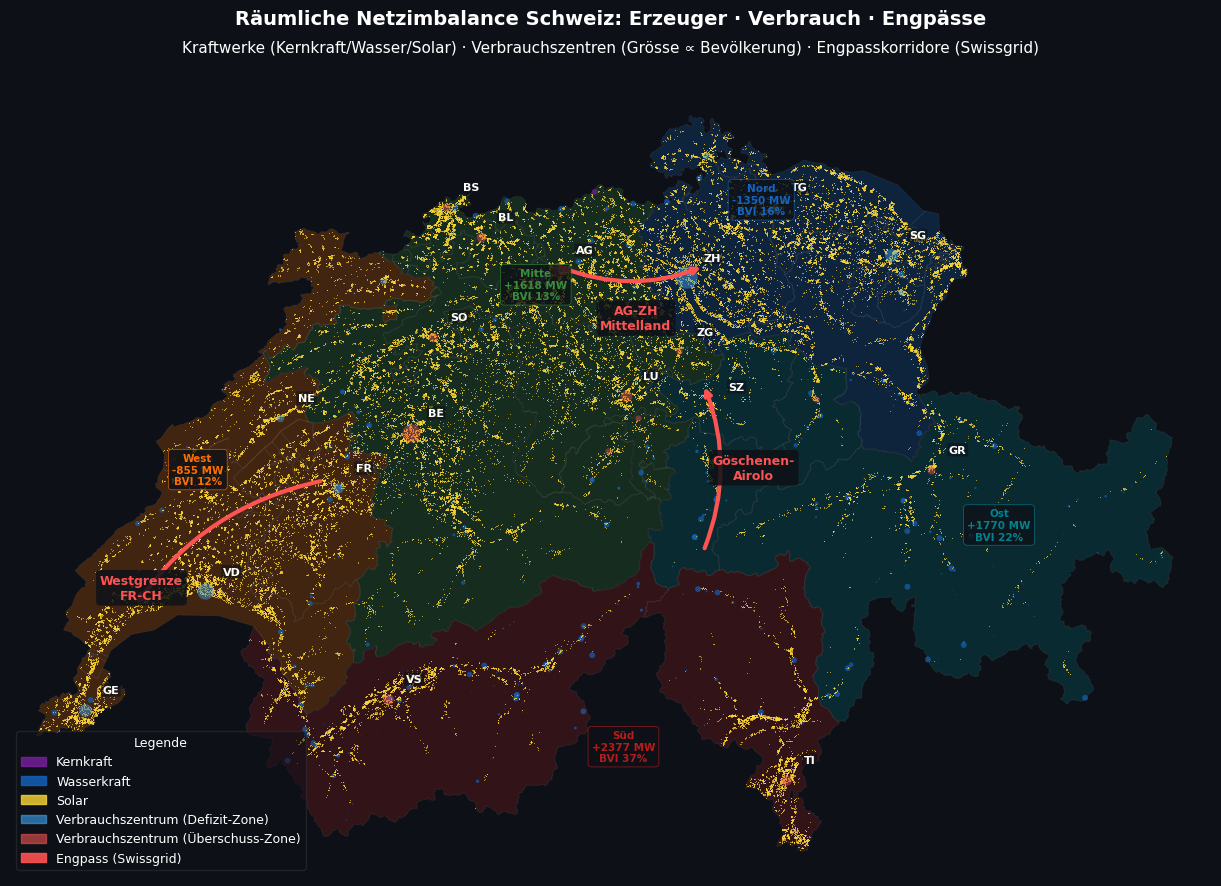

Einzelkarte A gespeichert: ../output\charts\realistisch\kuer_k01_karte_erzeuger_verbrauch_detail.png


In [29]:
# ── Einzelkarte A: Erzeuger, Verbrauchszentren & Engpässe (gross) ─────────────
# Identische Daten wie Cell 40 Panel 1 — grösserer Canvas + Labels für Bericht
fig_ev, ax_ev = plt.subplots(figsize=(14, 9))
fig_ev.patch.set_facecolor(BG_DARK)
fig_ev.suptitle(
    'Räumliche Netzimbalance Schweiz: Erzeuger · Verbrauch · Engpässe',
    color='white', fontsize=14, fontweight='bold', y=0.98)

draw_base_map(ax_ev, alpha=0.22,
    title='Kraftwerke (Kernkraft/Wasser/Solar) · Verbrauchszentren (Grösse ∝ Bevölkerung) · Engpasskorridore (Swissgrid)')

# ── Erzeuger-Punkte (identisch Cell 40 Panel 1) ──────────────────────────────
for et in ['Kernkraft', 'Wasserkraft', 'Solar']:
    sub = gdf_plants[gdf_plants['ET_group'] == et]
    if len(sub) == 0: continue
    col = ET_COLORS.get(et, '#9E9E9E')
    if et == 'Solar' and len(sub) > _solar_n_kombi:
        sub   = sub.sample(_solar_n_kombi, random_state=42)
        sizes = PUNKT_GROESSE_SOLAR
        lbl   = f'Solar (sample {_solar_n_kombi:,})'
    else:
        lbl = et
        if 'kw' in sub.columns and sub['kw'].max() > 0:
            kw    = sub['kw'].to_numpy(dtype=float)
            p95   = max(float(np.percentile(kw, 95)), 1.0)
            sizes = np.clip(kw / p95 * PUNKT_GROESSE_MAX * 1.5,
                            PUNKT_GROESSE_MIN, PUNKT_GROESSE_MAX * 1.5)
        else:
            sizes = PUNKT_GROESSE_MIN
    xy = np.column_stack([sub.geometry.x.to_numpy(), sub.geometry.y.to_numpy()])
    ax_ev.scatter(xy[:, 0], xy[:, 1], s=sizes, c=col,
                  alpha=0.65, label=lbl, linewidths=0, zorder=3, rasterized=True)

# ── Verbrauchszentren-Blasen ──────────────────────────────────────────────────
for kanton, (lon, lat) in KANTONSHAUPTORTE.items():
    pop  = KANTON_POP.get(kanton, 0) / 1_000_000
    zone = KANTON_TO_ZONE.get(kanton, 'Mitte')
    imb  = df_zones[df_zones['Zone'] == zone]['Imbalance_MW'].values[0]
    c_pop = C_PRIV if imb < 0 else C_UTIL
    ms    = max(20, min(500, pop * 160))
    ax_ev.scatter(lon, lat, s=ms, color=c_pop, alpha=0.45, zorder=4, linewidths=0)
    # Labels für grosse Kantone
    if pop > 0.12:
        ax_ev.text(lon + 0.07, lat + 0.04, kanton,
                   color='white', fontsize=FS_LEGENDE, va='bottom', zorder=5, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.15', fc=BG_DARK, alpha=0.6, lw=0))

# ── Engpasslinien ─────────────────────────────────────────────────────────────
for lon1, lat1, lon2, lat2, label, dlon, dlat in ENGPASSLINIEN:
    ax_ev.annotate('', xy=(lon2, lat2), xytext=(lon1, lat1),
                   arrowprops=dict(arrowstyle='->', color='#FF5252', lw=3.0,
                                   connectionstyle='arc3,rad=0.20'), zorder=8)
    ax_ev.text((lon1 + lon2) / 2 + dlon, (lat1 + lat2) / 2 + dlat, label,
               color='#FF5252', fontsize=FS_TICK, ha='center', va='center', zorder=9,
               fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', fc=BG_DARK, alpha=0.85, lw=0))

# ── Zonen-Labels mit Bottleneck-Beschreibung ──────────────────────────────────
ZONE_LABEL_POS = {
    'Nord': (8.85, 47.58), 'Mitte': (7.95, 47.35),
    'West': (6.60, 46.85), 'Süd':   (8.30, 46.10), 'Ost': (9.80, 46.70),
}
for zone, pos in ZONE_LABEL_POS.items():
    row_z = df_zones[df_zones['Zone'] == zone]
    if row_z.empty: continue
    imb_z = row_z['Imbalance_MW'].values[0]
    bvn   = row_z['BVI_norm'].values[0]
    btl   = ZONE_BOTTLENECK.get(zone, '').split(',')[0]  # nur erste Hälfte
    sign  = '+' if imb_z > 0 else ''
    ax_ev.text(pos[0], pos[1],
               f'{zone}\n{sign}{imb_z:.0f} MW\nBVI {bvn:.0f}%',
               color=ZONE_COLORS[zone], fontsize=7.5, ha='center', va='center',
               zorder=10, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.35', fc=BG_DARK, alpha=0.80, lw=0.5,
                         ec=ZONE_COLORS[zone]))

# ── Legende ───────────────────────────────────────────────────────────────────
handles_ev = []
for et in ['Kernkraft', 'Wasserkraft', 'Solar']:
    handles_ev.append(mpatches.Patch(color=ET_COLORS[et], alpha=0.8, label=et))
handles_ev += [
    mpatches.Patch(color=C_PRIV, alpha=0.6,
                   label='Verbrauchszentrum (Defizit-Zone)'),
    mpatches.Patch(color=C_UTIL, alpha=0.6,
                   label='Verbrauchszentrum (Überschuss-Zone)'),
    mpatches.Patch(color='#FF5252', alpha=0.9, label='Engpass (Swissgrid)'),
]
ax_ev.legend(handles=handles_ev, fontsize=FS_TICK, framealpha=0.5,
             facecolor=BG_DARK, labelcolor='white', loc='lower left',
             title='Legende', title_fontsize=9)

plt.tight_layout()
p_ev = os.path.join(CHARTS_DIR, 'kuer_k01_karte_erzeuger_verbrauch_detail.png')
plt.savefig(p_ev, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show(); plt.close()
print(f'Einzelkarte A gespeichert: {p_ev}')



**Einzelkarte B:** 3-Panel Gegenüberstellung — Verbrauchszentren | Erzeuger | Kombiniert.
Berichtstauglich als grossformatiger Überblick über alle räumlichen Dimensionen.


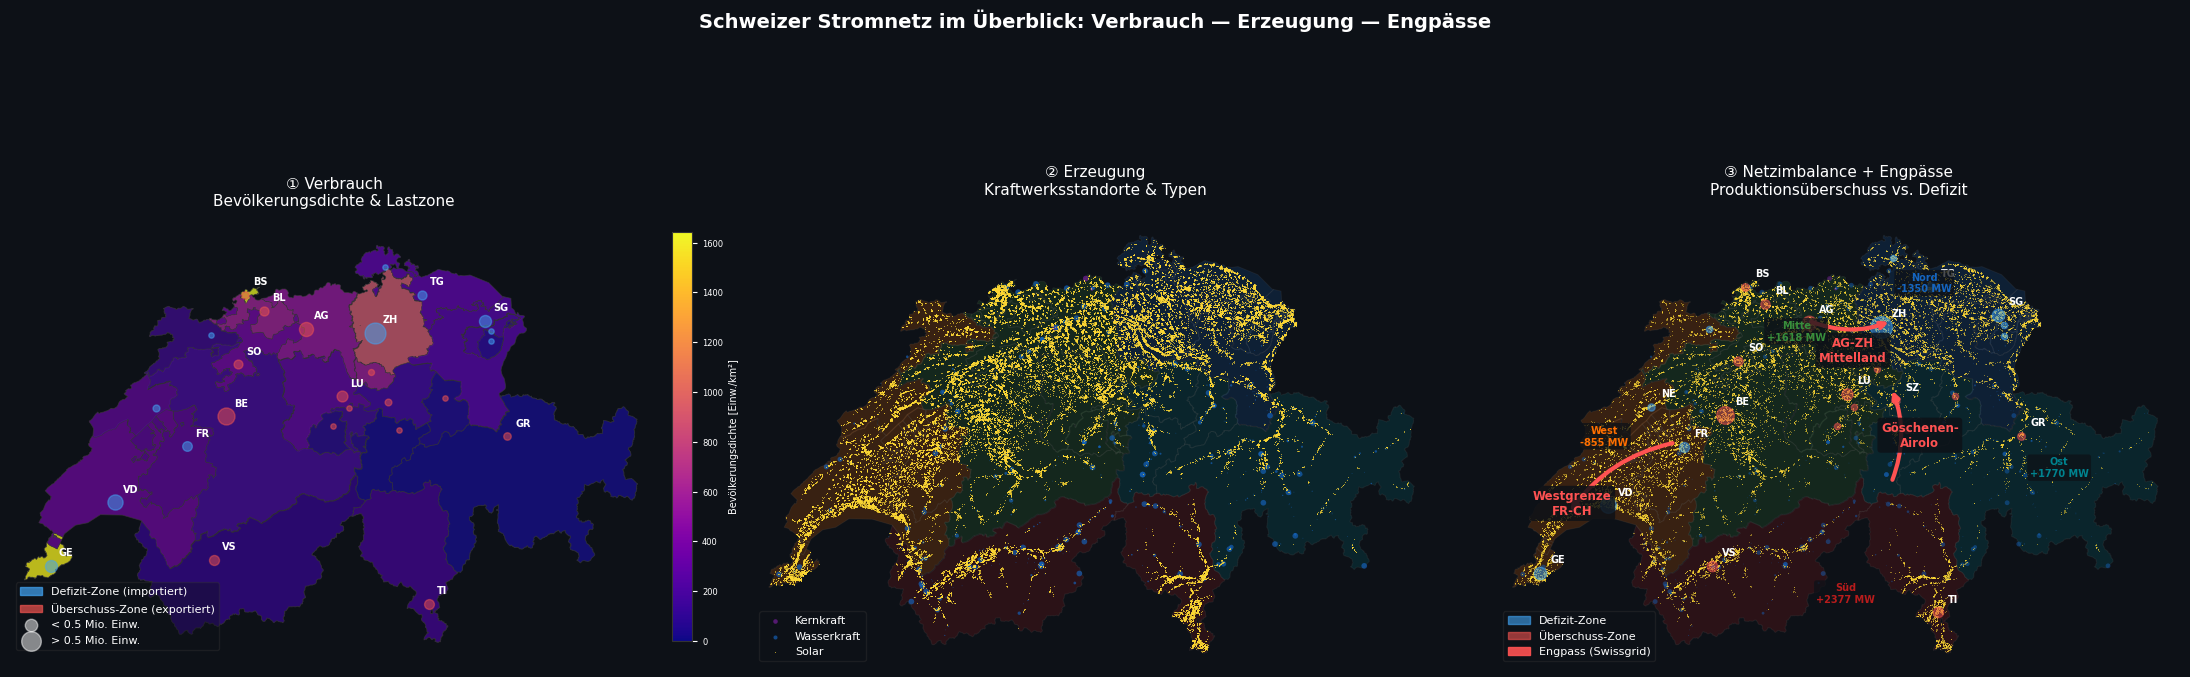

Einzelkarte B (3-Panel) gespeichert: ../output\charts\realistisch\kuer_k01_karte_gegenueberstellung.png


In [30]:
# ── Einzelkarte B: 3-Panel Gegenüberstellung — Verbrauch | Erzeuger | Kombination
# Kernbotschaft: Wo wird Strom verbraucht vs. produziert — und wo klemmt es?
fig_gg, axes_gg = plt.subplots(1, 3, figsize=(22, 8))
fig_gg.patch.set_facecolor(BG_DARK)
fig_gg.suptitle(
    'Schweizer Stromnetz im Überblick: Verbrauch — Erzeugung — Engpässe',
    color='white', fontsize=14, fontweight='bold', y=1.01)

# ── Panel 1: Verbrauchszentren (Bevölkerungsdichte) ───────────────────────────
ax1 = axes_gg[0]
draw_base_map(ax1, alpha=0.20, title='① Verbrauch\nBevölkerungsdichte & Lastzone')

if gdf_kant is not None and 'Dichte' in gdf_kant.columns:
    from matplotlib.colors import Normalize as _Norm
    norm_d = _Norm(vmin=0, vmax=gdf_kant['Dichte'].quantile(0.95))
    cmap_d = plt.cm.get_cmap('plasma')
    for _, row in gdf_kant.iterrows():
        col = cmap_d(norm_d(row['Dichte']))
        try:
            import geopandas as _gpd
            _gpd.GeoDataFrame(geometry=[row.geometry], crs='EPSG:4326').plot(
                ax=ax1, color=col, alpha=0.70, linewidth=0.5, edgecolor=C_SPINE)
        except Exception:
            pass

for kanton, (lon, lat) in KANTONSHAUPTORTE.items():
    pop  = KANTON_POP.get(kanton, 0) / 1_000_000
    zone = KANTON_TO_ZONE.get(kanton, 'Mitte')
    imb  = df_zones[df_zones['Zone'] == zone]['Imbalance_MW'].values[0]
    c_p  = C_PRIV if imb < 0 else C_UTIL
    ms   = max(15, min(400, pop * 140))
    ax1.scatter(lon, lat, s=ms, color=c_p, alpha=0.50, zorder=5)
    if pop > 0.20:
        ax1.text(lon+0.06, lat+0.04, kanton, color='white', fontsize=FS_KLEIN,
                 va='bottom', zorder=6, fontweight='bold')

# Legende Panel 1
handles_p1 = [
    mpatches.Patch(color=C_PRIV, alpha=0.7, label='Defizit-Zone (importiert)'),
    mpatches.Patch(color=C_UTIL, alpha=0.7, label='Überschuss-Zone (exportiert)'),
    plt.scatter([], [], s=80,  color='white', alpha=0.5, label='< 0.5 Mio. Einw.'),
    plt.scatter([], [], s=200, color='white', alpha=0.5, label='> 0.5 Mio. Einw.'),
]
ax1.legend(handles=handles_p1, fontsize=FS_LEGENDE, framealpha=0.4,
           facecolor=BG_DARK, labelcolor='white', loc='lower left')

# Colorbar für Bevölkerungsdichte (plasma: dunkel=wenig, gelb=viel)
_sm1 = plt.cm.ScalarMappable(cmap=cmap_d, norm=norm_d)
_sm1.set_array([])
_cb1 = fig_gg.colorbar(_sm1, ax=ax1, fraction=0.03, pad=0.02, shrink=0.6)
_cb1.set_label('Bevölkerungsdichte [Einw./km²]', color='white', fontsize=FS_KLEIN)
_cb1.ax.yaxis.set_tick_params(color='white', labelsize=FS_KLEIN - 1)
plt.setp(_cb1.ax.yaxis.get_ticklabels(), color='white')
_cb1.outline.set_edgecolor(C_SPINE)

# ── Panel 2: Erzeuger ─────────────────────────────────────────────────────────
ax2 = axes_gg[1]
draw_base_map(ax2, alpha=0.18, title='② Erzeugung\nKraftwerksstandorte & Typen')

for et in ['Kernkraft', 'Wasserkraft', 'Solar']:
    sub = gdf_plants[gdf_plants['ET_group'] == et]
    if len(sub) == 0: continue
    col = ET_COLORS.get(et, '#9E9E9E')
    if et == 'Solar' and len(sub) > _solar_n_kombi:
        sub   = sub.sample(_solar_n_kombi, random_state=42)
        sizes = PUNKT_GROESSE_SOLAR
    else:
        if 'kw' in sub.columns and sub['kw'].max() > 0:
            kw    = sub['kw'].to_numpy(dtype=float)
            p95   = max(float(np.percentile(kw, 95)), 1.0)
            sizes = np.clip(kw / p95 * PUNKT_GROESSE_MAX * 1.4,
                            PUNKT_GROESSE_MIN, PUNKT_GROESSE_MAX * 1.4)
        else:
            sizes = PUNKT_GROESSE_MIN
    xy = np.column_stack([sub.geometry.x.to_numpy(), sub.geometry.y.to_numpy()])
    ax2.scatter(xy[:, 0], xy[:, 1], s=sizes, c=col, alpha=0.65,
                label=et, linewidths=0, zorder=3, rasterized=True)

ax2.legend(fontsize=FS_LEGENDE, framealpha=0.4, facecolor=BG_DARK,
           labelcolor='white', loc='lower left')

# ── Panel 3: Kombination + Engpässe (aus Cell 40 Panel 1) ────────────────────
ax3 = axes_gg[2]
draw_base_map(ax3, alpha=0.18, title='③ Netzimbalance + Engpässe\nProduktionsüberschuss vs. Defizit')

# Erzeuger (reduziert für Lesbarkeit)
_solar_gg = max(300, _solar_n_kombi // 2)
for et in ['Kernkraft', 'Wasserkraft', 'Solar']:
    sub = gdf_plants[gdf_plants['ET_group'] == et]
    if len(sub) == 0: continue
    col = ET_COLORS.get(et, '#9E9E9E')
    if et == 'Solar' and len(sub) > _solar_gg:
        sub = sub.sample(_solar_gg, random_state=42); sizes = PUNKT_GROESSE_SOLAR
    else:
        if 'kw' in sub.columns and sub['kw'].max() > 0:
            kw = sub['kw'].to_numpy(dtype=float)
            sizes = np.clip(kw / max(float(np.percentile(kw, 95)), 1.0) * PUNKT_GROESSE_MAX,
                            PUNKT_GROESSE_MIN, PUNKT_GROESSE_MAX)
        else:
            sizes = PUNKT_GROESSE_MIN
    xy = np.column_stack([sub.geometry.x.to_numpy(), sub.geometry.y.to_numpy()])
    ax3.scatter(xy[:, 0], xy[:, 1], s=sizes, c=col, alpha=0.45,
                linewidths=0, zorder=3, rasterized=True)

# Verbrauchsblasen
for kanton, (lon, lat) in KANTONSHAUPTORTE.items():
    pop  = KANTON_POP.get(kanton, 0) / 1_000_000
    zone = KANTON_TO_ZONE.get(kanton, 'Mitte')
    imb  = df_zones[df_zones['Zone'] == zone]['Imbalance_MW'].values[0]
    c_p  = C_PRIV if imb < 0 else C_UTIL
    ms   = max(20, min(450, pop * 150))
    ax3.scatter(lon, lat, s=ms, color=c_p, alpha=0.50, zorder=4)
    if pop > 0.14:
        ax3.text(lon+0.07, lat+0.04, kanton, color='white', fontsize=FS_KLEIN,
                 va='bottom', zorder=5, fontweight='bold')

# Engpasslinien
for lon1, lat1, lon2, lat2, label, dlon, dlat in ENGPASSLINIEN:
    ax3.annotate('', xy=(lon2, lat2), xytext=(lon1, lat1),
                 arrowprops=dict(arrowstyle='->', color='#FF5252', lw=3.0,
                                 connectionstyle='arc3,rad=0.20'), zorder=8)
    ax3.text((lon1+lon2)/2+dlon, (lat1+lat2)/2+dlat, label,
             color='#FF5252', fontsize=8.5, ha='center', va='center', zorder=9,
             fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', fc=BG_DARK, alpha=0.85, lw=0))

# Zonen-Labels
for zone, pos in {'Nord':(8.85,47.58),'Mitte':(7.95,47.35),
                  'West':(6.60,46.85),'Süd':(8.30,46.10),'Ost':(9.80,46.70)}.items():
    row_z = df_zones[df_zones['Zone'] == zone]
    if row_z.empty: continue
    imb_z = row_z['Imbalance_MW'].values[0]
    sign  = '+' if imb_z > 0 else ''
    ax3.text(pos[0], pos[1], f'{zone}\n{sign}{imb_z:.0f} MW',
             color=ZONE_COLORS[zone], fontsize=FS_KLEIN, ha='center', va='center', zorder=10,
             fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.25', fc=BG_DARK, alpha=0.75, lw=0))

handles_gg = [
    mpatches.Patch(color=C_PRIV, alpha=0.6, label='Defizit-Zone'),
    mpatches.Patch(color=C_UTIL, alpha=0.6, label='Überschuss-Zone'),
    mpatches.Patch(color='#FF5252', alpha=0.9, label='Engpass (Swissgrid)'),
]
ax3.legend(handles=handles_gg, fontsize=FS_LEGENDE, framealpha=0.4,
           facecolor=BG_DARK, labelcolor='white', loc='lower left')

plt.tight_layout()
p_gg = os.path.join(CHARTS_DIR, 'kuer_k01_karte_gegenueberstellung.png')
plt.savefig(p_gg, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show(); plt.close()
print(f'Einzelkarte B (3-Panel) gespeichert: {p_gg}')


**Karte 3 — Kombiniert.** Links: Erzeuger + Zonen-Einfärbung (Nord=Blau, Mitte=Grün, West=Amber, Süd=Rot, Ost=Teal) + Swissgrid-Engpässe. Rechts: [BVI](../organisation/O_02_Glossar.ipynb#g-bvi)-gewichtete Batteriestandorte.

---
## 6. Tages- und Lastprofile<a id='tages-und-lastprofile_K_01'></a>

[↑ Inhaltsverzeichnis](#toc_K_01)

Zeitliche Analyse: Wann produziert welche Zone wie viel, und wann wird am meisten verbraucht? Diese Visualisierungen ergänzen die räumliche Sichtweise (Abschnitt 5) um die Zeitdimension.

---
### 6.1 Heatmap: Tages-Lastprofil pro Zone<a id='heatmap-tages-lastprofil-pro-zone_K_01'></a>

[↑ Inhaltsverzeichnis](#toc_K_01)

*Zeigt wann welche Zone produziert und verbraucht — als Stunden×Energieträger-Matrix.*
Zonale Kapazitätsfaktoren ergeben ein Lastprofil pro Stunde, das die [Dispatch](../organisation/O_02_Glossar.ipynb#g-dispatch)-Logik räumlich verankert.


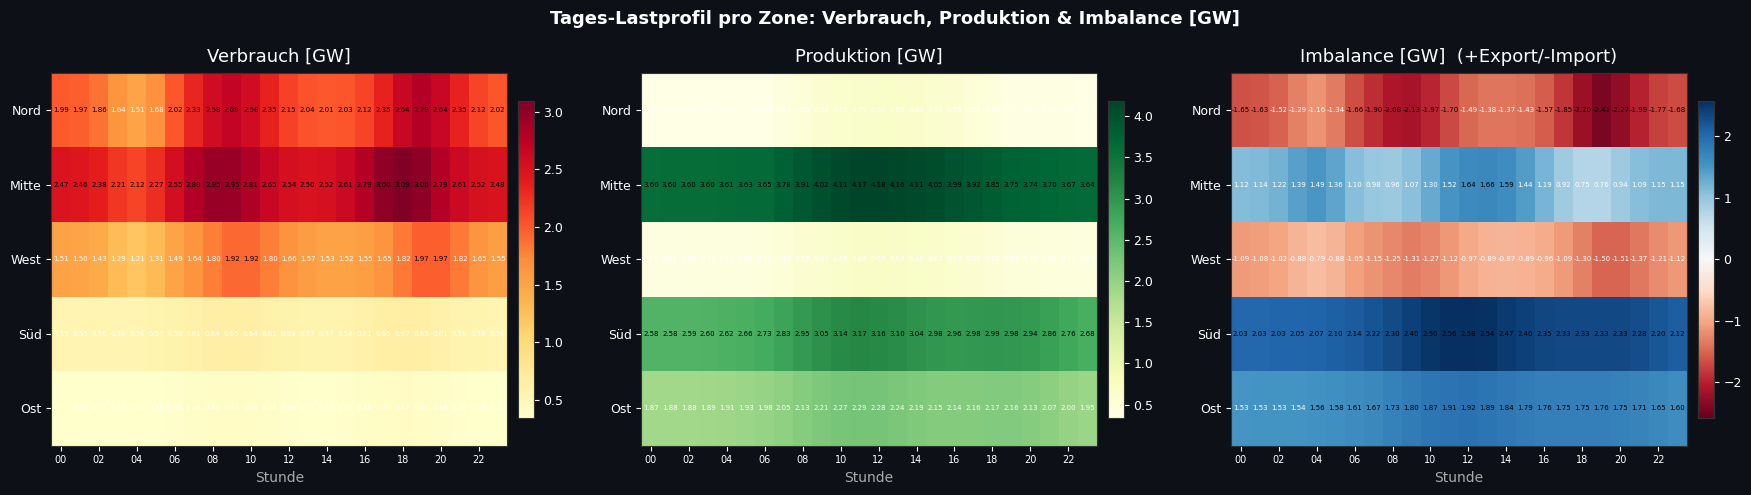

Heatmap 1 gespeichert: ../output\charts\realistisch\kuer_k01_heatmap_lastprofil.png


In [31]:
# ── 5.4 Heatmap: Tages-Lastprofil pro Zone ───────────────────────────────────

hours = np.arange(24)
ZONE_LOAD_PROFILE = {}
ZONE_PROD_PROFILE = {}

for zone in ZONE_COLORS:
    row_z    = df_zones[df_zones['Zone'] == zone].iloc[0]
    base_mw  = float(row_z['Verbrauch_MW'])   # bereits in MW (nach Cell-10-Fix)
    prod_mw  = float(row_z['Produktion_MW'])
    base_gw  = base_mw / 1000
    prod_gw  = prod_mw / 1000

    if zone == 'Nord':
        profile = (1.0 + 0.35*np.exp(-((hours-9)**2)/6)
                       + 0.40*np.exp(-((hours-19)**2)/5)
                       - 0.25*np.exp(-((hours-4)**2)/3))
    elif zone == 'Mitte':
        profile = (1.0 + 0.20*np.exp(-((hours-8.5)**2)/6)
                       + 0.25*np.exp(-((hours-18)**2)/6)
                       - 0.15*np.exp(-((hours-4)**2)/3))
    elif zone == 'West':
        profile = (1.0 + 0.28*np.exp(-((hours-9.5)**2)/6)
                       + 0.32*np.exp(-((hours-19.5)**2)/5)
                       - 0.20*np.exp(-((hours-4)**2)/3))
    elif zone == 'Sued':
        profile = (1.0 + 0.15*np.exp(-((hours-10)**2)/8)
                       + 0.18*np.exp(-((hours-18)**2)/6))
    else:
        profile = (1.0 + 0.18*np.exp(-((hours-9)**2)/7)
                       + 0.20*np.exp(-((hours-18)**2)/6))

    ZONE_LOAD_PROFILE[zone] = base_gw * profile

    # Produktion stündlich aufschlüsseln nach ET-Anteilen
    # Wichtig: solar_frac = Anteil Solar an der MITTLEREN (CF-korrigierten) Produktion
    # NICHT installierte Kapazität / CF-Prod (wäre > 1 bei Solar-dominierter Zone)

    CF_SOLAR = 0.12  # Kapazitätsfaktor Solar CH
    CF_KERN  = 0.80  # Kernkraft läuft konstant (Baseload)
    CF_HYDRO = 0.38

    def zone_mean_mw(et, cf):
        return gdf_plants[(gdf_plants['Zone']==zone) &
                          (gdf_plants['ET_group']==et)]['kw'].sum() / 1000 * cf

    solar_mean = zone_mean_mw('Solar',      CF_SOLAR)
    kern_mean  = zone_mean_mw('Kernkraft',  CF_KERN)
    hydro_mean = zone_mean_mw('Wasserkraft',CF_HYDRO)
    other_mean = max(prod_mw - solar_mean - kern_mean - hydro_mean, 0)

    # Solar: sinusförmiges Tagesprofil (0 nachts)
    solar_profile = np.maximum(0, np.sin(np.pi * (hours - 6) / 13))
    solar_profile = solar_profile / (solar_profile.max() + 1e-9)

    # Kernkraft: konstant (Baseload, unabhängig von Tageszeit)
    kern_profile = np.ones(24)

    # Wasserkraft: leicht erhöht tagsüber (Pumpspeicher-Dispatch)
    hydro_profile = (1.0 + 0.20*np.exp(-((hours-11)**2)/20)
                        + 0.15*np.exp(-((hours-19)**2)/12))

    ZONE_PROD_PROFILE[zone] = (
        solar_mean * solar_profile +
        kern_mean  * kern_profile  +
        hydro_mean * (hydro_profile / hydro_profile.mean()) +
        other_mean * np.ones(24)
    ) / 1000  # MW → GW

zones       = list(ZONE_COLORS.keys())
load_matrix = np.array([ZONE_LOAD_PROFILE[z] for z in zones])
prod_matrix = np.array([ZONE_PROD_PROFILE[z] for z in zones])
imb_matrix  = prod_matrix - load_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(BG_DARK)
for ax in axes:
    ax.set_facecolor(BG_PANEL); ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_edgecolor(C_SPINE)
fig.suptitle('Tages-Lastprofil pro Zone: Verbrauch, Produktion & Imbalance [GW]',
             color='white', fontsize=FS_TITEL, fontweight='bold')

hour_labels = [f'{h:02d}' for h in hours[::2]]

for ax, matrix, title, cmap_name in zip(axes,
        [load_matrix, prod_matrix, imb_matrix],
        ['Verbrauch [GW]', 'Produktion [GW]', 'Imbalance [GW]  (+Export/-Import)'],
        ['YlOrRd', 'YlGn', 'RdBu']):
    kw = {}
    if cmap_name == 'RdBu':
        abs_max = np.abs(matrix).max()
        kw = dict(vmin=-abs_max, vmax=abs_max)
    im = ax.imshow(matrix, aspect='auto', cmap=cmap_name, origin='upper', **kw)
    cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
    cbar.ax.tick_params(colors='white')
    ax.set_xticks(hours[::2]); ax.set_xticklabels(hour_labels, fontsize=FS_KLEIN, color='white')
    ax.set_yticks(range(len(zones))); ax.set_yticklabels(zones, fontsize=FS_TICK, color='white')
    ax.set_title(title, color='white', pad=8)
    ax.set_xlabel('Stunde', color=C_ACHSE)
    for i in range(len(zones)):
        for j in range(24):
            val = matrix[i, j]
            col = 'white' if abs(val) < np.abs(matrix).max()*0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    color=col, fontsize=5)

plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'kuer_k01_heatmap_lastprofil.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
plt.close()
print(f'Heatmap 1 gespeichert: {p}')


**Heatmap Tages-Lastprofil.** Kernkraft = konstant, Solar = sinusförmig, Wasser = leicht erhöht tagsüber. Korrekte Aufschlüsselung nach ET verhindert das 'verschwinden' des AKW-Anteils nachts.

---
### 6.2 Heatmap: Produktions-Mix Stunde × Energieträger

*Zeigt wann welcher Energieträger wie viel produziert — Solar tagsüber, Wasser steuerbar.*


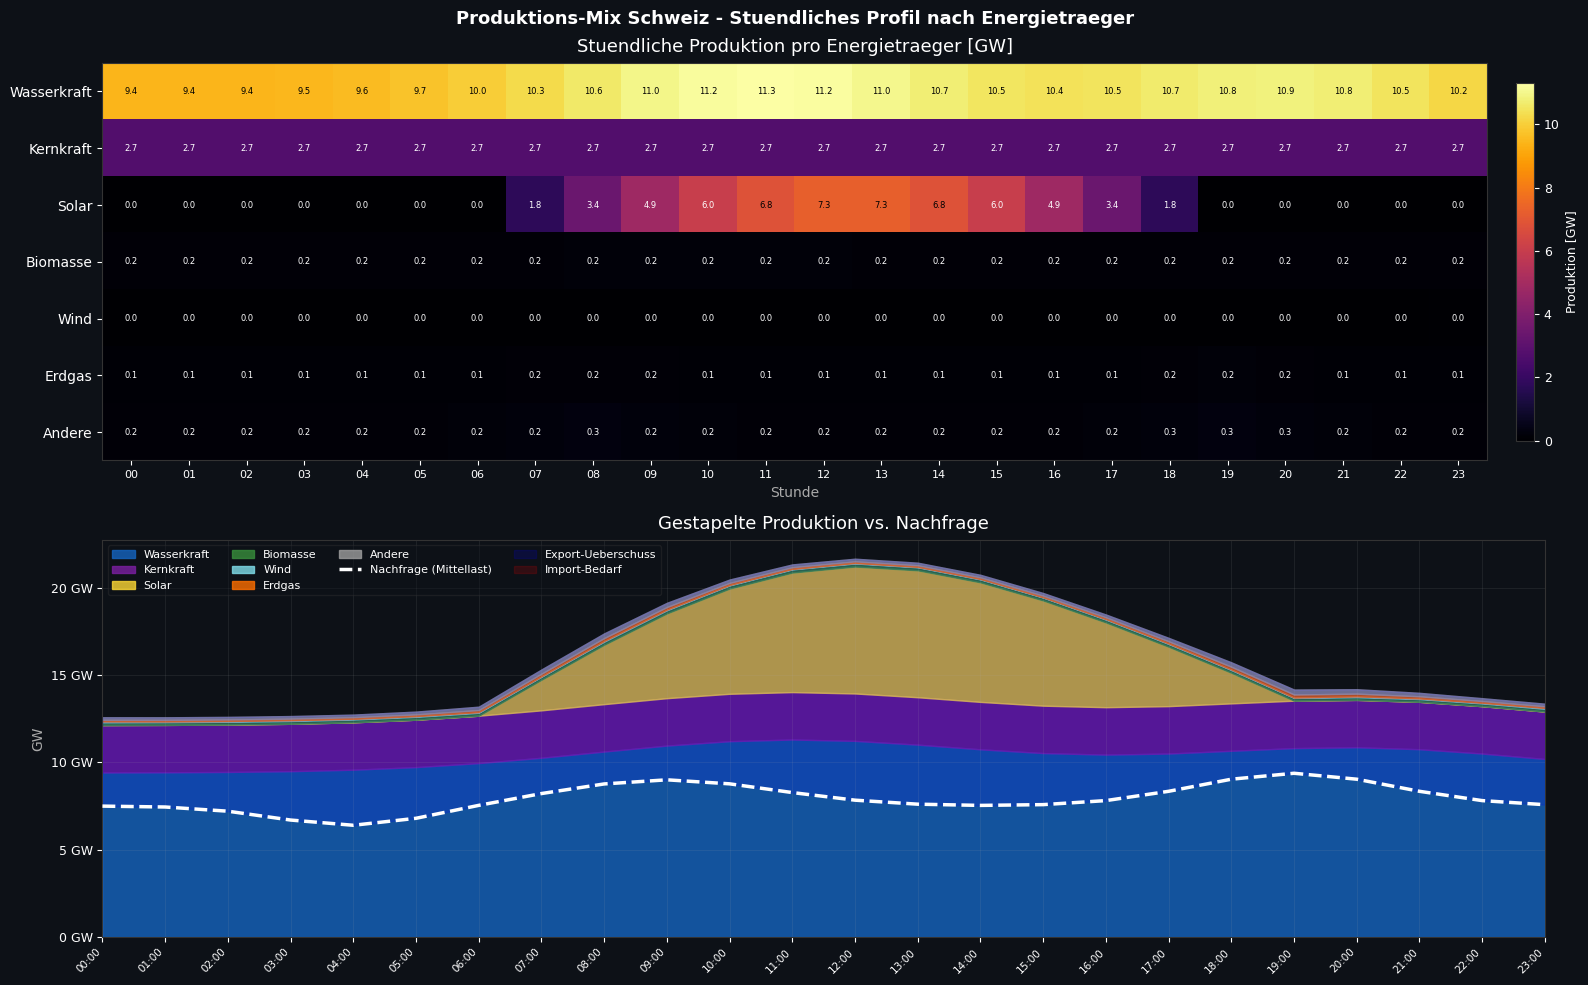

Heatmap 2 gespeichert: ../output\charts\realistisch\kuer_k01_heatmap_produktionsmix.png


In [32]:
# ── 5.5 Heatmap: Produktions-Mix Stunde x Energietraeger ────────────────────

hours = np.arange(24)

et_installed = {}
if 'ET_group' in gdf_plants.columns and 'kw' in gdf_plants.columns:
    et_installed = (gdf_plants.groupby('ET_group')['kw'].sum() / 1e6).to_dict()

ET_DEFAULTS_GW = {
    'Wasserkraft':16.0,'Kernkraft':3.0,'Solar':8.5,
    'Biomasse':0.8,'Wind':0.1,'Erdgas':0.9,'Andere':0.5
}

et_profiles = {}
for et, def_gw in ET_DEFAULTS_GW.items():
    inst = et_installed.get(et, def_gw)  # et_installed bereits in GW (kW/1e6)
    if et == 'Solar':
        p = np.maximum(0, np.sin(np.pi * (hours - 6) / 13))
        p = p / (p.max() + 1e-9) * inst * 0.85
    elif et == 'Wasserkraft':
        p = inst * 0.55 * (1 + 0.20*np.exp(-((hours-11)**2)/20)
                              + 0.15*np.exp(-((hours-20)**2)/15))
    elif et == 'Kernkraft':
        p = np.full(24, inst * 0.90)
    elif et == 'Wind':
        np.random.seed(7)
        p = inst * 0.25 * (1 + 0.3*np.cos((hours-2)*np.pi/12) +
                            0.2*np.random.randn(24))
        p = np.clip(p, 0, inst)
    elif et == 'Biomasse':
        p = inst * 0.65 * (1 + 0.15*np.exp(-((hours-10)**2)/20))
    else:
        p = inst * 0.30 * (1 + 0.8*np.exp(-((hours-8)**2)/4)
                              + 0.9*np.exp(-((hours-19)**2)/4))
        p = np.clip(p, 0, inst)
    et_profiles[et] = p

et_list    = list(ET_DEFAULTS_GW.keys())
matrix     = np.array([et_profiles[et] for et in et_list])
total_prod = matrix.sum(axis=0)

base_load    = 7.5
load_profile = base_load * (1 + 0.20*np.exp(-((hours-9)**2)/6)
                               + 0.25*np.exp(-((hours-19)**2)/5)
                               - 0.15*np.exp(-((hours-4)**2)/3))

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.patch.set_facecolor(BG_DARK)
for ax in axes:
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_edgecolor(C_SPINE)
fig.suptitle('Produktions-Mix Schweiz - Stuendliches Profil nach Energietraeger',
             color='white', fontsize=FS_TITEL, fontweight='bold')

ax = axes[0]
ax.set_facecolor(BG_PANEL)
im = ax.imshow(matrix, aspect='auto', cmap='inferno', origin='upper')
cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02, shrink=0.9)
cbar.set_label('Produktion [GW]', color='white', fontsize=FS_TICK)
cbar.ax.tick_params(colors='white')
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}' for h in hours], fontsize=FS_LEGENDE, color='white')
ax.set_yticks(range(len(et_list)))
ax.set_yticklabels(et_list, fontsize=FS_ACHSE, color='white')
ax.set_title('Stuendliche Produktion pro Energietraeger [GW]', color='white', pad=8)
ax.set_xlabel('Stunde', color=C_ACHSE)
for i in range(len(et_list)):
    for j in range(24):
        val = matrix[i, j]
        col = 'white' if val < matrix.max()*0.6 else 'black'
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', color=col, fontsize=6)

ax2 = axes[1]
ax2.set_facecolor(BG_DARK)
bottom = np.zeros(24)
for et in et_list:
    p = et_profiles[et]
    ax2.fill_between(hours, bottom, bottom + p, alpha=0.80,
                     color=ET_COLORS.get(et,'#9E9E9E'), label=et)
    bottom += p

ax2.plot(hours, load_profile, color='white', lw=LW_DICK, linestyle='--',
         label='Nachfrage (Mittellast)', zorder=10)
ax2.fill_between(hours, total_prod, load_profile,
                 where=(total_prod > load_profile), alpha=0.15, color='blue',
                 label='Export-Ueberschuss')
ax2.fill_between(hours, total_prod, load_profile,
                 where=(total_prod < load_profile), alpha=0.15, color='red',
                 label='Import-Bedarf')
ax2.set_xlim(0, 23); ax2.set_ylim(0, None)
ax2.set_xticks(range(24))
ax2.set_xticklabels([f'{h:02d}:00' for h in hours], rotation=45, ha='right', fontsize=7.5)
ax2.set_ylabel('GW', color=C_ACHSE)
ax2.set_title('Gestapelte Produktion vs. Nachfrage', color='white', pad=8)
ax2.tick_params(colors='white')
for sp in ax2.spines.values(): sp.set_edgecolor(C_SPINE)
ax2.legend(fontsize=FS_LEGENDE, framealpha=0.4, facecolor=BG_DARK,
           labelcolor='white', ncol=4, loc='upper left')
ax2.grid(True, alpha=0.10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f} GW'))

plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'kuer_k01_heatmap_produktionsmix.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
plt.close()
print(f'Heatmap 2 gespeichert: {p}')


**Heatmap Produktions-Mix.** Oben: Heatmap ET×Stunde. Unten: Gestapelte Flächen mit Export/Import-Markierung.

---
### 6.3 Animation: Tagesverlauf *(optional)*

Animierter Tagesverlauf: Wie sich Produktion vs. Verbrauch pro Zone über 24h verändert.  
Benötigt `matplotlib` Animation und `Pillow` oder `ffmpeg` für den Export.


**🔎 Quellcode der importierten lib-Funktion**

In [33]:
show_source(make_gif_chart)


<details>
<summary>🔎 Quellcode: <code>make_gif_chart</code> (aus <code>lib/plotting.py</code>)</summary>

```python
def make_gif_chart(fig, update_fn, frames, fps, path,
                   dpi=None, save_frames=None, cfg=None):
    """PIL-basierter GIF-Builder für animierte Charts.

    Für jeden Frame-Wert wird ``update_fn(frame_val)`` aufgerufen, das Figure
    in PNG gerendert und in die Frame-Liste aufgenommen. Am Ende werden die
    Frames als animiertes GIF gespeichert (``loop=0``).

    Parameter
    ---------
    fig : matplotlib.figure.Figure
        Die Figure, die für jeden Frame neu gerendert wird. ``update_fn`` muss
        in-place die Axes-Elemente dieser Figure aktualisieren.
    update_fn : callable
        Funktion ``update_fn(frame_val)``, aktualisiert die dynamischen
        Chart-Elemente für den aktuellen Frame-Wert.
    frames : Iterable
        Sequenz der Frame-Werte (z.B. ``HOUR_TIMES`` für Tagesanimation oder
        ``WEEK_TIMES`` für Jahresanimation).
    fps : int
        Frames pro Sekunde im Output-GIF.
    path : str
        Zieldatei (``.gif``). Bei ``save_frames=True`` werden die Einzelframes
        zusätzlich in ``<path_ohne_ext>_frames/frame_NNNN.png`` gespeichert.
    dpi : int, optional
        DPI beim Rendering. Default: ``cfg['animation']['dpi']`` (wenn cfg
        gegeben), sonst 110.
    save_frames : bool, optional
        Einzelframes zusätzlich als PNG speichern. Default:
        ``cfg['animation']['einzelbilder']`` (wenn cfg gegeben), sonst False.
    cfg : dict, optional
        Geladenes ``sync/config.json``. Wenn gegeben:
          * Skip-Check via :func:`should_skip` (liest ``animation.modus`` und
            ``animation.overrides``)
          * dpi/save_frames-Defaults aus ``animation.dpi`` / ``animation.einzelbilder``

    Return
    ------
    None. Bei ``skip_if_exists`` + existierender Datei: return ohne Rendering.
    """
    import io as _io
    from PIL import Image as _PILImage

    # Skip-Check: wenn cfg gegeben und should_skip True → nichts tun
    if cfg is not None:
        _name = os.path.basename(path).rsplit('.', 1)[0]
        if should_skip(path, 'animation', _name, cfg):
            print(f'⏭️  {_name} übersprungen (existiert)')
            return

    # Defaults aus cfg oder Fallbacks
    if cfg is not None:
        _dpi    = dpi        if dpi        is not None else cfg.get('animation', {}).get('dpi', 110)
        _einzel = save_frames if save_frames is not None else cfg.get('animation', {}).get('einzelbilder', False)
    else:
        _dpi    = dpi        if dpi        is not None else 110
        _einzel = save_frames if save_frames is not None else False

    frame_dir = path.replace('.gif', '_frames')
    if _einzel:
        os.makedirs(frame_dir, exist_ok=True)

    # Frame-Loop
    frames_pil = []
    for i, frame_val in enumerate(frames):
        update_fn(frame_val)
        buf = _io.BytesIO()
        fig.savefig(buf, format='png', dpi=_dpi,
                    bbox_inches='tight', facecolor=fig.get_facecolor())
        buf.seek(0)
        img = _PILImage.open(buf).convert('RGB').copy()
        if _einzel:
            img.save(os.path.join(frame_dir, f'frame_{i:04d}.png'), optimize=True)
        frames_pil.append(img)

    if not frames_pil:
        print('⚠️  Keine Frames')
        return

    frames_pil[0].save(path, save_all=True, append_images=frames_pil[1:],
                       duration=int(1000 / fps), loop=0, optimize=True)
    n  = len(frames_pil)
    kb = os.path.getsize(path) // 1024
    print(f'✅ {os.path.basename(path)} ({n}f @{fps}fps={n/fps:.1f}s | {kb} KB)')
    if _einzel:
        print(f'   Frames: {frame_dir}/')
```

</details>


**🔎 Quellcode der importierten lib-Funktion**

In [34]:
show_source(make_spline_h24)


<details>
<summary>🔎 Quellcode: <code>make_spline_h24</code> (aus <code>lib/plotting.py</code>)</summary>

```python
def make_spline_h24(values_24):
    """Periodischer kubischer Spline für 24h-Stundenwerte.

    Erzeugt einen periodischen Spline aus 24 Stundenwerten (h=0..23). Stetigkeit
    in Wert *und* Ableitung an der Tag-Grenze (`cs(24) == cs(0)`) — geeignet für
    Last-Profile, Solar-/Wasser-Erzeugungsprofile, Mix-Anteile. Wird in K_01
    für Tagesverlaufs-Animationen (typisch 96 Zwischen-Punkte = 4f/h × 24h) und
    in den Heatmap-Plots für glatte Kurven genutzt.

    Parameter
    ---------
    values_24 : array-like, len=24
        24 Stundenwerte. Ein zusätzlicher Wert für h=24 wird intern als Kopie
        von `values_24[0]` ergänzt, damit der Spline schliesst.

    Return
    ------
    scipy.interpolate.CubicSpline
        Aufrufbar mit Stunden-Float: ``cs(12.5)`` → interpolierter Wert für
        12:30 Uhr. Akzeptiert auch Arrays: ``cs(HOUR_TIMES)`` → Array gleicher
        Länge.

    Beispiel
    --------
    >>> import numpy as np
    >>> from lib.plotting import make_spline_h24
    >>> last_24h = [3.5, 3.2, 3.0, 2.9, 2.8, 2.9, 3.4, 4.5, 5.8, 6.2, 6.4, 6.5,
    ...             6.3, 6.0, 5.7, 5.5, 5.6, 6.0, 6.5, 6.8, 6.5, 5.5, 4.5, 3.8]
    >>> cs = make_spline_h24(last_24h)
    >>> cs(12.5)        # Zwischenwert
    >>> cs(np.linspace(0, 24, 96, endpoint=False))  # 96 Punkte
    """
    import numpy as np
    from scipy.interpolate import CubicSpline

    h = np.arange(25)
    v = np.array(list(values_24) + [values_24[0]])
    return CubicSpline(h, v, bc_type='periodic')
```

</details>


▶ Tagesverlauf-Animation: 96f (4f/h × 24h) @10fps=9.6s

✅ kuer_k01_anim_tagesverlauf.gif (96f @10fps=9.6s | 753 KB)
   Frames: ../output\charts\realistisch\kuer_k01_anim_tagesverlauf_frames/


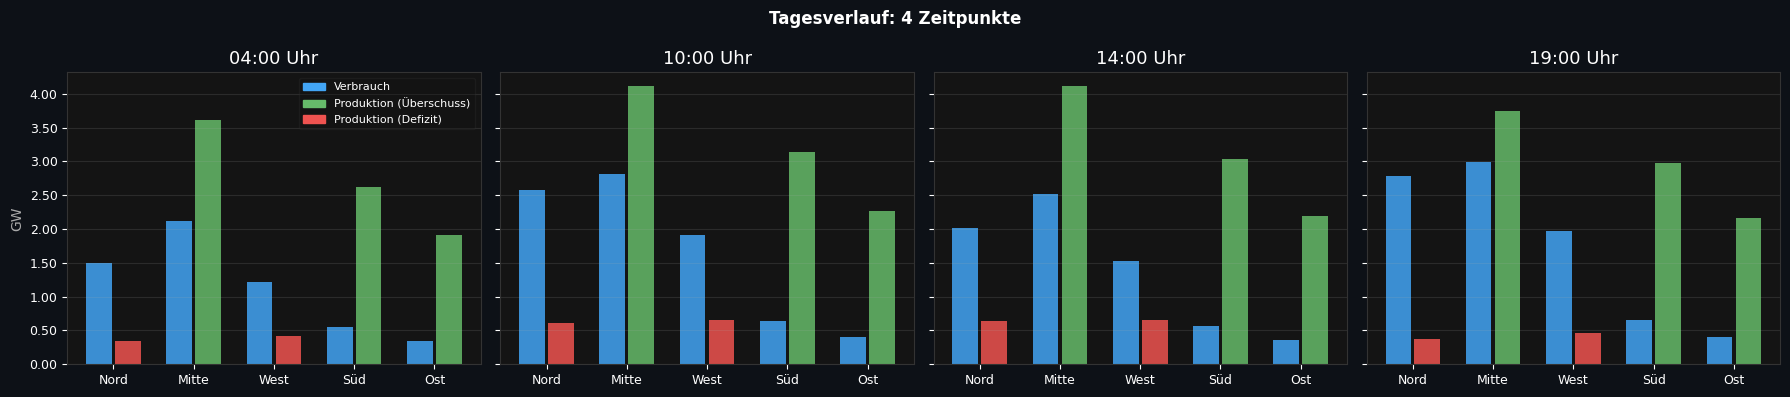

✅ Statisches 4-Stunden-Bild: kuer_k01_anim_4zeitpunkte.png


In [35]:
# ── 5.6 Animation: Tagesverlauf — cubic-interpoliert ─────────────────────────
import numpy as _np_a1, matplotlib.ticker as _mt_a1

zones   = list(ZONE_COLORS.keys())
n_zones = len(zones)

# Splines für Verbrauch und Produktion je Zone
_cs_load_z = {}
_cs_prod_z = {}
for zone in zones:
    _cs_load_z[zone] = make_spline_h24(list(ZONE_LOAD_PROFILE[zone]))
    _cs_prod_z[zone] = make_spline_h24(list(ZONE_PROD_PROFILE[zone]))

# Figure aufbauen
fig_a, ax_a = plt.subplots(figsize=(12, 5))
fig_a.patch.set_facecolor(BG_DARK); ax_a.set_facecolor(BG_PANEL)
for sp in ax_a.spines.values(): sp.set_edgecolor(C_SPINE)
x = _np_a1.arange(n_zones)
bars_load = ax_a.bar(x-0.15, [0]*n_zones, 0.28, label='Verbrauch', color=C_PRIV, alpha=0.85)
bars_prod = ax_a.bar(x+0.15, [0]*n_zones, 0.28, label='Produktion', color=C_LOAD, alpha=0.85)
ax_a.set_xticks(x); ax_a.set_xticklabels(zones, color='white', fontsize=11)
ax_a.tick_params(colors='white'); ax_a.set_ylabel('GW', color=C_ACHSE)
ax_a.set_ylim(0, max(
    max(ZONE_LOAD_PROFILE[z].max() for z in zones),
    max(ZONE_PROD_PROFILE[z].max() for z in zones))*1.25)
# Legende explizit mit 3 Patches — Produktion-Farbe wechselt je Frame (grün↔rot)
_legend_handles = [
    mpatches.Patch(color=C_PRIV, label='Verbrauch'),
    mpatches.Patch(color=C_LOAD, label='Produktion (Überschuss)'),
    mpatches.Patch(color=C_UTIL, label='Produktion (Defizit)'),
]
ax_a.legend(handles=_legend_handles, fontsize=FS_ACHSE,
             framealpha=ALPHA_LEGENDE, facecolor=C_LEGENDE_BG, labelcolor='white')
ax_a.grid(True, axis='y', alpha=0.15)
ax_a.yaxis.set_major_formatter(_mt_a1.FuncFormatter(lambda v,_: f'{v:.1f} GW'))
time_text = ax_a.text(0.5, 0.95, '', transform=ax_a.transAxes,
                       ha='center', color='white', fontsize=FS_TITEL, fontweight='bold')
imb_texts = [ax_a.text(i, 0.05, '', ha='center', va='bottom',
                        color='white', fontsize=FS_LEGENDE, fontweight='bold') for i in x]

def update_k01(t_h):
    '''t_h: interpolierte Stunde (0.0–23.9)'''
    h_disp = int(round(t_h)) % 24
    for i, zone in enumerate(zones):
        load = float(_cs_load_z[zone](t_h))
        prod = float(_cs_prod_z[zone](t_h))
        bars_load[i].set_height(max(0, load))
        bars_prod[i].set_height(max(0, prod))
        imb = prod - load
        bars_prod[i].set_color(C_LOAD if imb >= 0 else C_UTIL)
        imb_texts[i].set_text(f'{imb:+.2f} GW')
        imb_texts[i].set_y(max(load, prod) + 0.02)
        imb_texts[i].set_color(C_LOAD if imb >= 0 else C_UTIL)
    time_text.set_text(f'Tagesverlauf  {h_disp:02d}:00 Uhr  (t={t_h:.1f}h)')

gif_path = os.path.join(CHARTS_DIR, 'kuer_k01_anim_tagesverlauf.gif')
print(f'▶ Tagesverlauf-Animation: {N_FRAMES_HOUR}f ({FRAMES_PER_HOUR}f/h × 24h) @{ANIM_FPS}fps={N_FRAMES_HOUR/ANIM_FPS:.1f}s')
make_gif_chart(fig_a, update_k01, HOUR_TIMES, ANIM_FPS, gif_path, cfg=CFG)
plt.close(fig_a)

# ── Statisches 4-Zeitpunkte-Bild ─────────────────────────────────────────────
zones = list(ZONE_COLORS.keys())
fig_s, axes_s = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
fig_s.patch.set_facecolor(BG_DARK)
fig_s.suptitle('Tagesverlauf: 4 Zeitpunkte', color='white', fontsize=12, fontweight='bold')
x = _np_a1.arange(len(zones))
for ax_s, h in zip(axes_s, [4, 10, 14, 19]):
    ax_s.set_facecolor(BG_PANEL)
    for sp in ax_s.spines.values(): sp.set_edgecolor(C_SPINE)
    loads = [ZONE_LOAD_PROFILE[z][h] for z in zones]
    prods = [ZONE_PROD_PROFILE[z][h] for z in zones]
    ax_s.bar(x-0.18, loads, 0.32, color=C_PRIV, alpha=0.85, label='Verb.')
    ax_s.bar(x+0.18, prods, 0.32,
             color=[C_LOAD if p>=l else C_UTIL for p,l in zip(prods,loads)],
             alpha=0.85, label='Prod.')
    ax_s.set_xticks(x); ax_s.set_xticklabels(zones, color='white', fontsize=FS_TICK)
    ax_s.tick_params(colors='white'); ax_s.set_title(f'{h:02d}:00 Uhr', color='white')
    ax_s.grid(True, axis='y', alpha=0.15)
    ax_s.yaxis.set_major_formatter(_mt_a1.FuncFormatter(lambda v,_: f'{v:.2f}'))
axes_s[0].set_ylabel('GW', color=C_ACHSE)
axes_s[0].legend(handles=_legend_handles, fontsize=FS_LEGENDE,
                  framealpha=ALPHA_LEGENDE, facecolor=C_LEGENDE_BG, labelcolor='white')
plt.tight_layout()
p_4h = os.path.join(CHARTS_DIR, 'kuer_k01_anim_4zeitpunkte.png')
plt.savefig(p_4h, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show(); plt.close()
print(f'✅ Statisches 4-Stunden-Bild: {os.path.basename(p_4h)}')


**🔎 Quellcode der importierten lib-Funktion**

`show_animation` aus `lib/widgets.py` — zeigt Animationen als GIF
(HTML-img) oder als interaktiven Slider. Unten aufklappbar der Quellcode.


In [36]:
show_source(show_animation)


<details>
<summary>🔎 Quellcode: <code>show_animation</code> (aus <code>lib/widgets.py</code>)</summary>

```python
def show_animation(
    path: str,
    mode: str = "gif",
    framerate: int = 10,
    width=1100,
    caption: str | None = None,
) -> None:
    """Zeigt eine Animation an — als GIF (inline) oder als Slider (interaktiv).

    Parameter
    ---------
    path : str
        Voller Pfad zur .gif-Datei. Bei mode='slider' wird der zugehörige
        ``<basename>_frames/``-Ordner automatisch gefunden.
    mode : {'gif', 'slider'}, default 'gif'
        ``'gif'``    — zeigt das fertige GIF inline
        ``'slider'`` — interaktiver Play/Slide-Viewer (Voraussetzung: ipywidgets
        installiert und Frames im _frames/-Ordner vorhanden)
    framerate : int, default 10
        fps bei mode='slider'. Bei mode='gif' ignoriert (fps steckt im GIF).
    width : int or str, default 1100
        Anzeigebreite. Int → Pixel (z.B. 900), Str → CSS (z.B. '100%', '900px').
    caption : str, optional
        Bildunterschrift. Wird nach der Animation ausgegeben.

    Beispiele
    ---------
    >>> show_animation('/output/charts/kuer_k04_anim_A.gif', mode='gif')
    >>> show_animation('/output/charts/kuer_k04_anim_A.gif', mode='slider',
    ...                framerate=15, width='100%')
    """
    from IPython.display import display, Image, HTML

    if mode not in ("gif", "slider"):
        raise ValueError(
            f"mode muss 'gif' oder 'slider' sein, nicht {mode!r}"
        )

    # Für beide Modi: Existenz prüfen (bei slider auf _frames-Ordner via slide_or_play)
    if mode == "gif":
        if not os.path.exists(path):
            print(f"⚠️  Datei nicht gefunden: {path}")
            return
        # Int width → px (Image-Parameter), Str width → CSS über HTML-img
        if isinstance(width, int):
            display(Image(filename=path, width=width))
        else:
            display(HTML(f'<img src="{path}" style="width:{width};display:block">'))
    else:  # mode == 'slider'
        # Breite als CSS-String für slide_or_play
        if isinstance(width, int):
            width_css = f"{width}px"
        else:
            width_css = width
        slide_or_play(path, framerate=framerate, image_width=width_css)

    if caption:
        print(f"\n{caption}\n")
```

</details>


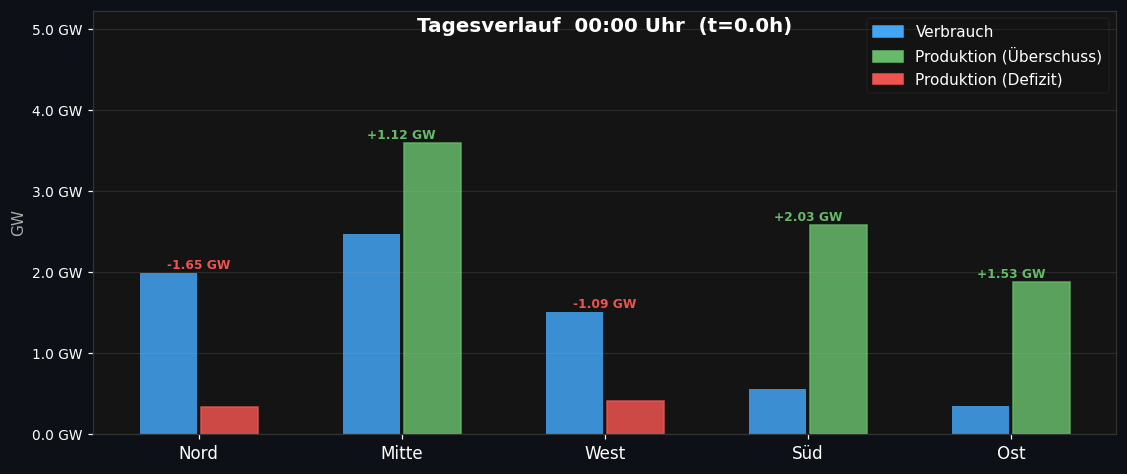

In [37]:
# ── Animation anzeigen ──────────────────────────────────────────────────
show_animation(gif_path, mode='gif', framerate=10)


**Animation.** Zeigt Produktions-Verbrauchs-Dynamik über 24h pro Zone als GIF. Blau = Verbrauch, Grün = Produktion bei Überschuss, Rot = Produktion bei Defizit. Bar-Höhe = GW-Wert; Annotation über dem Balken = Netto-Bilanz (Produktion − Verbrauch).

---
## 7. Saisonale Zonenimbalance: Wann und wo lohnen sich Batterien? <a id='saisonale-zonenimbalance-wann-und-wo-lohnen-sich-batterien_K_01'></a>

[↑ Inhaltsverzeichnis](#toc_K_01)

Die bisherige Zonenbilanzen-Analyse (Sektion 3) arbeitet mit **Jahresdurchschnittswerten**.  
In der Realität variiert die Imbalance stark saisonal:

- **Sommer:** Speicherseen voll (Schneeschmelze), Solar maximal → Süd/Ost exportieren maximal  
- **Winter:** Speicherseen leer, kein Solar → Süd/Ost reduzieren Export, Nord/West Defizit wächst  
- **Frühling:** Grösste Dynamik (Übergang)

Diese saisonale Variation hat direkte Konsequenzen für den **Battery Value Index (BVI)**:  
Eine Batterie, die im Jahresdurchschnitt in Zone X am wertvollsten ist,  
kann im Winter in Zone Y deutlich wertvoller sein.

**Datengrundlage:** `ch_spot_prices_clean.csv` (Preis-Saisonalität) + `zonenbilanzen.csv` (Zonenstruktur)  
+ saisonale Kapazitätsfaktoren aus der [BFE](../organisation/O_02_Glossar.ipynb#g-bfe) Elektrizitätsstatistik 2023.


### 7.1 Saisonale Kapazitätsfaktoren & Zonenimbalance

Kapazitätsfaktoren variieren saisonal: Solar im Winter nahe 0, Speicherwasser im Sommer maximal. Die saisonal korrigierten Zonenbilanzen zeigen, wann und wo Batterien den grössten Netzwert haben.

In [38]:
# ── 6.1 Saisonale Kapazitätsfaktoren & Zonenimbalance ─────────────────────────
# Kapazitätsfaktoren variieren saisonal (Quelle: BFE Elektrizitätsstatistik 2023)

CF_SEASONAL = {
    #           Winter  Frühling  Sommer  Herbst
    'Wasserkraft': [0.28,   0.42,    0.50,   0.32],  # Sommer: Schneeschmelze
    'Solar':       [0.05,   0.12,    0.19,   0.10],  # Sommer: max Einstrahlung
    'Kernkraft':   [0.82,   0.80,    0.75,   0.80],  # Sommer: Revision
    'Wind':        [0.28,   0.20,    0.16,   0.22],  # Winter: mehr Wind CH
    'Biomasse':    [0.60,   0.55,    0.50,   0.55],
    'Erdgas':      [0.45,   0.25,    0.15,   0.30],  # Winter: Spitzenlast
    'Abfall':      [0.65,   0.65,    0.65,   0.65],
    'Geothermie':  [0.80,   0.80,    0.80,   0.80],
    'Erdoel':      [0.20,   0.10,    0.05,   0.15],
    'Andere':      [0.40,   0.40,    0.40,   0.40],
}
SAISON_NAMES = ['Winter', 'Frühling', 'Sommer', 'Herbst']

# Mittlere Einspeisung pro Zone × Saison
df_zones_seasonal = []
for s_idx, saison in enumerate(SAISON_NAMES):
    for zone in ZONE_COLORS:
        # Installierte Kapazität pro ET in dieser Zone
        prod_mw = 0.0
        if 'ET_group' in gdf_plants.columns:
            for et, cf_list in CF_SEASONAL.items():
                cf = cf_list[s_idx]
                kw = gdf_plants[(gdf_plants['Zone']==zone) &
                                (gdf_plants['ET_group']==et)]['kw'].sum()
                prod_mw += kw / 1000 * cf
        else:
            prod_mw = float(df_zones[df_zones['Zone']==zone]['Produktion_MW'].iloc[0])

        # Verbrauch variiert saisonal (Winter +15%, Sommer -10%)
        base_verbrauch = float(df_zones[df_zones['Zone']==zone]['Verbrauch_MW'].iloc[0])
        verbrauch_factor = [1.15, 1.05, 0.90, 1.00][s_idx]
        verbrauch_mw = base_verbrauch * verbrauch_factor

        imbalance = prod_mw - verbrauch_mw
        df_zones_seasonal.append({
            'Zone': zone, 'Saison': saison, 's_idx': s_idx,
            'Produktion_MW': round(prod_mw, 1),
            'Verbrauch_MW': round(verbrauch_mw, 1),
            'Imbalance_MW': round(imbalance, 1),
        })

df_sz = pd.DataFrame(df_zones_seasonal)

print('Saisonale Zonenimbalance [MW] (+= Überschuss, -= Defizit):')
pivot = df_sz.pivot(index='Zone', columns='Saison', values='Imbalance_MW')[SAISON_NAMES]
print(pivot.to_string())
print()
print('Interpretation:')
for zone in ZONE_COLORS:
    row = pivot.loc[zone]
    min_s = row.idxmin(); max_s = row.idxmax()
    sign_change = (row < 0).any() and (row > 0).any()
    if sign_change:
        print(f'  {zone:6}: VORZEICHEN wechselt! {min_s}: {row[min_s]:+.0f} MW  '
              f'/ {max_s}: {row[max_s]:+.0f} MW  → kritische Zone')
    else:
        print(f'  {zone:6}: {min_s}: {row[min_s]:+.0f} MW  /  {max_s}: {row[max_s]:+.0f} MW')

# Speichern
_zbs_path = os.path.join(INTER_DIR, 'zonenbilanzen_saisonal.csv')
df_sz.to_csv(_zbs_path, index=False)
_kb = os.path.getsize(_zbs_path) / 1024
log_dataindex('zonenbilanzen_saisonal.csv',
              'K_01: Saisonale Zonenimbalance (Zone x Saison, saisonale CF)',
              _zbs_path, 'intermediate',
              rows=len(df_sz), size_kb=_kb,
              note='5 Zonen x 4 Saisons, Produktion/Verbrauch/Imbalance')
print(f'\nGespeichert: {_zbs_path}')



Saisonale Zonenimbalance [MW] (+= Überschuss, -= Defizit):
Saison       Winter     Frühling       Sommer       Herbst
Zone                                                      
Mitte    819.000000  1601.800049  2261.199951  1378.900024
Nord   -1866.300049 -1426.099976  -920.099976 -1433.699951
Ost     1160.500000  1963.800049  2467.699951  1442.699951
Süd     1519.599976  2638.699951  3353.199951  1922.300049
West   -1288.199951  -894.200012  -476.899994  -947.400024

Interpretation:
  Nord  : Winter: -1866 MW  /  Sommer: -920 MW
  Mitte : Winter: +819 MW  /  Sommer: +2261 MW
  West  : Winter: -1288 MW  /  Sommer: -477 MW
  Süd   : Winter: +1520 MW  /  Sommer: +3353 MW
  Ost   : Winter: +1160 MW  /  Sommer: +2468 MW
  dataindex: zonenbilanzen_saisonal.csv [active]

Gespeichert: ../data\intermediate\zonenbilanzen_saisonal.csv


---
### 7.2 Visualisierungen: Zone × Saison Heatmap + saisonaler BVI

Zwei Charts: (a) Imbalance-Heatmap Zone × Saison zeigt räumlich-zeitliche Muster;
(b) saisonaler [BVI](../organisation/O_02_Glossar.ipynb#g-bvi) identifiziert wo und wann Batterien den höchsten Wertbeitrag leisten.


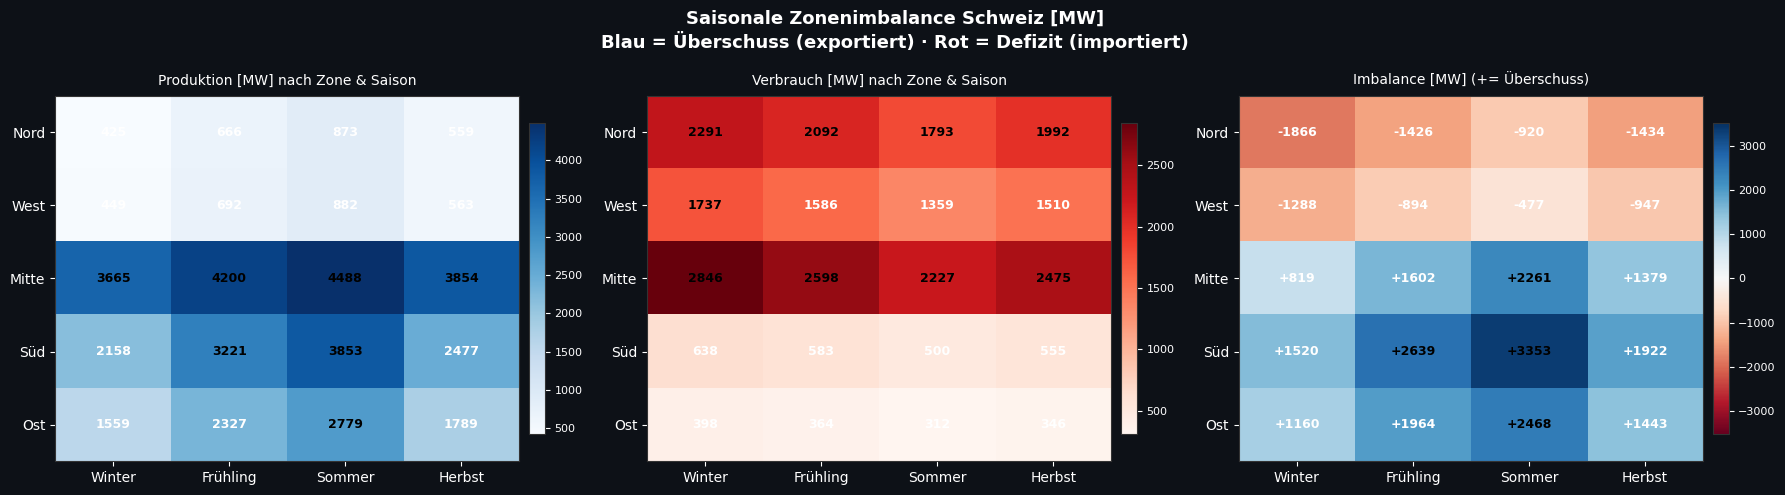

Chart 6a gespeichert: ../output\charts\realistisch\kuer_k01_zonenimbalance_saisonal.png


In [39]:
# ── 6.2a Heatmap: Imbalance Zone × Saison ─────────────────────────────────────
import matplotlib.colors as mcolors  # Re-Import mit lokalem Alias (Farbskalierung)
pivot_imb = df_sz.pivot(index='Zone', columns='Saison', values='Imbalance_MW')[SAISON_NAMES]
pivot_prod = df_sz.pivot(index='Zone', columns='Saison', values='Produktion_MW')[SAISON_NAMES]
pivot_verb = df_sz.pivot(index='Zone', columns='Saison', values='Verbrauch_MW')[SAISON_NAMES]

zones_ordered = ['Nord','West','Mitte','Süd','Ost']  # Nord/West oben (Defizit), Süd/Ost unten

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(BG_DARK)
for ax in axes:
    ax.set_facecolor(BG_DARK)
    ax.tick_params(colors='white')
fig.suptitle('Saisonale Zonenimbalance Schweiz [MW]\n'
             'Blau = Überschuss (exportiert) · Rot = Defizit (importiert)',
             color='white', fontsize=FS_TITEL, fontweight='bold')

for ax, (matrix_df, title, cmap) in zip(axes, [
    (pivot_prod.loc[zones_ordered],  'Produktion [MW] nach Zone & Saison',    'Blues'),
    (pivot_verb.loc[zones_ordered],  'Verbrauch [MW] nach Zone & Saison',     'Reds'),
    (pivot_imb.loc[zones_ordered],   'Imbalance [MW] (+= Überschuss)',         'RdBu'),
]):
    # Divergente Colormap für Imbalance, sequenziell für Prod/Verb
    if 'Imbalance' in title:
        vmax = abs(matrix_df.values).max() * 1.05
        norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
        im   = ax.imshow(matrix_df.values, cmap=cmap, norm=norm, aspect='auto')
    else:
        im = ax.imshow(matrix_df.values, cmap=cmap, aspect='auto')

    cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02, shrink=0.85)
    cbar.ax.tick_params(colors='white', labelsize=8)
    cbar.ax.yaxis.label.set_color('white')

    ax.set_xticks(range(4))
    ax.set_xticklabels(SAISON_NAMES, color='white', fontsize=FS_ACHSE)
    ax.set_yticks(range(len(zones_ordered)))
    ax.set_yticklabels(zones_ordered, color='white', fontsize=FS_ACHSE)
    ax.set_title(title, color='white', pad=8, fontsize=FS_ACHSE)

    # Werte annotieren
    for i in range(len(zones_ordered)):
        for j in range(4):
            val = matrix_df.values[i, j]
            col = 'white' if abs(val) < abs(matrix_df.values).max()*0.6 else 'black'
            ax.text(j, i, f'{val:+.0f}' if 'Imbalance' in title else f'{val:.0f}',
                    ha='center', va='center', color=col, fontsize=FS_TICK, fontweight='bold')

plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'kuer_k01_zonenimbalance_saisonal.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
plt.close()
print(f'Chart 6a gespeichert: {p}')

**Saisonaler [BVI](../organisation/O_02_Glossar.ipynb#g-bvi) (6.2b):** Heatmap Battery Value Index pro Zone × Saison —
zeigt wo im Winter vs. Sommer der grösste Mehrwert durch Batterieeinsatz entsteht.


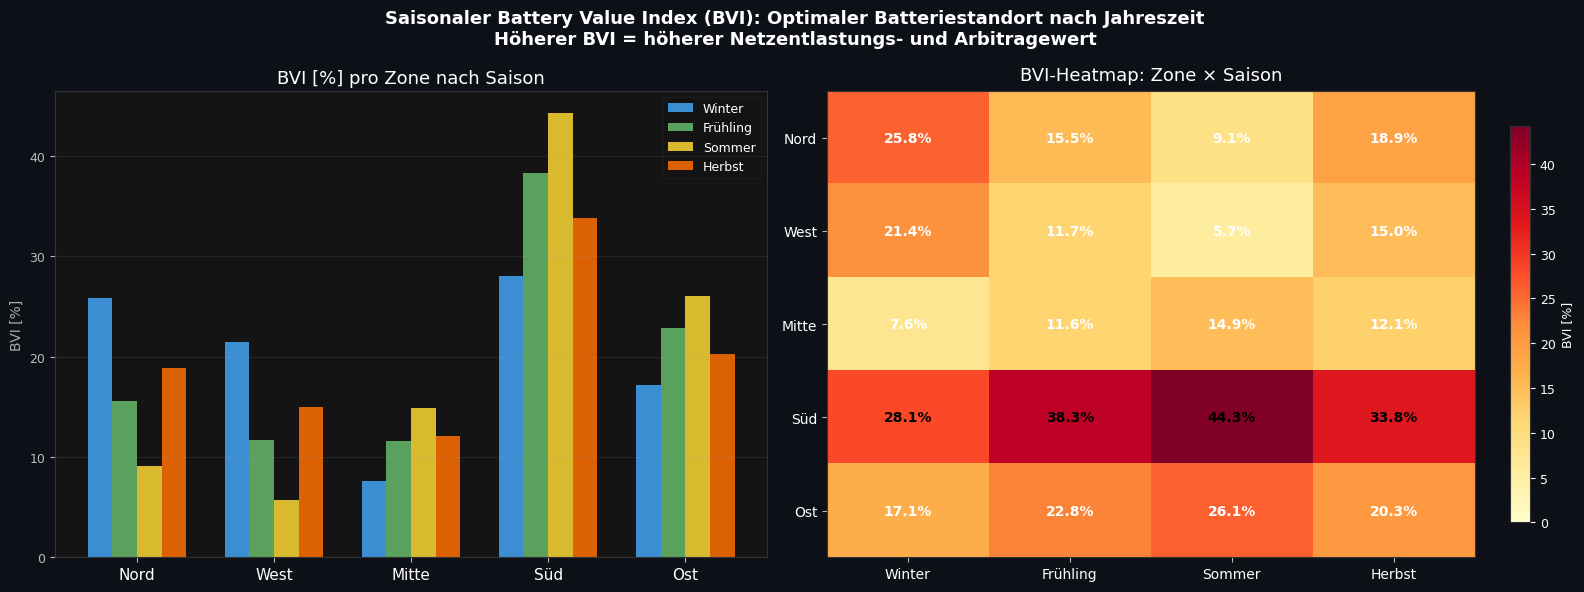

Chart 6b gespeichert: ../output\charts\realistisch\kuer_k01_bvi_saisonal.png

Wichtigste Erkenntnisse:
  Nord  : Bester BVI im Winter     (25.8%) | Schwächster: Sommer (9.1%)
  West  : Bester BVI im Winter     (21.4%) | Schwächster: Sommer (5.7%)
  Mitte : Bester BVI im Sommer     (14.9%) | Schwächster: Winter (7.6%)
  Süd   : Bester BVI im Sommer     (44.3%) | Schwächster: Winter (28.1%)
  Ost   : Bester BVI im Sommer     (26.1%) | Schwächster: Winter (17.1%)


In [40]:
# ── 6.2b Saisonaler BVI: Wann & wo sind Batterien am wertvollsten? ─────────────
# BVI saisonal: Imbalance × Engpassmultiplikator (wie in Sektion 3, aber pro Saison)

ENGPASS_MULT = {'Nord':1.5, 'Mitte':1.0, 'West':1.8, 'Süd':2.0, 'Ost':1.6}
SAISON_COLORS_MAP = {'Winter':C_PRIV,'Frühling':C_LOAD,'Sommer':C_SOLAR,'Herbst':C_GRENZWERT}

# BVI pro Zone × Saison berechnen
bvi_data = []
for saison in SAISON_NAMES:
    df_s = df_sz[df_sz['Saison']==saison].copy()
    df_s['BVI_raw'] = df_s['Imbalance_MW'].abs() * df_s['Zone'].map(ENGPASS_MULT)
    total = df_s['BVI_raw'].sum()
    df_s['BVI_pct'] = df_s['BVI_raw'] / total * 100 if total > 0 else 0
    bvi_data.append(df_s[['Zone','Saison','Imbalance_MW','BVI_pct']])

df_bvi_s = pd.concat(bvi_data, ignore_index=True)
pivot_bvi = df_bvi_s.pivot(index='Zone', columns='Saison', values='BVI_pct')[SAISON_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG_DARK)
for ax in axes:
    ax.set_facecolor(BG_PANEL)
    ax.tick_params(colors=C_TICK)
    for sp in ax.spines.values(): sp.set_edgecolor(C_SPINE)
fig.suptitle('Saisonaler Battery Value Index (BVI): Optimaler Batteriestandort nach Jahreszeit\n'
             'Höherer BVI = höherer Netzentlastungs- und Arbitragewert',
             color='white', fontsize=FS_TITEL, fontweight='bold')

# Panel 1: Gestapelter Balken Zone → Saison-BVI
ax = axes[0]
x = np.arange(len(zones_ordered))
w = 0.18
for j, saison in enumerate(SAISON_NAMES):
    vals = [pivot_bvi.loc[z, saison] if z in pivot_bvi.index else 0 for z in zones_ordered]
    ax.bar(x + (j-1.5)*w, vals, w, label=saison,
           color=SAISON_COLORS_MAP[saison], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(zones_ordered, color='white', fontsize=11)
ax.set_title('BVI [%] pro Zone nach Saison', color='white')
ax.set_ylabel('BVI [%]', color=C_ACHSE)
ax.legend(fontsize=FS_TICK, framealpha=ALPHA_LEGENDE, facecolor=C_LEGENDE_BG, labelcolor='white')
ax.grid(True, axis='y', alpha=ALPHA_FLAECHE)

# Panel 2: Heatmap BVI Zone × Saison
ax = axes[1]
bvi_matrix = np.array([[pivot_bvi.loc[z, s] if z in pivot_bvi.index else 0
                         for s in SAISON_NAMES] for z in zones_ordered])
im = ax.imshow(bvi_matrix, cmap='YlOrRd', aspect='auto',
               vmin=0, vmax=bvi_matrix.max())
cbar = plt.colorbar(im, ax=ax, fraction=0.04, shrink=0.85)
cbar.set_label('BVI [%]', color='white', fontsize=FS_TICK)
cbar.ax.tick_params(colors='white')
ax.set_xticks(range(4))
ax.set_xticklabels(SAISON_NAMES, color='white', fontsize=FS_ACHSE)
ax.set_yticks(range(len(zones_ordered)))
ax.set_yticklabels(zones_ordered, color='white', fontsize=FS_ACHSE)
ax.set_title('BVI-Heatmap: Zone × Saison', color='white', pad=8)
for i, zone in enumerate(zones_ordered):
    for j, saison in enumerate(SAISON_NAMES):
        val = bvi_matrix[i, j]
        col = 'black' if val > bvi_matrix.max()*0.6 else 'white'
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                color=col, fontsize=FS_ACHSE, fontweight='bold')

plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'kuer_k01_bvi_saisonal.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
plt.close()
print(f'Chart 6b gespeichert: {p}')

# Wichtigste Erkenntnisse ausgeben
print('\nWichtigste Erkenntnisse:')
for zone in zones_ordered:
    if zone in pivot_bvi.index:
        row = pivot_bvi.loc[zone]
        best_s  = row.idxmax()
        worst_s = row.idxmin()
        print(f'  {zone:6}: Bester BVI im {best_s:<10} ({row[best_s]:.1f}%) | '
              f'Schwächster: {worst_s} ({row[worst_s]:.1f}%)')


**Einzelplot** (BVI-Heatmap saisonal für Bericht):

In [41]:
# ── Saisonaler BVI: Einzelplot Heatmap ────────────────────────────────────────
if 'df_bvi_s' in dir() and not df_bvi_s.empty:
    pivot_bvi_s = df_bvi_s.pivot(index='Zone', columns='Saison', values='BVI_pct')
    pivot_bvi_s = pivot_bvi_s[SAISON_NAMES]
    zones_ord   = ['Nord','West','Mitte','Süd','Ost']

    fig_zs, ax_zs = plt.subplots(figsize=(10, 5))
    fig_zs.patch.set_facecolor(BG_DARK)
    ax_zs.set_facecolor(BG_DARK); ax_zs.tick_params(colors='white')

    bvi_mat = [[pivot_bvi_s.loc[z, s] if z in pivot_bvi_s.index else 0
                for s in SAISON_NAMES] for z in zones_ord]
    im_zs = ax_zs.imshow(bvi_mat, cmap='YlOrRd', aspect='auto',
                          vmin=0, vmax=max(max(r) for r in bvi_mat))
    cbar_zs = plt.colorbar(im_zs, ax=ax_zs, fraction=0.04, shrink=0.85)
    cbar_zs.set_label('BVI [%]', color='white', fontsize=FS_TICK)
    cbar_zs.ax.tick_params(colors='white')

    ax_zs.set_xticks(range(4)); ax_zs.set_xticklabels(SAISON_NAMES, color='white', fontsize=11)
    ax_zs.set_yticks(range(5)); ax_zs.set_yticklabels(zones_ord, color='white', fontsize=11)
    ax_zs.set_title('Saisonaler Battery Value Index: Optimaler Standort nach Jahreszeit',
                    color='white', fontsize=12, fontweight='bold', pad=10)

    for i, zone in enumerate(zones_ord):
        for j, saison in enumerate(SAISON_NAMES):
            val = bvi_mat[i][j]
            col = 'black' if val > max(max(r) for r in bvi_mat)*0.55 else 'white'
            ax_zs.text(j, i, f'{val:.1f}%', ha='center', va='center',
                       color=col, fontsize=11, fontweight='bold')

    plt.tight_layout()
    p = os.path.join(CHARTS_DIR, 'kuer_k01_bvi_heatmap.png')
    plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
    plt.close()
    print(f'  Einzelplot: kuer_k01_bvi_heatmap.png')
else:
    print('df_bvi_s nicht verfügbar – Sektion 6 zuerst ausführen.')


  Einzelplot: kuer_k01_bvi_heatmap.png


---
### 7.3 Erkenntnisse: Saisonale Muster

Die saisonale Analyse zeigt zwei wichtige Erkenntnisse, die den Jahresdurchschnitts-[BVI](../organisation/O_02_Glossar.ipynb#g-bvi) ergänzen:

**1. [Zonenimbalance](../organisation/O_02_Glossar.ipynb#g-zonenimbalance) ist stark saisonal📊:**
- **Süd/Ost im Sommer:** Massiver Überschuss durch Schneeschmelze + Speicherseen voll (Süd: +3353 MW, Ost: +2468 MW) → BVI hoch (Puffern lohnt)
- **Süd/Ost im Winter:** Speicher zunehmend genutzt, reduzierte Produktion → Überschuss **schrumpft auf ~45 %** (Süd: +1520 MW, Ost: +1160 MW), bleibt aber positiv
- **Nord/West ganzjährig Defizit, Winter deutlich stärker:** Nord Winter -1866 MW vs. Sommer -920 MW (Heizlast verdoppelt das Defizit); West Winter -1288 vs. Sommer -477 MW → BVI stabil hoch

**2. Arbitrage-Spread ist saisonal (→ NB04 Chart 5a):**
Tages-Spread-Spanne (Tageshoch − Tagestief, Saison-Mittel) — sortiert absteigend:
- **Frühling**: höchste Spanne (~84 EUR/MWh📊) — Duck-Curve-Effekt maximal (Solar bereits aktiv, Heizlast noch hoch)
- **Sommer**: ~75 EUR/MWh📊 trotz häufiger Solar-Negativpreise — Mittagstief vs. Abendspitze treiben die Spanne
- **Herbst**: ~70 EUR/MWh📊 — Übergangsphase, weder Solar-Maximum noch Heizlast-Maximum
- **Winter**: niedrigste Spanne (~49 EUR/MWh📊) — entgegen intuitiver Erwartung (Heizlast verstetigt das Profil, kein Solar-Mittagstief)

**Empfehlung für Investoren:**
Eine Batterie in **Nord/West** (Defizit-Zone) profitiert sowohl von ganzjährig hohem Arbitrage-Spread  
als auch von stabilen Import-Situationen — das ist die robusteste Strategie.  
Eine Batterie in **Süd/Ost** hingegen hat saisonale Peaks im Sommer, aber schwächere Winter.


---
## Fazit: Was die räumliche Analyse zeigt <a id='fazit-was-die-raeumliche-analyse-zeigt_K_01'></a>

[↑ Inhaltsverzeichnis](#toc_K_01)

### Haupterkenntnisse

| Erkenntnis | Detail |
|------------|--------|
| **Süd + Ost** sind Exportzonen | Wasserkraft-Überschuss → Strom muss Richtung Nord |
| **Nord (ZH-Raum)** ist Importzone | Höchste Verbrauchsdichte, wenig lokale Produktion |
| **Göschenen-Airolo** ist kritischster Engpass | Nord-Süd-Achse ist Nadelöhr |
| **Solar** verschärft Mittagsproblem | Tagsüber Überschuss → nachts Defizit |
| **BVI-Gewichtung bringt +68 % mehr Netzwert📊** | Skalenunabhängig — räumliche Verteilung schlägt Quantität |

### Empfehlung: Standort-basierte Förderung
```
Heute:  Alle Batterien gleich subventioniert → suboptimale Netzwirkung
Besser: Höhere Förderung für Engpasszonen (Süd, West, Nord)
        → gleiche Fördermittel, deutlich mehr Netzentlastung
```

### Einschränkungen
- Kein vollständiges Lastflussmodell (DC-OPF) — Zonenmodell vereinfacht
- Swissgrid publiziert keine Leitungskapazitätsdaten als Open Data
- Lastprofile modellbasiert, nicht aus Messdaten

### Weiterführende Quellen
- Swissgrid Strategisches Netz 2040: https://www.swissgrid.ch/de/home/projects/future-grid/grid-development.html
- Swissgrid Redispatch: https://www.swissgrid.ch/de/home/newsroom/blog/2025/wenn-das-stromnetz-unter-druck-geraet.html
- [ENTSO-E](../organisation/O_02_Glossar.ipynb#g-entsoe) Transparency: https://transparency.entsoe.eu


---
## Abschluss <a id='abschluss_K_01'></a>

[↑ Inhaltsverzeichnis](#toc_K_01)

Erzeugte Karten und Heatmaps auf Existenz prüfen; alle Charts werden von K_00
(Business Strategy) referenziert. Fehlende Charts: Notebook erneut ausführen.


**🔎 Quellcode der importierten lib-Funktion**

In [42]:
show_source(final_check)


<details>
<summary>🔎 Quellcode: <code>final_check</code> (aus <code>lib/io_ops.py</code>)</summary>

```python
def final_check(nb_label, files=None, *, weiter_msg=None, fehler_msg=None,
                extras=None, show_dataindex=False,
                dataindex_path='../sync/dataindex.csv', width=60):
    """Standardisierte End-of-Notebook-Kontrolle für Pflicht- und Kür-NBs.

    Prüft Existenz und Mindestgrösse der angegebenen Output-Dateien,
    gibt formatiertes Resultat aus und liefert ``all_ok`` als Bool zurück.

    Parameter
    ---------
    nb_label : str
        Label des Notebooks im Output-Header, z.B. ``"NB01"``, ``"K_03"``.
    files : list of tuple, optional
        Zu prüfende Dateien als ``(path, label, min_bytes)``-Tuples.

        * ``min_bytes = 0`` → nur Existenz prüfen, Grösse nicht ausgeben
          (z.B. für PNG-Charts).
        * ``min_bytes > 0`` → zusätzlich Grösse prüfen und in KB/MB ausgeben
          (z.B. für CSV-Dateien).

        Bei ``files=None`` oder ``files=[]`` wird kein Check ausgeführt;
        die Funktion dient dann als reiner Status-Print (für Report-NBs
        ohne eigene Outputs wie K_00).
    weiter_msg : str, optional
        Nachricht für den Erfolgsfall, z.B. ``"NB02 Daten Bereinigung"``.
        Default: ``"nächstes Notebook"``.
    fehler_msg : str, optional
        Nachricht für den Fehlerfall (Kurzform, ohne "Fehler beheben vor").
        Default: identisch mit ``weiter_msg``.
    extras : list of str, optional
        Zusätzliche Print-Zeilen zwischen Datei-Check und Weiter-/Fehler-Hinweis.
        Sinnvoll für Kür-Hinweise oder Kontext.
    show_dataindex : bool, default False
        Wenn True, wird der aktive Auszug aus ``../sync/dataindex.csv`` ausgegeben.
        Typisch für NB01.
    dataindex_path : str, default '../sync/dataindex.csv'
        Pfad zur dataindex.csv (für ``show_dataindex=True``).
    width : int, default 60
        Breite der Trennlinie aus ``=``-Zeichen.

    Return
    ------
    bool
        ``True`` wenn alle Files existieren und Mindestgrösse erfüllen,
        ``False`` sonst. Bei ``files=None``/leer immer ``True``.
    """
    print(f'{nb_label} – Abschlusskontrolle')
    print('=' * width)

    all_ok = True

    if files:
        for path, label, min_bytes in files:
            exists = os.path.exists(path)
            size = os.path.getsize(path) if exists else 0
            ok = exists and size >= min_bytes

            if min_bytes > 0:
                size_str = _format_size(size) if exists else '   FEHLT'
                print(f'  {"✅" if ok else "❌"}  {label:<45} {size_str}')
            else:
                print(f'  {"✅" if ok else "❌"}  {label}')

            if not ok:
                all_ok = False

    if extras:
        if files:
            print()
        for line in extras:
            print(line)

    if show_dataindex and os.path.exists(dataindex_path):
        import pandas as pd
        df_idx = pd.read_csv(dataindex_path)
        active = df_idx[df_idx['status'] == 'active']
        print(f'\ndataindex.csv: {len(df_idx)} Einträge total, {len(active)} active')
        print(active[['filename', 'data_type', 'rows', 'size_kb', 'timestamp']]
              .to_string(index=False))

    print()
    weiter = weiter_msg or 'nächstes Notebook'
    fehler = fehler_msg or weiter
    if all_ok:
        print(f'→ Weiter mit {weiter}.')
    else:
        print(f'→ Fehler beheben vor {fehler}.')

    return all_ok
```

</details>


In [43]:
# ── Abschlusskontrolle K_01 ─────────────────────────────────────────────────
final_check(
    'K_01',
    files=[
        # Intermediate CSV — Daten-Outputs
        (os.path.join(INTER_DIR, 'bfs_kantone.csv'),
         'bfs_kantone.csv (BFS STATPOP, 26 Kantone)',                  100),
        (os.path.join(INTER_DIR, 'zonenbilanzen.csv'),
         'zonenbilanzen.csv (5 Zonen, Imbalance + BVI)',               300),
        (os.path.join(INTER_DIR, 'rollout_spatial.csv'),
         'rollout_spatial.csv (4 Szenarien × 5 Zonen × 3 Segmente)',   500),
        (os.path.join(INTER_DIR, 'zonenbilanzen_saisonal.csv'),
         'zonenbilanzen_saisonal.csv (5 Zonen × 4 Saisons)',           200),
        # Schlüssel-Charts (PNG = nur Existenzcheck)
        (os.path.join(CHARTS_DIR, 'kuer_k01_karte_gegenueberstellung.png'),
         'kuer_k01_karte_gegenueberstellung.png (3-Panel)',              0),
        (os.path.join(CHARTS_DIR, 'kuer_k01_bvi_jahresdurchschnitt.png'),
         'kuer_k01_bvi_jahresdurchschnitt.png',                          0),
        (os.path.join(CHARTS_DIR, 'kuer_k01_bvi_saisonal.png'),
         'kuer_k01_bvi_saisonal.png',                                    0),
        # Animation (Tagesverlauf)
        (os.path.join(CHARTS_DIR, 'kuer_k01_anim_tagesverlauf.gif'),
         'kuer_k01_anim_tagesverlauf.gif (Tagesverlauf-Animation)',      0),
    ],
    weiter_msg='K_02 Cross-Border (bzw. K_03 Marktdynamik)',
    fehler_msg='K_02',
)


K_01 – Abschlusskontrolle
  ✅  bfs_kantone.csv (BFS STATPOP, 26 Kantone)         0.3 KB
  ✅  zonenbilanzen.csv (5 Zonen, Imbalance + BVI)      1.0 KB
  ✅  rollout_spatial.csv (4 Szenarien × 5 Zonen × 3 Segmente)     1.7 KB
  ✅  zonenbilanzen_saisonal.csv (5 Zonen × 4 Saisons)     0.8 KB
  ✅  kuer_k01_karte_gegenueberstellung.png (3-Panel)
  ✅  kuer_k01_bvi_jahresdurchschnitt.png
  ✅  kuer_k01_bvi_saisonal.png
  ✅  kuer_k01_anim_tagesverlauf.gif (Tagesverlauf-Animation)

→ Weiter mit K_02 Cross-Border (bzw. K_03 Marktdynamik).


True

**Ausgabe-Übersicht.** Abschlusskontrolle aller erzeugten Charts aus NB5.

| [← K_00 – Business Strategy](K_00_Business_Strategy.ipynb) | [↑ Übersicht](../organisation/O_01_Project_Overview.ipynb) | [K_02 – Cross-Border-Analyse →](K_02_Cross_Border.ipynb) |
|:---|:---:|---:|